# **Quantity, Exchange and Shift Through Time (QUEST)**
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/antoniovfonseca/summarize-change-components/blob/main/notebooks/v3/03_quest_pie.ipynb)

---

Author: Robert Gilmore Pontius Jr, Antonio Fonseca

Institution: Clark University

Email: antfonseca@clarku.edu

Version: 3.1.0

This notebook analyzes a time series of classified raster maps and summarizes how each class's size, location, and trajectory change over time. It follows the QUEST framework of Quantity, Exchange, and Shift components of change.

Fill in Section 2 with your data, then run the remaining cells in order. Each section below explains what it computes and how to read the results.

### What the notebook computes

**Class size over time** shows how many pixels of each class exist at every time point, and how that size changes from the first year to the last year.

**Number of changes** counts, pixel by pixel, how many times each location changed class across the whole time series. It is summarized per time interval, as an overall total, as a percentage of the study area, and as a map.

**Trajectories** classify every pixel into one of five patterns: stable, stable with alternation, direct extent change, extent change with alternation, or extent change with no direct transition. It is summarized per time interval, as an overall total, as a percentage of the study area, and as a map.

**Change components** decompose every transition into Quantity, Exchange, and Shift, following Pontius's framework. They are summarized as transition matrices, heatmaps, stacked charts per interval and overall, by class, and as extent, alternation exchange, and alternation shift maps.

### Generated Outputs

Results are written to the `OUTPUT_PATH` folder you set in Section 2.

| Folder | Contents | Produced in |
|---|---|---|
| `tables/` | CSV files with the numbers behind every chart: class sizes, number of changes summaries, trajectory summaries, and transition matrices | Section 4 |
| `charts/` | PNG stacked bar charts and heatmaps summarizing size, changes, trajectories, and change components | Section 5 |
| `rasters/` | GeoTIFF maps for trajectory, number of changes, extent, alternation exchange, and alternation shift, one value per pixel, for use in GIS software | Section 4 |
| `maps/` | PNG previews of the raster maps, ready to view or use in a report | Section 5 |

Need the raw numbers? Check `tables/`. Need figures for a report? Use `charts/` and `maps/`. Need to overlay results with other layers in QGIS or ArcGIS? Use the GeoTIFFs in `rasters/`.

### How this notebook is organized

1. **Environment Setup.** Install libraries, import modules, and mount Google Drive if you are using Colab.
2. **User Input.** The only section you normally need to edit: input and output paths, years, file naming, no data value, and class definitions.
3. **Shared Functions.** The processing engine, meaning the kernels, workers, and plot templates. Nothing runs here. It only defines the building blocks used below.
4. **Data Processing.** Runs the engine over your rasters and writes every CSV and GeoTIFF output.
5. **Plots and Maps.** Reads the outputs from Section 4 and renders every chart, heatmap, and map.

Sections 3 to 5 use default settings that work for most cases. Only change them if you intentionally want to customize a specific calculation, plot, or map.

Provide input raster maps in the format `{prefix}{year}{suffix}`, for example `PIE_C2_V11_1990.tif`, with one file per year. All files must share the same spatial grid: same width, height, CRS, extent, and resolution.


## **1. Environment Setup**

In [ ]:
# @title 1.1 Install the libraries
# @markdown Run this cell only if using Google Colab
%pip -q install \
    rasterio \
    seaborn \
    xlsxwriter \
    matplotlib-scalebar \
    matplotlib-map-utils

In [ ]:
# @title 1.2 Importing libraries
# Standard library
import glob
import os
import re
import pickle
import sys
import time
import math
from pathlib import Path
import threading
from contextlib import ExitStack
from concurrent.futures import ThreadPoolExecutor, as_completed

# Typing for annotations
from typing import Dict, List, Optional, Iterable, Tuple

# Third-party
import numba as nb
import numpy as np
import pandas as pd
import rasterio
import xlsxwriter
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker
from numba import prange
from pyproj import Transformer
from pyproj import CRS, Geod, Transformer
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# Rasterio submodules
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.enums import Resampling
from rasterio.transform import from_origin

# Matplotlib extensions
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow
from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    Normalize,
    LinearSegmentedColormap,
)
from matplotlib.patches import Patch, Rectangle, FancyArrowPatch

In [ ]:
# @title 1.3 Mounting Google Drive
# @markdown Run this cell only if using Google Colab
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## **2. User Input**

Fill in the cell below with your data. No programming knowledge is needed. Just replace the values between the quotes.

### What you need
1. **A folder of raster maps**, one single band GeoTIFF per time point.
2. **A consistent file name pattern:** `{PREFIX}{YEAR}{SUFFIX}`. For example, prefix `PIE_C2_V11_`, year `1990`, and suffix `.tif` produce `PIE_C2_V11_1990.tif`. You set the prefix, suffix, and list of years below. The notebook builds the expected file names from them and, when you run the cell, checks immediately that every file exists, listing anything missing before any processing starts.
3. **An output folder** where tables, charts, rasters, and maps will be written. It is created automatically if it does not exist.

### Requirements for the rasters themselves
- **Identical pixel grid across every file:** same width, height, CRS, extent, and resolution. If the grids do not line up pixel for pixel, the analysis will be wrong without any warning.
- **Single band.** Only band 1 of each file is read.
- **Integer class codes**, with one consistent no data value across every file marking invalid or masked pixels.

### Class definitions
The cell right after also defines `class_labels_dict`: the class IDs found in your rasters, their display names, and the colors used in charts and maps. This is a plain Python dictionary, so it needs to be edited with the same syntax already in the cell. Add, remove, or rename entries to match your own classification scheme.


In [ ]:
# @title 2.1 Configure Your App { display-mode: "form" }
# @markdown ### 📂 Path Settings
# @markdown Folder containing the input raster maps (one file per year):
INPUT_FOLDER_PATH = "/content/drive/MyDrive/Dataset/pie/reclassified" #@param {type:"string"}
# @markdown Output folder for tables, charts, rasters, and maps:
OUTPUT_PATH = "/content/drive/MyDrive/Assessments/quest/pie" #@param {type:"string"}

# @markdown ### 🗓️ Time Range
# @markdown Comma-separated years, or a Python range expression, in chronological order:
YEARS = range(1985, 2022) #@param {type:"string"}

# @markdown ### 🏷️ File Names
# @markdown Example: prefix "PIE_C2_V11_" + year 1990 + suffix ".tif" -> "PIE_C2_V11_1990.tif"
FILE_PREFIX = "PIE_C2_V11_" #@param {type:"string"}
FILE_SUFFIX = ".tif" #@param {type:"string"}

# @markdown ### 🧭 Raster Settings
# @markdown Pixel value marking invalid / masked data:
NO_DATA_VALUE = 255 #@param {type:"integer"}

# 1. Parse the years into a plain list, in chronological order.
# Handles three cases: a "range(a, b)" string (what Colab's string-typed
# form field produces when the box literally contains a range() call), a
# comma-separated string of years, and a real range or list object.
years_input = str(YEARS).strip()

if years_input.startswith("range(") and years_input.endswith(")"):
    range_args = [
        int(part.strip())
        for part in years_input[len("range("):-1].split(",")
    ]
    years = list(range(*range_args))
elif isinstance(YEARS, str):
    years = [
        int(year.strip())
        for year in YEARS.split(",")
        if year.strip()
    ]
else:
    years = [int(year) for year in YEARS]

if not years:
    raise ValueError("Please provide at least one year in YEARS.")
if years != sorted(set(years)):
    raise ValueError("YEARS must be unique and in chronological order.")

# 2. Build the paths consumed by every cell below.
image_paths = [
    os.path.join(INPUT_FOLDER_PATH, f"{FILE_PREFIX}{year}{FILE_SUFFIX}")
    for year in years
]
output_path = OUTPUT_PATH
noData_value = NO_DATA_VALUE

# 3. Validate the input folder and every expected file immediately.
if not os.path.exists(INPUT_FOLDER_PATH):
    raise FileNotFoundError(f"Input folder not found: {INPUT_FOLDER_PATH}")

missing_files = [path for path in image_paths if not os.path.exists(path)]

if missing_files:
    print("Missing raster maps:")
    for path in missing_files:
        print(f" - {path}")
else:
    print(f"All {len(image_paths)} raster maps found.")

# 4. Create the output folder if it does not exist yet.
if not os.path.exists(output_path):
    os.makedirs(output_path)
    print("Output folder created:", output_path)
else:
    print("Output folder already exists:", output_path)


All 37 raster maps found.
Output folder already exists: /content/drive/MyDrive/Assessments/quest/pie


In [ ]:
# @title 2.2 Class Definitions
# Class ID, names, and colors
class_labels_dict = {
    8: {"name": "Other",      "color": "#FEE726"},
    6: {"name": "Barren",     "color": "#E9C890"},
    2: {"name": "Shrubs",     "color": "#FC7143"},
    1: {"name": "Water",      "color": "#2F8AFA"},
    3: {"name": "Tidal flat", "color": "#D99D49"},
    4: {"name": "Low marsh",  "color": "#66FF32"},
    7: {"name": "Trees",      "color": "#236422"},
    5: {"name": "High marsh", "color": "#773498"},
}

# Sorted list of renamed class labels
class_labels = [class_labels_dict[key]["name"] for key in sorted(class_labels_dict.keys())]

## **3. Shared Functions**

This section only defines the functions used to process the rasters and draw every chart and map. Nothing runs here. Running these cells has no visible effect beyond making the functions available to Section 4 and Section 5.

Keep the default settings here unless you intentionally want to change how a calculation or a plot is built.

In [ ]:
# @title 3.1 Shared raster processing infrastructure
_thread_local_stack = threading.local()


def _get_thread_datasets(
    image_paths: Tuple[str, ...],
) -> Tuple[rasterio.io.DatasetReader, ...]:
    """
    Return open rasterio datasets for the given paths, cached per thread.

    Rasterio datasets are not safe to share across threads, so each
    worker thread keeps its own open handles and reuses them across
    every window/chunk, instead of opening and closing the file once
    per window.

    Parameters
    ----------
    image_paths : tuple of str
        Paths to the input rasters, in chronological order.

    Returns
    -------
    tuple of rasterio.io.DatasetReader
        One open dataset per input path, ordered as `image_paths`.
    """
    # 1. Check whether this thread already has the right datasets open
    cache = getattr(_thread_local_stack, "datasets", None)

    if cache is None or cache["key"] != image_paths:

        # 2. Close any datasets left over from a previous set of paths
        if cache is not None:
            for src in cache["srcs"]:
                src.close()

        # 3. Open every raster once and store it for reuse
        cache = {
            "key": image_paths,
            "srcs": tuple(
                rasterio.open(p) for p in image_paths
            ),
        }
        _thread_local_stack.datasets = cache

    return cache["srcs"]


def _resolve_windows(
    image_paths: List[str],
) -> List[rasterio.windows.Window]:
    """
    Resolve the spatial chunks used to process the raster time series.

    Uses the native block layout of the first raster when available,
    falling back to fixed-size row chunks otherwise. Computed once and
    shared by every function that processes the same time series.

    Parameters
    ----------
    image_paths : list of str
        Paths to the input rasters, in chronological order.

    Returns
    -------
    list of rasterio.windows.Window
        Windows covering the full raster extent.
    """
    # 1. Read the first raster to determine block layout
    with rasterio.open(image_paths[0]) as src:
        windows = [window for ij, window in src.block_windows()]

        # 2. Fall back to row-based chunks if no native tiling exists
        if not windows:
            windows = []
            for idx in range(0, src.height, 256):
                height = min(256, src.height - idx)
                windows.append(
                    rasterio.windows.Window(0, idx, src.width, height)
                )

    return windows

### 3.2 Numba kernels

In [ ]:
# @title 3.2.1 Trajectory classification kernels
@nb.njit(
    nogil=True,
)
def classify_pixel(
    pixel_series: np.ndarray,
    nodata_val: int,
) -> np.uint8:
    """
    Classify a single pixel trajectory into five categories based on MatricesMain11 logic.

    Parameters
    ----------
    pixel_series : np.ndarray
        A 1D numpy array representing the land cover class values
        of a single pixel over time.
    nodata_val : int
        The integer value representing no data.

    Returns
    -------
    np.uint8
        An integer representing the trajectory class:
        1: All stable (Gray)
        2: Extent stable with alternation (Red)
        3: Extent change without alternation (Yellow)
        4: Extent change with alternation - Direct transition exists (Orange)
        5: Extent change - Unaccounted/No direct transition (Dark Blue)
        0: NoData
    """
    # 1. Get the length of the time series
    length = len(
        pixel_series,
    )

    # 2. Check for empty or NoData series
    if length == 0:
        return np.uint8(
            nodata_val,
        )

    for i in range(
        length,
    ):
        if pixel_series[i] == nodata_val:
            return np.uint8(
                nodata_val,
            )

    # 3. Identify Start and End classes
    start = pixel_series[
        0
    ]
    end = pixel_series[
        length - 1
    ]

    # 4. Logic for Stable Extent (Start == End)
    if start == end:
        is_completely_stable = True

        # Check if any intermediate value differs from start
        for i in range(
            1,
            length,
        ):
            if pixel_series[i] != start:
                is_completely_stable = False
                break

        if is_completely_stable:
            # Trajectory 1: All stable
            return np.uint8(
                1,
            )
        else:
            # Trajectory 2: Extent stable with alternation
            return np.uint8(
                2,
            )

    # 5. Logic for Extent Change (Start != End)
    else:
        # Check if the direct transition (Start -> End) exists at any step
        has_direct_transition = False

        for i in range(
            length - 1,
        ):
            if pixel_series[i] == start and pixel_series[i + 1] == end:
                has_direct_transition = True
                break

        if not has_direct_transition:
            # Trajectory 5: Extent change with alternation shift (Unaccounted)
            # The transition Start->End never happens directly.
            return np.uint8(
                5,
            )

        else:
            # Direct transition exists. Now distinguish T3 vs T4.
            # We calculate the "path length" (ignoring consecutive duplicates)

            path_changes = 0
            last_val = start

            for i in range(
                1,
                length,
            ):
                current_val = pixel_series[
                    i
                ]
                if current_val != last_val:
                    path_changes += 1
                    last_val = current_val

            # If there is exactly 1 change (Start -> ... -> End), it is T3.
            if path_changes == 1:
                # Trajectory 3: Extent change without alternation
                return np.uint8(
                    3,
                )
            else:
                # Trajectory 4: Extent change with alternation (Direct exists)
                return np.uint8(
                    4,
                )


@nb.njit(
    nogil=True,
    parallel=True,
)
def compute_trajectory_chunk_parallel(
    stack: np.ndarray,
    nodata_val: int,
) -> np.ndarray:
    """
    Apply pixel classification to a 3D raster stack using parallel processing.

    Parameters
    ----------
    stack : np.ndarray
        A 3D numpy array of shape (time, height, width) containing
        the stacked raster data.
    nodata_val : int
        The integer value representing no data.

    Returns
    -------
    np.ndarray
        A 2D numpy array of shape (height, width) containing the
        classified trajectory codes (uint8).
    """
    height = stack.shape[
        1
    ]
    width = stack.shape[
        2
    ]

    # 1. Initialize result array with zeros
    result = np.zeros(
        (
            height,
            width,
        ),
        dtype=np.uint8,
    )

    # 2. Iterate over rows in parallel
    for y in prange(
        height,
    ):
        for x in range(
            width,
        ):
            # 3. Extract time series for pixel (y, x)
            pixel_series = stack[
                :,
                y,
                x,
            ]

            # 4. Classify the pixel
            result[
                y,
                x,
            ] = classify_pixel(
                pixel_series,
                nodata_val,
            )

    return result

In [ ]:
# @title 3.2.2 Number of changes kernel
@nb.njit(
    nogil=True,
)
def compute_number_of_changes_chunk(
    stack: np.ndarray,
    nodata: int,
) -> np.ndarray:
    """
    Numba-optimized function to calculate the total number of changes per pixel.

    Parameters
    ----------
    stack : np.ndarray
        3D numpy array (time, height, width) for a specific spatial chunk.
    nodata : int
        Value representing NoData pixels.

    Returns
    -------
    np.ndarray
        2D numpy array (height, width) with the total number of changes.
    """
    time_steps = stack.shape[
        0
    ]
    h = stack.shape[
        1
    ]
    w = stack.shape[
        2
    ]

    out_changes = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )

    for y in range(
        h,
    ):
        for x in range(
            w,
        ):
            traj = stack[
                :,
                y,
                x,
            ]

            # Check for NoData in any time step
            has_nodata = False
            for t in range(
                time_steps,
            ):
                if traj[
                    t
                ] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            # Calculate total changes
            changes = 0
            for t in range(
                time_steps - 1,
            ):
                if traj[
                    t
                ] != traj[
                    t + 1
                ]:
                    changes += 1

            out_changes[
                y,
                x,
            ] = changes

    return out_changes

In [ ]:
# @title 3.2.3 Change counts matrix kernel
@nb.njit(
    nogil=True,
)
def compute_change_counts_matrix(
    stack: np.ndarray,
    nodata: int,
) -> np.ndarray:
    """
    Counts pixels changing in each interval, categorized by their total
    number of changes across the entire time series.

    Parameters
    ----------
    stack : np.ndarray
        3D array (time, height, width) with pixel values.
    nodata : int
        Value to ignore.

    Returns
    -------
    np.ndarray
        2D array of shape (n_intervals, n_intervals).
        Rows represent time intervals, columns represent the total changes.
    """
    n_times = stack.shape[0]
    height = stack.shape[1]
    width = stack.shape[2]
    n_intervals = n_times - 1

    # 1. Initialize the counts array
    # Rows: Time Intervals (0 to T-1)
    # Cols: Total life changes (0 = 1 total change, 1 = 2 total changes, etc.)
    counts = np.zeros(
        (
            n_intervals,
            n_intervals,
        ),
        dtype=np.int64,
    )

    # 2. Iterate over every pixel in the raster
    for y in range(
        height,
    ):
        for x in range(
            width,
        ):

            # 3. Discover the total number of changes in the pixel's lifetime
            total_changes_for_pixel = 0

            for t in range(
                n_intervals,
            ):
                v_curr = stack[
                    t, y, x,
                ]
                v_next = stack[
                    t + 1, y, x,
                ]

                if v_curr != nodata and v_next != nodata:
                    if v_curr != v_next:
                        total_changes_for_pixel += 1

            # 4. Register the pixel in the intervals where it changed
            # Only proceed if the pixel had at least 1 change in total
            if total_changes_for_pixel > 0:
                for t in range(
                    n_intervals,
                ):
                    v_curr = stack[
                        t, y, x,
                    ]
                    v_next = stack[
                        t + 1, y, x,
                    ]

                    if v_curr != nodata and v_next != nodata:
                        # 5. Check if the pixel changed in THIS specific interval
                        if v_curr != v_next:
                            # Add 1 to the count of this interval
                            # Column index is total changes (-1 to match index 0)
                            counts[
                                t,
                                total_changes_for_pixel - 1,
                            ] += 1

    return counts

In [ ]:
# @title 3.2.4 Interval transition matrices kernel
@nb.njit(nogil=True)
def compute_interval_matrices_chunk(
    stack: np.ndarray,
    nodata: int,
    class_to_idx: np.ndarray,
    num_classes: int,
) -> np.ndarray:
    """
    Calculate interval transition matrices for a chunk of raster data.

    Parameters
    ----------
    stack : np.ndarray
        3D array of shape (time, height, width) with pixel values.
    nodata : int
        Value representing NoData.
    class_to_idx : np.ndarray
        1D array mapping class values to matrix indices.
    num_classes : int
        Total number of valid classes.

    Returns
    -------
    np.ndarray
        3D array of shape (n_intervals, num_classes, num_classes)
        containing the accumulated transition counts.
    """
    # 1. Extract dimensions
    n_times = stack.shape[0]
    h = stack.shape[1]
    w = stack.shape[2]
    n_intervals = n_times - 1

    # 2. Initialize output matrices
    out_matrices = np.zeros(
        (
            n_intervals,
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )

    # 3. Iterate over spatial dimensions
    for y in range(h):
        for x in range(w):
            # 4. Check for NoData across the pixel's trajectory
            has_nodata = False
            for t in range(n_times):
                if stack[t, y, x] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            # 5. Accumulate transitions for valid pixels
            for t in range(n_intervals):
                val_s = stack[t, y, x]
                val_e = stack[t + 1, y, x]

                idx_s = class_to_idx[val_s]
                idx_e = class_to_idx[val_e]

                if idx_s >= 0 and idx_e >= 0:
                    out_matrices[
                        t,
                        idx_s,
                        idx_e,
                    ] += 1

    return out_matrices

In [ ]:
# @title 3.2.5 Change component matrices kernel
@nb.njit(nogil=True)
def compute_component_matrices_chunk(
    stack: np.ndarray,
    nodata: int,
    class_to_idx: np.ndarray,
    num_classes: int,
) -> tuple:
    """
    Calculate change component matrices for a chunk of raster data.

    Parameters
    ----------
    stack : np.ndarray
        3D array of shape (time, height, width) with pixel values.
    nodata : int
        Value representing NoData.
    class_to_idx : np.ndarray
        1D array mapping class values to matrix indices.
    num_classes : int
        Total number of valid classes.

    Returns
    -------
    tuple
        A tuple containing 5 np.ndarray matrices:
        - Sum of all transitions
        - Extent matrix
        - Alternation exchange matrix
        - Alternation shift matrix
        - Unaccounted extent matrix
    """
    # 1. Extract dimensions
    n_times = stack.shape[0]
    h = stack.shape[1]
    w = stack.shape[2]

    # 2. Initialize local accumulation matrices
    m_sum = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_ext = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_x = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_s = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )
    m_u = np.zeros(
        (
            num_classes,
            num_classes,
        ),
        dtype=np.int64,
    )

    # 3. Iterate over spatial dimensions
    for y in range(h):
        for x in range(w):
            # 4. Check for NoData across the pixel's trajectory
            has_nodata = False
            for t in range(n_times):
                if stack[t, y, x] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            start_val = stack[0, y, x]
            end_val = stack[-1, y, x]

            start_idx = class_to_idx[start_val]
            end_idx = class_to_idx[end_val]

            if start_idx < 0 or end_idx < 0:
                continue

            # 5. Compute transition matrix for pixel r
            m_r = np.zeros(
                (
                    num_classes,
                    num_classes,
                ),
                dtype=np.int64,
            )
            for t in range(n_times - 1):
                s_t = class_to_idx[
                    stack[t, y, x]
                ]
                e_t = class_to_idx[
                    stack[t + 1, y, x]
                ]
                if s_t >= 0 and e_t >= 0:
                    m_r[
                        s_t,
                        e_t,
                    ] += 1

            # 6. Compute extent matrix for pixel r
            e_r = np.zeros(
                (
                    num_classes,
                    num_classes,
                ),
                dtype=np.int64,
            )
            e_r[
                start_idx,
                end_idx,
            ] = 1

            # 7. Compute alternation exchange matrix
            diff_m_e = m_r - e_r
            x_r = np.maximum(
                0,
                np.minimum(
                    diff_m_e,
                    diff_m_e.T,
                ),
            )

            # 8. Compute alternation shift matrix
            s_r = np.maximum(
                0,
                m_r - x_r - e_r,
            )

            # 9. Compute unaccounted extent matrix
            u_r = e_r + x_r + s_r - m_r

            # 10. Accumulate into global chunk matrices
            m_sum += m_r
            m_ext += e_r
            m_x += x_r
            m_s += s_r
            m_u += u_r

    return m_sum, m_ext, m_x, m_s, m_u

In [ ]:
# @title 3.2.6 Extent, exchange and shift components kernel
@nb.njit(
    nogil=True,
)
def compute_components_chunk(
    stack: np.ndarray,
    nodata: int,
) -> tuple:
    """
    Numba-optimized function to calculate Extent, Exchange, and Shift components.

    Parameters
    ----------
    stack : np.ndarray
        3D numpy array (time, height, width) for a specific spatial chunk.
    nodata : int
        Value representing NoData pixels.

    Returns
    -------
    tuple
        Three 2D numpy arrays (Extent, Exchange, Shift).
    """
    time_steps = stack.shape[0]
    h = stack.shape[1]
    w = stack.shape[2]

    out_extent = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )
    out_alt_exc = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )
    out_alt_shift = np.full(
        (
            h,
            w,
        ),
        nodata,
        dtype=np.uint8,
    )

    for y in range(
        h,
    ):
        for x in range(
            w,
        ):
            traj = stack[
                :,
                y,
                x,
            ]

            # 1. Check for NoData
            has_nodata = False
            for t in range(
                time_steps,
            ):
                if traj[t] == nodata:
                    has_nodata = True
                    break

            if has_nodata:
                continue

            # 2. Extent Component
            start_val = traj[0]
            end_val = traj[-1]
            extent_val = 1 if start_val != end_val else 0

            out_extent[
                y,
                x,
            ] = extent_val

            # 3. Find unique classes to build local transition matrix
            local_max = 0
            for t in range(
                time_steps,
            ):
                if traj[t] > local_max:
                    local_max = traj[t]

            m_r = np.zeros(
                (
                    local_max + 1,
                    local_max + 1,
                ),
                dtype=np.int32,
            )

            for t in range(
                time_steps - 1,
            ):
                s = traj[
                    t
                ]
                e = traj[
                    t + 1
                ]
                if s != e:
                    m_r[
                        s,
                        e,
                    ] += 1

            total_changes = np.sum(
                m_r,
            )

            # 4. Alternation Exchange Component
            total_exchange = 0
            for i in range(
                local_max + 1,
            ):
                for j in range(
                    local_max + 1,
                ):
                    if i != j:
                        val1 = m_r[
                            i,
                            j,
                        ]
                        val2 = m_r[
                            j,
                            i,
                        ]
                        total_exchange += val1 if val1 < val2 else val2

            out_alt_exc[
                y,
                x,
            ] = total_exchange

            # 5. Alternation Shift Component
            total_shift = total_changes - extent_val - total_exchange

            out_alt_shift[
                y,
                x,
            ] = total_shift if total_shift > 0 else 0

    return out_extent, out_alt_exc, out_alt_shift

In [ ]:
# @title 3.2.7 Trajectory interval change counts kernel
@nb.njit(
    nogil=True,
    fastmath=True,
)
def compute_trajectory_changes(
    trajectory_map: np.ndarray,
    stack: np.ndarray,
    nodata: int,
) -> np.ndarray:
    """
    Count pixels per trajectory type changing in each time interval using Numba.

    Parameters
    ----------
    trajectory_map : np.ndarray
        2D array (height, width) with trajectory IDs (2, 3, 4, 5).
    stack : np.ndarray
        3D array (time, height, width) with pixel values.
    nodata : int
        Value to ignore.

    Returns
    -------
    np.ndarray
        2D array of shape (n_intervals, 6) containing change counts.
        Rows correspond to time intervals.
        Columns correspond to trajectory IDs (0 to 5).
    """
    n_times = stack.shape[0]
    height = stack.shape[1]
    width = stack.shape[2]
    n_intervals = n_times - 1

    # Array to store counts: rows=intervals, cols=trajectory_ids(0-5)
    # We use 6 columns to map the trajectory ID directly as an index
    counts = np.zeros(
        (
            n_intervals,
            6,
        ),
        dtype=np.int64,
    )

    # Iterate over every pixel
    for y in range(
        height,
    ):
        for x in range(
            width,
        ):
            traj_id = trajectory_map[
                y,
                x,
            ]

            # We only care about Alternation(2), Step(3), Complex(4), Unaccounted(5)
            if traj_id < 2 or traj_id > 5:
                continue

            # Check changes across all time intervals
            for t in range(
                n_intervals,
            ):
                val_from = stack[
                    t,
                    y,
                    x,
                ]
                val_to = stack[
                    t + 1,
                    y,
                    x,
                ]

                # Check validity
                if (
                    val_from != nodata
                    and val_to != nodata
                    and val_from != val_to
                ):
                    counts[
                        t,
                        traj_id,
                    ] += 1

    return counts

### 3.3 Single-pass worker and orchestrator

In [ ]:
# @title 3.3.1 Worker: read block once, compute all quest outputs
def _read_and_compute_quest_block(
    image_paths: Tuple[str, ...],
    window: rasterio.windows.Window,
    nodata_val: int,
    class_to_idx: np.ndarray,
    num_classes: int,
) -> Dict[str, np.ndarray]:
    """
    Read one spatial block from every input raster ONCE and compute
    every quest output that depends on it.

    Reused downstream for: number-of-changes analysis, trajectory
    analysis, interval transition matrices, component matrices, and
    the extent / alternation raster maps — instead of re-reading the
    same block once per output.

    Parameters
    ----------
    image_paths : tuple of str
        Paths to the input rasters, in chronological order.
    window : rasterio.windows.Window
        Spatial block to read from every raster.
    nodata_val : int
        Pixel value representing NoData.
    class_to_idx : np.ndarray
        1D array mapping class values to transition-matrix indices.
    num_classes : int
        Total number of valid classes.

    Returns
    -------
    dict of str to np.ndarray
        Keys: "window", "trajectory_chunk", "changes_chunk",
        "change_counts_matrix", "interval_matrices",
        "extent_chunk", "alt_exchange_chunk", "alt_shift_chunk",
        "component_matrices" (tuple of 5 matrices).
    """
    # 1. Read the block from every raster, using the cached datasets
    srcs = _get_thread_datasets(image_paths)
    stack = np.array(
        [src.read(1, window=window) for src in srcs],
        dtype=np.uint8,
    )

    # 2. Classify pixel trajectories (Numba kernel from Section 6.1)
    trajectory_chunk = compute_trajectory_chunk_parallel(
        stack,
        int(nodata_val),
    )

    # 3. Compute total number of changes per pixel (Numba kernel from
    #    Section 5.6.1)
    changes_chunk = compute_number_of_changes_chunk(
        stack,
        nodata_val,
    )

    # 4. Compute the interval x total-changes count matrix (Numba
    #    kernel from Section 5.1)
    change_counts_matrix = compute_change_counts_matrix(
        stack=stack,
        nodata=int(nodata_val),
    )

    # 5. Compute interval transition matrices (Numba kernel from
    #    Section 7.1)
    interval_matrices = compute_interval_matrices_chunk(
        stack=stack,
        nodata=nodata_val,
        class_to_idx=class_to_idx,
        num_classes=num_classes,
    )

    # 6. Compute overall change component matrices (Numba kernel from
    #    Section 7.2)
    component_matrices = compute_component_matrices_chunk(
        stack=stack,
        nodata=nodata_val,
        class_to_idx=class_to_idx,
        num_classes=num_classes,
    )

    # 7. Compute extent / alternation exchange / alternation shift
    #    raster components (Numba kernel from Section 7.6.0)
    extent_chunk, alt_exchange_chunk, alt_shift_chunk = compute_components_chunk(
        stack,
        nodata_val,
    )

    # 8. Compute per-interval change counts by trajectory type (Numba
    #    kernel from Section 6.2), reusing the trajectory classification
    #    and the stack already in memory
    trajectory_interval_counts = compute_trajectory_changes(
        trajectory_map=trajectory_chunk,
        stack=stack,
        nodata=nodata_val,
    )

    return {
        "window": window,
        "trajectory_chunk": trajectory_chunk,
        "changes_chunk": changes_chunk,
        "change_counts_matrix": change_counts_matrix,
        "interval_matrices": interval_matrices,
        "component_matrices": component_matrices,
        "extent_chunk": extent_chunk,
        "alt_exchange_chunk": alt_exchange_chunk,
        "alt_shift_chunk": alt_shift_chunk,
        "trajectory_interval_counts": trajectory_interval_counts,
    }

In [ ]:
# @title 3.3.2 Orchestrator: single-pass computation of all quest outputs
def compute_all_quest_outputs(
    image_paths: List[str],
    output_dir: str,
    years: List[int],
    class_dict: Dict[int, Dict[str, str]],
    nodata_val: int,
    max_workers: int = 8,
    compress: str = "deflate",
) -> Dict[str, object]:
    """
    Compute every quest output in a single pass over the raster blocks.

    Reads each spatial block from the input time series exactly once
    and derives from it: number-of-changes analysis, trajectory
    classification, interval transition matrices, overall component
    matrices, and the extent / alternation raster maps. Replaces seven
    separate full read-throughs of the same input rasters.

    Parameters
    ----------
    image_paths : list of str
        Paths to the input rasters, in chronological order.
    output_dir : str
        Directory where rasters and tables subfolders are created.
    years : list of int
        Years corresponding to each input raster.
    class_dict : dict
        Mapping from class ID to metadata with "name" and "color".
    nodata_val : int
        Pixel value representing NoData.
    max_workers : int, optional
        Number of threads used to read/process blocks in parallel.
    compress : str, optional
        Compression algorithm used for the output rasters.

    Returns
    -------
    dict of str to object
        Every downstream artifact: dataframes, matrices, and output
        raster paths, keyed by name.
    """
    # 1. Prepare class index mapping shared by the transition matrices
    class_ids = sorted(class_dict.keys())
    num_classes = len(class_ids)
    max_id = max(class_ids) if class_ids else 255

    class_to_idx_arr = np.full(
        max_id + 1,
        -1,
        dtype=np.int64,
    )
    for idx, cid in enumerate(class_ids):
        class_to_idx_arr[cid] = idx

    # 2. Resolve output directories
    rasters_dir = os.path.join(output_dir, "rasters")
    tables_dir = os.path.join(output_dir, "tables")
    os.makedirs(rasters_dir, exist_ok=True)
    os.makedirs(tables_dir, exist_ok=True)

    out_raster_paths = {
        "trajectory": os.path.join(rasters_dir, "trajectory.tif"),
        "number_of_changes": os.path.join(rasters_dir, "number_of_changes.tif"),
        "extent": os.path.join(rasters_dir, "map_extent.tif"),
        "exchange": os.path.join(rasters_dir, "map_alternation_exchange.tif"),
        "shift": os.path.join(rasters_dir, "map_alternation_shift.tif"),
    }

    # 3. Read the output raster profile and resolve processing windows
    image_paths_t = tuple(sorted(image_paths))

    with rasterio.open(image_paths_t[0]) as src:
        profile = src.profile.copy()
        profile.update(
            dtype=rasterio.uint8,
            count=1,
            nodata=nodata_val,
            compress=compress,
        )
        if compress == "deflate":
            profile.update(zlevel=9)
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)
        profile.pop("tiled", None)

    windows = _resolve_windows(list(image_paths_t))

    # 4. Initialize accumulators for every CSV-based output
    n_intervals = len(years) - 1

    raw_change_counts = np.zeros((n_intervals, n_intervals), dtype=np.int64)
    raw_trajectory_intervals = np.zeros((n_intervals, 6), dtype=np.int64)
    global_interval_matrices = np.zeros(
        (n_intervals, num_classes, num_classes),
        dtype=np.int64,
    )
    mat_sum = np.zeros((num_classes, num_classes), dtype=np.int64)
    mat_ext = np.zeros((num_classes, num_classes), dtype=np.int64)
    mat_x = np.zeros((num_classes, num_classes), dtype=np.int64)
    mat_s = np.zeros((num_classes, num_classes), dtype=np.int64)
    mat_u = np.zeros((num_classes, num_classes), dtype=np.int64)

    print(
        f"Computing all quest outputs across {len(windows)} chunks, "
        f"reading each block once...",
    )

    # 5. Open every output raster writer and process all blocks
    with ExitStack() as stack_ctx:
        dst_trajectory = stack_ctx.enter_context(
            rasterio.open(out_raster_paths["trajectory"], "w", **profile)
        )
        dst_changes = stack_ctx.enter_context(
            rasterio.open(out_raster_paths["number_of_changes"], "w", **profile)
        )
        dst_extent = stack_ctx.enter_context(
            rasterio.open(out_raster_paths["extent"], "w", **profile)
        )
        dst_exchange = stack_ctx.enter_context(
            rasterio.open(out_raster_paths["exchange"], "w", **profile)
        )
        dst_shift = stack_ctx.enter_context(
            rasterio.open(out_raster_paths["shift"], "w", **profile)
        )

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [
                executor.submit(
                    _read_and_compute_quest_block,
                    image_paths_t,
                    window,
                    nodata_val,
                    class_to_idx_arr,
                    num_classes,
                )
                for window in windows
            ]

            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc="Processing chunks",
            ):
                result = future.result()
                window = result["window"]

                # 6. Write every raster output for this block
                dst_trajectory.write(result["trajectory_chunk"], 1, window=window)
                dst_changes.write(result["changes_chunk"], 1, window=window)
                dst_extent.write(result["extent_chunk"], 1, window=window)
                dst_exchange.write(result["alt_exchange_chunk"], 1, window=window)
                dst_shift.write(result["alt_shift_chunk"], 1, window=window)

                # 7. Accumulate every table-based output
                raw_change_counts += result["change_counts_matrix"]
                raw_trajectory_intervals += result["trajectory_interval_counts"]
                global_interval_matrices += result["interval_matrices"]

                chunk_sum, chunk_ext, chunk_x, chunk_s, chunk_u = result[
                    "component_matrices"
                ]
                mat_sum += chunk_sum
                mat_ext += chunk_ext
                mat_x += chunk_x
                mat_s += chunk_s
                mat_u += chunk_u

        # 8. Build overviews for every output raster, so downstream
        #    plotting functions can request a decimated read without
        #    GDAL needing to decode the full-resolution file. Without
        #    this, a display-sized read on a large uncompressed raster
        #    can still force a full decode internally and exhaust
        #    available memory.
        overview_factors = [2, 4, 8, 16, 32]
        for dst in (
            dst_trajectory,
            dst_changes,
            dst_extent,
            dst_exchange,
            dst_shift,
        ):
            dst.build_overviews(
                overview_factors,
                rasterio.enums.Resampling.nearest,
            )
            dst.update_tags(ns="rio_overview", resampling="nearest")

    print("\nAll raster maps generated successfully.")

    return {
        "class_ids": class_ids,
        "out_raster_paths": out_raster_paths,
        "raw_change_counts": raw_change_counts,
        "raw_trajectory_intervals": raw_trajectory_intervals,
        "global_interval_matrices": global_interval_matrices,
        "mat_sum": mat_sum,
        "mat_ext": mat_ext,
        "mat_x": mat_x,
        "mat_s": mat_s,
        "mat_u": mat_u,
    }

### 3.4 Plot templates

In [ ]:
# @title 3.4.1 Legend column helper
def _compute_legend_ncols(n_items: int, max_rows_per_col: int = 12) -> int:
    """
    Compute how many legend columns are needed so no column exceeds a
    maximum number of rows.

    Parameters
    ----------
    n_items : int
        Number of legend entries.
    max_rows_per_col : int, optional
        Maximum number of entries per column, by default 8.

    Returns
    -------
    int
        Number of columns to pass to `ax.legend(ncol=...)`.
    """
    return max(1, math.ceil(n_items / max_rows_per_col))

from matplotlib.transforms import offset_copy


def add_two_column_legend(
    ax,
    entries: list,
    swatch_offset_pt: float = 26,
    label_offset_pt: float = 36,
    changes_offset_pt: float = 140,
    y_top: float = 0.7,
    y_step: float = 0.06,
    fontsize: int = 12,
    markersize: float = 8,
    title: str = "",
) -> None:
    """
    Draw a legend with the category text and the "Changes" text aligned
    into two real columns, using fixed point offsets from the axes'
    right edge instead of axes-fraction spacing, so the gaps look the
    same size regardless of how wide the axes are.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes the legend is attached to.
    entries : list of tuple
        Each item as (color, category_text, changes_text), e.g.
        ("#990033", "2 Stable Extent,", "Changes > 2").
    swatch_offset_pt : float
        Distance, in points, from the axes' right edge to the color swatch.
    label_offset_pt : float
        Distance, in points, from the axes' right edge to the category text.
    changes_offset_pt : float
        Distance, in points, from the axes' right edge to the changes text.
    y_top : float
        Y position, in axes-fraction coordinates, of the first row.
    y_step : float
        Vertical spacing between rows, in axes-fraction coordinates.
    fontsize : int
        Font size for the legend text.
    markersize : float
        Size, in points, of the square color swatch.
    title : str
        Optional legend title, drawn above the first row.
    """
    fig = ax.figure

    trans_swatch = offset_copy(ax.transAxes, fig=fig, x=swatch_offset_pt, y=0, units="points")
    trans_label = offset_copy(ax.transAxes, fig=fig, x=label_offset_pt, y=0, units="points")
    trans_changes = offset_copy(ax.transAxes, fig=fig, x=changes_offset_pt, y=0, units="points")

    if title:
        trans_title = offset_copy(
            ax.transAxes,
            fig=fig,
            x=swatch_offset_pt - markersize / 2,
            y=0,
            units="points",
        )
        ax.text(
            1.0,
            y_top + y_step,
            title,
            transform=trans_title,
            fontsize=fontsize + 2,
            ha="left",
            clip_on=False,
        )

    for i, (color, label, changes) in enumerate(entries):
        y = y_top - i * y_step

        ax.plot(
            [1.0],
            [y],
            marker="s",
            markersize=markersize,
            color=color,
            transform=trans_swatch,
            clip_on=False,
            linestyle="none",
        )
        ax.text(
            1.0,
            y,
            label,
            transform=trans_label,
            fontsize=fontsize,
            va="center",
            clip_on=False,
        )
        ax.text(
            1.0,
            y,
            changes,
            transform=trans_changes,
            fontsize=fontsize,
            va="center",
            clip_on=False,
        )

In [ ]:
# @title 3.4.2 Compute display pixel size
def compute_display_pixel_size_km(
    raster_path: str,
    downsample_divisor: int,
) -> float:
    """
    Compute horizontal resolution in kilometers per displayed pixel.

    Parameters
    ----------
    raster_path : str
        Path to a raster file used to derive spatial extent and CRS.
    downsample_divisor : int
        Integer factor used to downsample the raster width for display.

    Returns
    -------
    float
        Pixel size in kilometers for the downsampled display grid.
    """

    with rasterio.open(raster_path) as src:
        left, bottom, right, top = src.bounds
        lat_mid_src = (top + bottom) / 2.0

        to_ll = Transformer.from_crs(
            src.crs,
            "EPSG:4326",
            always_xy=True,
        )
        lon_l, lat_mid = to_ll.transform(
            left,
            lat_mid_src,
        )
        lon_r, _ = to_ll.transform(
            right,
            lat_mid_src,
        )

        geod = Geod(
            ellps="WGS84",
        )
        _, _, width_m = geod.inv(
            lon_l,
            lat_mid,
            lon_r,
            lat_mid,
        )

        cols_disp = max(
            1,
            src.width // downsample_divisor,
        )

        return (width_m / cols_disp) / 1_000

In [ ]:
# @title 3.4.3 Shared discrete raster map plotting template
def _plot_discrete_raster_map(
    output_dir: str,
    raster_filename: str,
    title: str,
    legend_title: str,
    output_png_name: str,
    nodata_val: Optional[int] = None,
    color_mode: str = "gradient",
    gradient_cmap_name: str = "viridis_r",
    gray_color: str = "#c0c0c0",
    range_mode: str = "data_min",
    filter_present_values: bool = True,
    fixed_colors: Optional[List[str]] = None,
    fixed_labels: Optional[List[str]] = None,
    legend_patch_edgecolor: str = "none",
    legend_extra_kwargs: Optional[dict] = None,
    scalebar_extra_kwargs: Optional[dict] = None,
    title_pad: float = 5,
    figsize: tuple = (10, 5),
    savefig_kwargs: Optional[dict] = None,
    max_display_dim: int = 2000,
) -> None:
    """
    Plot a single-band categorical raster map with shared cartographic
    elements (north arrow, scale bar, lat/lon ticks) and a discrete
    legend.

    Reused by the number-of-changes, trajectory, extent, alternation
    exchange, and alternation shift maps, which used to duplicate this
    entire boilerplate five times with only the legend logic and a
    few keyword arguments actually differing between them.

    Parameters
    ----------
    output_dir : str
        Directory containing the "rasters" subfolder and where the
        "maps" subfolder is created for the output PNG.
    raster_filename : str
        Name of the raster file inside `output_dir/rasters`.
    title : str
        Map title displayed above the plot.
    legend_title : str
        Title shown above the legend box.
    output_png_name : str
        File name used to save the output PNG inside `output_dir/maps`.
    nodata_val : int, optional
        Pixel value representing NoData. If None, the value is read
        from the raster's own `nodata` metadata.
    color_mode : str, optional
        Either "gradient" (gray for 0, gradient for 1..max) or "fixed"
        (a fixed categorical palette), by default "gradient".
    gradient_cmap_name : str, optional
        Matplotlib colormap name used for values >= 1 in gradient mode.
    gray_color : str, optional
        Hex color used for value 0 in gradient mode.
    range_mode : str, optional
        Either "data_min" (range starts at the data's own minimum) or
        "zero" (range always starts at 0), only used in gradient mode.
    filter_present_values : bool, optional
        If True, the legend only lists values actually present in the
        masked raster; if False, it lists the full integer range.
    fixed_colors : list of str, optional
        Hex colors used in "fixed" color mode, one per class.
    fixed_labels : list of str, optional
        Legend labels used in "fixed" color mode, one per class.
    legend_patch_edgecolor : str, optional
        Edge color for the legend patches, by default "none".
    legend_extra_kwargs : dict, optional
        Extra keyword arguments merged into the `ax.legend` call.
    scalebar_extra_kwargs : dict, optional
        Extra keyword arguments merged into the `ScaleBar` call.
    title_pad : float, optional
        Padding, in points, between the title and the map.
    figsize : tuple, optional
        Figure size in inches, by default (10, 5).
    savefig_kwargs : dict, optional
        Extra keyword arguments merged into the `plt.savefig` call.
    max_display_dim : int, optional
        Maximum size, in pixels, of the longer raster dimension actually
        read into memory. Large rasters are decimated down to this size
        before plotting, since the final PNG never needs more resolution
        than this to look sharp.

    Returns
    -------
    None
        Saves a PNG file to `output_dir/maps` and displays the plot.

    Raises
    ------
    FileNotFoundError
        If the specified raster file does not exist in the output
        directory.
    """
    # 1. Resolve and validate the input raster path
    raster_path = os.path.join(
        output_dir,
        "rasters",
        raster_filename,
    )
    if not os.path.exists(raster_path):
        raise FileNotFoundError(
            f"Raster not found: {raster_path}",
        )

    pixel_size_km = compute_display_pixel_size_km(
        raster_path=raster_path,
        downsample_divisor=1,
    )

    # 2. Build overviews once, if the raster does not already have them.
    # Without this, a decimated read still forces GDAL to decode the
    # full-resolution file internally, since there is no lower-resolution
    # pyramid to read from instead. The orchestrator already builds these
    # right after writing each raster, so this is only a safety net for
    # rasters produced outside that step.
    with rasterio.open(raster_path, "r+") as src:
        if not src.overviews(1):
            src.build_overviews([2, 4, 8, 16, 32], rasterio.enums.Resampling.nearest)
            src.update_tags(ns="rio_overview", resampling="nearest")

    # 3. Read raster and basic metadata
    with rasterio.open(raster_path) as src:
        # Decimate very large rasters down to a display-safe resolution
        # instead of always loading the full native resolution into
        # memory. The PNG is only ever rendered at a few thousand pixels
        # wide, so reading more than that wastes memory without adding
        # visible detail.
        downsample = max(1, max(src.height, src.width) // max_display_dim)
        out_height = max(1, src.height // downsample)
        out_width = max(1, src.width // downsample)

        data = src.read(
            1,
            out_shape=(out_height, out_width),
            resampling=rasterio.enums.Resampling.nearest,
        )

        effective_nodata = (
            nodata_val if nodata_val is not None else src.nodata
        )
        if effective_nodata is not None:
            data = np.ma.masked_equal(data, effective_nodata)

        src_crs = src.crs
        # Rebuild the transform for the decimated array, so pixel
        # coordinates still map to the correct geographic location.
        transform = rasterio.transform.from_bounds(
            *src.bounds, out_width, out_height
        )

    # 4. Build the colormap, normalization, and legend handles
    if color_mode == "fixed":
        cmap = ListedColormap(fixed_colors)
        bounds = [0.5 + i for i in range(len(fixed_colors) + 1)]
        norm = BoundaryNorm(bounds, cmap.N)
        legend_elements = [
            Patch(
                facecolor=color,
                edgecolor=legend_patch_edgecolor,
                linewidth=0,
                label=label,
            )
            for color, label in zip(fixed_colors, fixed_labels)
        ]

    elif color_mode == "gradient":
        if range_mode == "data_min":
            min_val = int(np.ma.min(data))
        else:
            min_val = 0
        max_val = int(np.ma.max(data))
        if max_val == 0:
            max_val = 1

        original_cmap = plt.get_cmap(gradient_cmap_name)
        color_list = [gray_color] + [
            original_cmap(i) for i in np.linspace(0, 1, max_val)
        ]
        cmap = ListedColormap(color_list)
        bounds = np.arange(min_val, max_val + 2) - 0.5
        norm = BoundaryNorm(bounds, cmap.N)

        present_values = np.unique(data.compressed())
        legend_elements = []
        for i in range(min_val, max_val + 1):
            if filter_present_values and i not in present_values:
                continue
            legend_elements.append(
                Patch(
                    facecolor=cmap(norm(i)),
                    edgecolor=legend_patch_edgecolor,
                    linewidth=0,
                    label=str(i),
                ),
            )

    else:
        raise ValueError(f"Unknown color_mode: {color_mode}")

    # 5. Set up the figure
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    fig.subplots_adjust(left=0.1, right=0.7, top=0.9, bottom=0.1)

    ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    # 6. Legend
    is_two_part_legend = (
        color_mode == "fixed"
        and fixed_labels
        and all("," in label for label in fixed_labels)
    )

    if is_two_part_legend:
        entries = []
        for color, label in zip(fixed_colors, fixed_labels):
            category_text, changes_text = label.split(",", 1)
            entries.append((color, category_text + ",", changes_text.strip()))

        add_two_column_legend(
            ax,
            entries=entries,
            title=legend_title,
        )
    else:
        legend_kwargs = dict(
            handles=legend_elements,
            title=legend_title,
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=8,
            title_fontsize=10,
            alignment="left",
            handlelength=2.0,
            handleheight=1.5,
            ncol=_compute_legend_ncols(len(legend_elements)),
        )
        if legend_extra_kwargs:
            legend_kwargs.update(legend_extra_kwargs)
        ax.legend(**legend_kwargs)

    # 7. Cartographic elements: scale bar and north arrow
    scalebar_kwargs = dict(
        dx=pixel_size_km,
        units="km",
        length_fraction=0.35,
        location="lower left",
        box_alpha=0.0,
        scale_formatter=lambda value, _: f"{int(value)} km",
    )
    if scalebar_extra_kwargs:
        scalebar_kwargs.update(scalebar_extra_kwargs)
    ax.add_artist(ScaleBar(**scalebar_kwargs))

    north_arrow(
        ax,
        location="upper left",
        shadow=False,
        rotation={"degrees": 0},
        scale=0.3,
    )

    # 8. Axes styling
    ax.set_title(title, fontsize=18, pad=title_pad)
    ax.set_aspect("equal")

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )
    height, width = data.shape

    def format_lon(x, pos):
        """
        Convert a pixel column index to a formatted Longitude string.

        Parameters
        ----------
        x : float
            The pixel column index (x-axis coordinate) from the plot.
        pos : float
            The tick position, required by matplotlib's FuncFormatter
            interface but unused in the calculation.

        Returns
        -------
        str
            The longitude coordinate formatted as a string.
        """
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        """
        Convert a pixel row index to a formatted Latitude string.

        Parameters
        ----------
        y : float
            The pixel row index (y-axis coordinate) from the plot.
        pos : float
            The tick position, required by matplotlib's FuncFormatter
            interface but unused in the calculation.

        Returns
        -------
        str
            The latitude coordinate formatted as a string.
        """
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        lon, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    ax.tick_params(axis="both", which="major", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 9. Save the figure
    maps_dir = os.path.join(output_dir, "maps")
    os.makedirs(maps_dir, exist_ok=True)
    output_figure_path = os.path.join(maps_dir, output_png_name)

    save_kwargs = dict(format="png", dpi=300, pad_inches=0.05)
    if savefig_kwargs:
        save_kwargs.update(savefig_kwargs)
    plt.savefig(output_figure_path, **save_kwargs)
    plt.show()
    plt.close(fig)

    print(f"Map figure saved successfully to: {output_figure_path}")

In [ ]:
# @title 3.4.4 Shared stacked overall bar chart template
def _plot_stacked_overall_bar_chart(
    output_dir: str,
    csv_filename: str,
    value_col: str,
    title: str,
    legend_title: str,
    output_png_name: str,
    index_col: Optional[str] = None,
    key_col: Optional[str] = None,
    color_mode: str = "gradient",
    fixed_colors: Optional[dict] = None,
    category_order: Optional[list] = None,
    y_axis_mode: str = "pixel_count",
    y_label_base: str = "",
    y_label_fixed: str = "",
    legend_mode: str = "computed",
    legend_labels: Optional[dict] = None,
    legend_categories: Optional[list] = None,
) -> None:
    """
    Plot a single stacked bar summarizing one metric across all categories.

    Reused by the six "overall" summary charts (number of changes and
    trajectories, each as pixel counts or percentages), which used to
    duplicate this entire boilerplate six times with only the data
    source, color logic, and axis/legend labeling actually differing
    between them.

    Parameters
    ----------
    output_dir : str
        Base output directory where the "tables" subfolder is read
        from and the "charts" subfolder is created for the PNG.
    csv_filename : str
        Name of the CSV file inside `output_dir/tables`.
    value_col : str
        Column holding the numeric value to stack.
    title : str
        Chart title displayed above the plot.
    legend_title : str
        Title shown above the legend box.
    output_png_name : str
        File name used to save the output PNG inside `output_dir/charts`.
    index_col : str, optional
        If given, the CSV is read with this column as the index and
        `value_col` is read per category via `df.loc[category, value_col]`.
    key_col : str, optional
        If given (instead of `index_col`), the CSV is read as plain
        columns and values are built as `dict(zip(df[key_col], df[value_col]))`.
    color_mode : str, optional
        Either "gradient" (a `viridis_r` gradient over all categories)
        or "fixed" (a fixed per-category palette), by default "gradient".
    fixed_colors : dict, optional
        Mapping from category to hex color, used when `color_mode="fixed"`.
    category_order : list, optional
        Explicit bottom-to-top stacking order. If None, the order is
        computed dynamically as the active categories sorted in
        descending order.
    y_axis_mode : str, optional
        Either "pixel_count" (dynamic thousand/million/billion/trillion
        scaling) or "percentage" (fixed "% of study area" label, no
        scaling), by default "pixel_count".
    y_label_base : str, optional
        Prefix used to build the y-axis label when `y_axis_mode="pixel_count"`.
    y_label_fixed : str, optional
        Fixed y-axis label used when `y_axis_mode="percentage"`.
    legend_mode : str, optional
        Either "computed" (legend built from the categories actually
        present in the stack, using `legend_labels` for text) or
        "fixed_list" (an explicit, always-shown list of categories),
        by default "computed".
    legend_labels : dict, optional
        Mapping from category to legend label text. Falls back to
        `str(category)` when a category is missing from this dict.
    legend_categories : list, optional
        Categories always shown in the legend when `legend_mode="fixed_list"`.

    Returns
    -------
    None
        Saves a PNG file to `output_dir/charts` and displays the plot.
    """
    # 1. Resolve and validate the input CSV path
    tables_dir = os.path.join(output_dir, "tables")
    csv_path = os.path.join(tables_dir, csv_filename)

    if not os.path.exists(csv_path):
        print(f"Error: Could not find the CSV file at {csv_path}.")
        return

    # 2. Read the data into a flat {category: value} mapping
    if index_col is not None:
        df = pd.read_csv(csv_path, index_col=index_col)
        values = df[value_col].to_dict()
    else:
        df = pd.read_csv(csv_path)
        values = dict(zip(df[key_col], df[value_col]))

    all_categories = list(values.keys())
    active_categories = [k for k, v in values.items() if v > 0]
    if not active_categories:
        active_categories = all_categories

    # 3. Resolve the stacking order
    if category_order is not None:
        resolved_order = [c for c in category_order if c in values]
    else:
        resolved_order = sorted(active_categories, reverse=True)

    # 4. Resolve the color mapping
    if color_mode == "gradient":
        n_colors = len(all_categories)
        cmap = plt.cm.viridis_r
        colors = {
            cat: cmap(i / (n_colors - 1)) if n_colors > 1 else cmap(0.5)
            for i, cat in enumerate(sorted(all_categories))
        }
    elif color_mode == "fixed":
        colors = fixed_colors
    else:
        raise ValueError(f"Unknown color_mode: {color_mode}")

    # 5. Draw the stacked bar
    fig, ax = plt.subplots(figsize=(10, 6))

    bottom = 0.0
    active_in_stack = []
    for cat in resolved_order:
        val = values.get(cat, 0)
        if val > 0:
            ax.bar(
                0,
                val,
                bottom=bottom,
                color=colors[cat],
                width=0.4,
                edgecolor="none",
            )
            bottom += val
            active_in_stack.append(cat)

    # 6. Configure the y-axis label and value scaling
    if y_axis_mode == "pixel_count":
        max_val = bottom
        if max_val >= 1_000_000_000_000:
            scale_factor, suffix = 1_000_000_000_000, " (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor, suffix = 1_000_000_000, " (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor, suffix = 1_000_000, " (million pixels)"
        elif max_val >= 1_000:
            scale_factor, suffix = 1_000, " (thousand pixels)"
        elif max_val >= 100:
            scale_factor, suffix = 100, " (hundred pixels)"
        else:
            scale_factor, suffix = 1, " (pixels)"

        ax.set_ylabel(f"{y_label_base}{suffix}", fontsize=16, labelpad=15)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{x / scale_factor:g}")
        )
        nbins = max(6, int(bottom * 1.05) + 2) if bottom * 1.05 < 20 else 6

    elif y_axis_mode == "percentage":
        ax.set_ylabel(y_label_fixed, fontsize=16, labelpad=15)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))
        nbins = 10

    else:
        raise ValueError(f"Unknown y_axis_mode: {y_axis_mode}")

    # 7. Title and spines
    ax.set_title(title, fontsize=18, pad=15)

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(axis="y", which="major", labelsize=16)
    ax.set_xticks([])

    # 8. Y-axis limits and tick locator
    max_y = bottom * 1.05 if bottom > 0 else 1.0
    ax.set_ylim(0, max_y)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=nbins))

    # 9. Legend
    if legend_mode == "computed":
        legend_elements = [
            Patch(
                facecolor=colors[cat],
                label=(legend_labels or {}).get(cat, str(cat)),
            )
            for cat in sorted(active_in_stack)
        ]
    elif legend_mode == "fixed_list":
        legend_elements = [
            Patch(
                facecolor=fixed_colors[cat],
                label=legend_labels[cat],
            )
            for cat in legend_categories
        ]
    else:
        raise ValueError(f"Unknown legend_mode: {legend_mode}")

    legend_pairs = [
        (patch.get_facecolor(), patch.get_label())
        for patch in legend_elements
    ]
    is_two_part_legend = bool(legend_pairs) and all(
        "," in label for _, label in legend_pairs
    )

    if is_two_part_legend:
        entries = []
        for color, label in legend_pairs:
            category_text, changes_text = label.split(",", 1)
            entries.append((color, category_text + ",", changes_text.strip()))

        add_two_column_legend(
            ax,
            entries=entries,
            title=legend_title,
        )
    else:
        ax.legend(
            handles=legend_elements,
            title=legend_title,
            title_fontsize=14,
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            fontsize=12,
            alignment="left",
            frameon=False,
            handlelength=1.8,
            handleheight=1.0,
            labelspacing=0.5,
            handletextpad=0.8,
            ncol=_compute_legend_ncols(len(legend_elements)),
        )

    # 10. Fix the plotting box to identical spatial coordinates
    fig.subplots_adjust(left=0.20, right=0.47, bottom=0.1, top=0.9)

    # 11. Save and show the figure
    charts_dir = os.path.join(
        output_dir,
        "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )
    out_fig_path = os.path.join(
        charts_dir,
        output_png_name
    )

    plt.savefig(
        out_fig_path,
        dpi=300,
        format="png"
    )
    plt.show()
    plt.close(fig)

    print(f"Chart saved to: {out_fig_path}")

### 3.5 Heatmap helper functions

In [ ]:
# @title 3.5.1 Annotate heatmap function
# 1. Annotate heatmap function
def annotate_heatmap(
    ax,
    m_vals: np.ndarray,
    fontsize: float = 8.0,
    show_diagonal: bool = False,
    equalize_diagonal_font: bool = False,
    white_cells: list = None,
    diag_vmax: float = None,
) -> None:
    """
    Annotate a heatmap with integer cell values.
    Diagonal text is adaptive based on cell intensity, off-diagonal text is black.
    Font size is applied globally to ensure uniformity and fit across all cells.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes object where the heatmap is plotted.
    m_vals : np.ndarray
        The matrix containing the values to display.
    fontsize : float, optional
        The font size of the annotations (default is 8.0).
    show_diagonal : bool, optional
        If True, annotates the diagonal.
        If False, skips the diagonal.
    equalize_diagonal_font : bool, optional
        Kept for compatibility.
    white_cells : list of tuple, optional
        List of (row_idx, col_idx) that should also be colored white.
    diag_vmax : float, optional
        Fixed maximum value for diagonal scaling (determines text contrast).
    """
    from matplotlib.patches import Rectangle

    if m_vals.size == 0:
        return

    if white_cells is None:
        white_cells = []

    rows, cols = m_vals.shape

    if diag_vmax is not None:
        diag_max = diag_vmax
    else:
        diag_vals = np.diag(
            m_vals,
        )
        diag_max = float(
            np.nanmax(
                diag_vals,
            )
        ) if len(
            diag_vals,
        ) > 0 else 1.0

        if diag_max <= 0:
            diag_max = 1.0

    for i in range(rows):
        for j in range(cols):
            val = float(
                m_vals[
                    i,
                    j,
                ],
            )

            if i == j:
                if not show_diagonal:
                    continue
                color = "white" if (
                    val / diag_max
                ) > 0.5 else "black"
                ax.add_patch(
                    Rectangle(
                        (
                            j - 0.5,
                            i - 0.5,
                        ),
                        1,
                        1,
                        fill=False,
                        edgecolor="black",
                        linewidth=0.5,
                    ),
                )
            elif (
                i,
                j,
            ) in white_cells:
                color = "white"
            else:
                color = "black"

            if np.isnan(
                val,
            ):
                txt = ""
            else:
                txt = f"{int(round(val))}"

            if txt:
                ax.text(
                    j,
                    i,
                    txt,
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                    color=color,
                    clip_on=True,
                )


In [ ]:
# @title 3.5.2 Plot heatmap function
# 1. Main plot heatmap function
def plot_heatmap(
    df: pd.DataFrame,
    title: str,
    save_path: str = None,
    figsize: tuple = None,
    cmap: str = "YlOrRd",
    vmin: float = 0.0,
    vmax: float = None,
    rotate_xticks_deg: int = 90,
    annotate: bool = True,
    cell_size_inch: float = 0.8,
    tick_fontsize: int = None,
    ann_fontsize: int = 12,
    tick_fontsize_x: int = None,
    tick_fontsize_y: int = None,
    axis_label_fontsize: int = None,
    title_fontsize: int = None,
    xlabel: str = "To class",
    ylabel: str = "From class",
    show_diagonal_values: bool = False,
    equalize_diagonal_font: bool = False,
    white_cells: list = None,
    diag_vmax: float = None,
) -> None:
    """
    Plot a square matrix as a heatmap without colorbars.

    Parameters
    ----------
    df : pd.DataFrame
        The square dataframe to plot.
    title : str
        The title of the plot.
    save_path : str, optional
        Path to save the figure image, by default None.
    figsize : tuple, optional
        Figure size in inches (width, height), by default None.
    cmap : str, optional
        Colormap name, by default "YlOrRd".
    vmin : float, optional
        Minimum value for colormap scaling, by default 0.0.
    vmax : float, optional
        Maximum value for colormap scaling, by default None.
    rotate_xticks_deg : int, optional
        Rotation angle for x-axis ticks, by default 0.
    annotate : bool, optional
        Whether to annotate cells with values, by default True.
    cell_size_inch : float, optional
        Size of each cell in inches used for auto-figsize, by default 0.8.
    tick_fontsize : int, optional
        General font size for ticks (deprecated or overridden by specific tick sizes), by default None.
    ann_fontsize : int, optional
        Font size for annotations, by default 12.
    tick_fontsize_x : int, optional
        Font size for x-axis ticks, by default None.
    tick_fontsize_y : int, optional
        Font size for y-axis ticks, by default None.
    axis_label_fontsize : int, optional
        Font size for axis labels, by default None.
    title_fontsize : int, optional
        Font size for the title, by default None.
    xlabel : str, optional
        Label for the x-axis, by default "To class".
    ylabel : str, optional
        Label for the y-axis, by default "From class".
    show_diagonal_values : bool, optional
        If True, shows text on the black diagonal, by default False.
    equalize_diagonal_font : bool, optional
        If True, uses the same font size for diagonal as other cells, by default False.
    white_cells : list of tuple, optional
        List of (row_idx, col_idx) that should also be colored white, by default None.
    diag_vmax : float, optional
        Fixed maximum value for the diagonal grayscale, by default None.

    Returns
    -------
    None
        This function does not return a value. It displays the plot and optionally saves it.
    """
    # 2. Validate font sizes
    if tick_fontsize_x is None or tick_fontsize_y is None:
        raise ValueError(
            "Set `tick_fontsize_x` and `tick_fontsize_y` explicitly.",
        )

    if axis_label_fontsize is None:
        axis_label_fontsize = 12

    if title_fontsize is None:
        title_fontsize = 14

    # 3. Prepare data and values
    labels = list(
        df.index,
    )
    matrix_values = df.values.astype(
        float,
    )

    # 4. Prepare scale ignoring diagonal
    matrix_scale = matrix_values.copy()

    np.fill_diagonal(
        matrix_scale,
        0.0,
    )

    finite_vals = matrix_scale[
        np.isfinite(
            matrix_scale,
        )
    ]

    # 5. Define effective limits for the color scale
    if finite_vals.size == 0:
        has_negative = False
        vmin_eff, vmax_eff = 0.0, 1.0
    else:
        has_negative = float(
            np.nanmin(
                finite_vals,
            ),
        ) < 0.0

        min_val = float(
            np.nanmin(
                finite_vals,
            ),
        )
        max_val = float(
            np.nanmax(
                finite_vals,
            ),
        )

        if has_negative:
            vmin_eff, vmax_eff = min_val, max_val
        else:
            vmin_eff = vmin
            vmax_eff = float(
                max_val,
            ) if vmax is None else float(
                vmax,
            )

        if vmin_eff == vmax_eff:
            vmax_eff += 1.0

    # 6. Determine Figure Size dynamically so axes box is strictly identical
    nrows, ncols = df.shape

    # Calculate raw dimensions for the heatmap itself
    heatmap_w = cell_size_inch * ncols + 0.5
    heatmap_h = cell_size_inch * nrows + 0.5

    if figsize is None:
        figsize = (heatmap_w, heatmap_h)

    # 7. Initialize Plot
    fig, ax = plt.subplots(
        figsize=figsize,
    )
    # Fix margins so the bounding box is physically identical regardless of content
    fig.subplots_adjust(
        left=0.2,
        right=0.95,
        bottom=0.2,
        top=0.85,
    )

    # 8. Plot layers (Negative in Blues, Positive in YlOrRd)
    cmap_neg = mcolors.LinearSegmentedColormap.from_list(
        "CustomBlues",
        [
            "#08306b",
            "#b3e0ff",
        ],
    )

    if has_negative:
        matrix_pos = np.ma.masked_less_equal(
            matrix_values,
            0.0,
        )
        norm_pos = mcolors.Normalize(
            vmin=0.0,
            vmax=vmax_eff,
        )
        ax.imshow(
            matrix_pos,
            aspect="equal",
            cmap=plt.cm.YlOrRd,
            norm=norm_pos,
        )

        matrix_neg = np.ma.masked_where(
            matrix_values >= 0.0,
            matrix_values,
        )
        norm_neg = mcolors.Normalize(
            vmin=vmin_eff,
            vmax=0.0,
        )
        ax.imshow(
            matrix_neg,
            aspect="equal",
            cmap=cmap_neg,
            norm=norm_neg,
        )
    else:
        matrix_pos = np.ma.masked_equal(
            matrix_values,
            0.0,
        )
        norm_pos = mcolors.Normalize(
            vmin=vmin_eff,
            vmax=vmax_eff,
        )
        ax.imshow(
            matrix_pos,
            aspect="equal",
            cmap=plt.cm.YlOrRd,
            norm=norm_pos,
        )

    # 9. Overlay diagonal with grayscale
    diag_mask = np.eye(
        nrows,
        dtype=bool,
    )
    matrix_diag = np.ma.masked_where(
        ~diag_mask,
        matrix_values,
    )

    if diag_vmax is not None:
        diag_max = diag_vmax
    else:
        diag_max = float(np.nanmax(matrix_diag.filled(0)))
        if diag_max <= 0:
            diag_max = 1.0

    im_diag = ax.imshow(
        matrix_diag,
        aspect="equal",
        cmap="Greys",
        vmin=0,
        vmax=diag_max,
    )

    # 10. Axis formatting
    ax.set_xticks(
        range(
            len(
                labels,
            ),
        ),
    )
    ax.set_yticks(
        range(
            len(
                labels,
            ),
        ),
    )

    tick_names = label_id_to_name(
        labels,
    )

    ax.set_xticklabels(
        tick_names,
        rotation=rotate_xticks_deg,
        fontsize=tick_fontsize_x,
    )
    ax.set_yticklabels(
        tick_names,
        fontsize=tick_fontsize_y,
    )

    ax.set_xlabel(
        xlabel,
        fontsize=axis_label_fontsize,
    )
    ax.set_ylabel(
        ylabel,
        fontsize=axis_label_fontsize,
    )
    ax.set_title(
        title,
        fontsize=title_fontsize,
    )

    # 11. Annotate Cells
    if annotate:
        if white_cells is None:
            white_cells = []
        for i in range(nrows):
            for j in range(ncols):
                if i != j and vmax_eff > 0 and (abs(matrix_values[i, j]) / vmax_eff) >= 0.6:
                    if (i, j) not in white_cells:
                        white_cells.append((i, j))

        annotate_heatmap(
            ax=ax,
            m_vals=matrix_values,
            fontsize=ann_fontsize,
            show_diagonal=show_diagonal_values,
            equalize_diagonal_font=equalize_diagonal_font,
            white_cells=white_cells,
            diag_vmax=diag_vmax,
        )

    # 12. Save and Show
    if save_path:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()
    plt.close(fig)


### 3.6 Shared utility functions

In [ ]:
# @title 3.6.1 Extract year string function
def _extract_year_str(
    val,
) -> str:
    """
    Extract the first sequence of digits from a year string or integer.

    Parameters
    ----------
    val : str or int
        The value containing the year (e.g., "time_2000" or 2000).

    Returns
    -------
    str
        The extracted year digits.
    """
    match = re.search(
        r"(\d+)",
        str(
            val,
        ),
    )
    return match.group(
        1,
    ) if match else str(
        val,
    )


### 3.7 Class size functions

In [ ]:
# @title 3.7.1 Compute class area function
def process_and_save_pixel_counts_csv(
    image_paths,
    years,
    class_labels_dict,
    output_dir,
    no_data_value=noData_value,
):
    """
    Processes raster images in chunks to count pixels per class and exports the results to a CSV file.

    Parameters
    ----------
    image_paths : list of str
        List of file paths to the raster images (must be sorted).
    years : list of str or int
        List of years corresponding to the images.
    class_labels_dict : dict
        Dictionary mapping class IDs to metadata (must contain "name" and "color").
    output_dir : str
        Directory path where the output CSV will be saved.
    no_data_value : int, optional
        Pixel value to be treated as NoData.

    Returns
    -------
    pd.DataFrame
        The pivot table containing pixel counts per year and class.
    """
    # 1. Validate that input lengths match
    if len(image_paths) != len(years):
        raise ValueError(
            f"Input mismatch: {len(image_paths)} images vs {len(years)} years.",
        )

    records: list[dict] = []

    # 2. Iterate through each year and corresponding image path
    for year, path in zip(years, image_paths):
        year_counts = {}

        # 3. Read the raster data using chunk processing
        with rasterio.open(path) as src:
            windows = [window for ij, window in src.block_windows()]
            if not windows:
                windows = []
                for idx in range(0, src.height, 256):
                    height = min(256, src.height - idx)
                    windows.append(rasterio.windows.Window(0, idx, src.width, height))

            for window in tqdm(windows, desc=f"Processing {year}"):
                data = src.read(1, window=window)
                values, counts = np.unique(data, return_counts=True)

                # Accumulate counts for the current chunk
                for value, count in zip(values, counts):
                    value = int(value)
                    if value == no_data_value or value not in class_labels_dict:
                        continue
                    year_counts[value] = year_counts.get(value, 0) + int(count)

        # 4. Map accumulated counts to records
        for value, count in year_counts.items():
            records.append(
                {
                    "Year": year,
                    "ClassID": value,
                    "ClassName": class_labels_dict[value]["name"],
                    "Pixels": count,
                }
            )

    # 5. Create DataFrame and Pivot Table
    df_pixels = pd.DataFrame(records)

    if df_pixels.empty:
        print("No valid pixels found for the defined classes.")
        return pd.DataFrame()

    pivot_pixels = (
        df_pixels.pivot_table(
            index="Year",
            columns="ClassName",
            values="Pixels",
            aggfunc="sum",
        )
        .fillna(0)
        .astype(int)
    )

    # 6. Save CSV file
    tables_dir = os.path.join(output_dir, "tables")
    os.makedirs(tables_dir, exist_ok=True)

    csv_output_path = os.path.join(tables_dir, "pixels_per_class_per_year.csv")
    pivot_pixels.to_csv(csv_output_path, index_label="Year")

    print(f"CSV file saved to: {csv_output_path}")

    return pivot_pixels


In [ ]:
# @title 3.7.2 Plot class size function
def plot_pixel_counts_bar_chart(
    pivot_pixels: pd.DataFrame,
    class_labels_dict: dict,
    output_dir: str,
) -> None:
    """
    Generates and saves a stacked bar chart of pixel counts per class over time.

    Parameters
    ----------
    pivot_pixels : pd.DataFrame
        The pivot table containing pixel counts per year and class.
    class_labels_dict : dict
        Dictionary mapping class IDs to metadata (must contain "name" and "color").
    output_dir : str
        Directory path where the output plot will be saved.
    """
    years_array = pivot_pixels.index.values

    # 1. Determine Y-axis scaling factor and label
    max_val = pivot_pixels.to_numpy().max()

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Class Size{suffix}"
    pivot_scaled = pivot_pixels / scale_factor

    # 2. Prepare color map and sorting logic
    class_ids_plot = sorted(
        class_labels_dict.keys(),
    )

    color_map = {
        class_labels_dict[class_id]["name"]: class_labels_dict[class_id]["color"]
        for class_id in class_ids_plot
    }

    # Calculate Net Change
    first_year = years_array[0]
    last_year = years_array[-1]
    net_change_per_class = (
        pivot_scaled.loc[last_year]
        - pivot_scaled.loc[first_year]
    )

    # Map names back to IDs for tie-breaking
    name_to_id_map = {
        v["name"]: k
        for k, v in class_labels_dict.items()
    }

    df_sorting = net_change_per_class.to_frame(
        name="net_change",
    )
    df_sorting["class_id"] = df_sorting.index.map(
        name_to_id_map,
    )

    # Sort: Net Change (Desc) then Class ID (Desc)
    classes_for_stack = list(
        df_sorting.sort_values(
            by=[
                "net_change",
                "class_id",
            ],
            ascending=[
                False,
                False,
            ],
        ).index,
    )

    # Legend order: Reversed stack order
    classes_for_legend = list(
        reversed(classes_for_stack),
    )

    # 3. Generate the Stacked Bar Chart
    fig, ax = plt.subplots(
        figsize=(
            14,
            6,
        ),
    )

    x = np.arange(
        len(years_array),
    )
    width = 0.9
    base = np.zeros(
        len(years_array),
        dtype=float,
    )
    patches_by_class: dict[str, plt.Artist] = {}

    for cls in classes_for_stack:
        if cls not in pivot_scaled.columns:
            continue

        values_cls = pivot_scaled[cls].reindex(
            years_array,
            fill_value=0.0,
        ).values

        bars = ax.bar(
            x,
            values_cls,
            bottom=base,
            width=width,
            label=cls,
            color=color_map.get(cls, "gray"),
        )
        patches_by_class[cls] = bars[0]
        base += values_cls

    # 4. Configure Axes
    ax.set_xticks(
        x,
    )
    ax.set_xticklabels(
        years_array,
    )

    # Adaptive rotation for X-axis labels
    n_labels = len(years_array)

    # 0 degrees if <= 6 labels, else 90 degrees
    if n_labels <= 6:
        rotation = 0
        ha = "center"
    else:
        rotation = 90
        ha = "center"

    plt.setp(
        ax.get_xticklabels(),
        rotation=rotation,
        ha=ha,
    )

    ax.tick_params(
        axis="both",
        labelsize=16,
    )
    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15
    )
    ax.set_xlabel(
        "Time points",
        fontsize=16,
        labelpad=15,
    )
    ax.set_title(
        "Class Size at Time Points",
        fontsize=18,
        pad=15
    )

    # Y-axis limit and formatting
    y_max_scaled = base.max() * 1.1 if base.max() > 0 else 1.0
    ax.set_ylim(
        0,
        y_max_scaled,
    )
    ax.yaxis.set_major_locator(
        ticker.MaxNLocator(
            nbins=8,
            integer=True,
        ),
    )

    # 5. Add Legend
    handles = [
        patches_by_class[cls]
        for cls in classes_for_legend
        if cls in patches_by_class
    ]
    labels = [
        cls
        for cls in classes_for_legend
        if cls in patches_by_class
    ]

    leg = ax.legend(
        handles,
        labels,
        title="Class",
        title_fontsize=14,
        bbox_to_anchor=(
            1.02,
            0.5,
        ),
        loc="center left",
        frameon=False,
        fontsize=12,
        alignment="left",
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8,
        ncol=_compute_legend_ncols(len(handles)),
    )

    # Force main plotting box spatial coordinates to match other interval charts
    fig.subplots_adjust(
        left=0.1,
        right=0.68,
        bottom=0.25,
        top=0.9,
    )

    # 6. Save Figure
    charts_dir = os.path.join(
        output_dir,
        "charts",
    )

    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    out_fig = os.path.join(
        charts_dir,
        "chart_class_size_time_points.png",
    )

    plt.savefig(
        out_fig,
        format="png",
        dpi=300,
    )
    plt.show()
    plt.close(fig)
    print(f"Chart saved to: {out_fig}")


### 3.8 Number of changes functions

In [ ]:
# @title 3.8.1 Compute number of changes overall function
def compute_number_change_overall(
    output_dir: str,
) -> pd.DataFrame:
    """
    Compute the overall number of changes by summing the interval counts.

    Parameters
    ----------
    output_dir : str
        The base output directory where 'tables' subfolder is located.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the overall sum of changes per category.
    """
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )

    csv_input_path = os.path.join(
        tables_dir,
        "number_change_per_interval.csv",
    )

    # Verify if the input CSV exists before processing
    if not os.path.exists(
        csv_input_path,
    ):
        print(
            f"Error: Could not find the CSV file at {csv_input_path}. "
            "Please run the 'Compute Number of Changes' cell first to generate this file."
        )
        return None

    # Load the interval CSV
    df_intervals = pd.read_csv(
        csv_input_path,
        index_col=0,
    )

    # Sum across the intervals (summing each column)
    overall_sums = df_intervals.sum(
        axis=0,
    )

    # Convert the Series to a DataFrame
    df_overall = pd.DataFrame(
        overall_sums,
        columns=[
            "Pixels",
        ],
    )
    df_overall.index.name = "Changes"

    # Save to a new summary CSV
    csv_output_path = os.path.join(
        tables_dir,
        "number_change_overall_summary.csv",
    )

    df_overall.to_csv(
        csv_output_path,
    )

    print(
        f"CSV file saved to: {csv_output_path}",
    )

    return df_overall


In [ ]:
# @title 3.8.2 Compute percentage of study area with change function
def compute_percentage_of_study_area_with_change_csv(
    df_intervals: pd.DataFrame,
    image_paths: list[str],
    nodata_val: int,
    output_dir: str,
) -> pd.DataFrame:
    """
    Calculate the true number of unique pixels and their percentage
    relative to the valid study area for each change category,
    and save the results to a CSV file.

    Parameters
    ----------
    df_intervals : pd.DataFrame
        DataFrame containing interval change frequencies.
    image_paths : list of str
        List of file paths to the raster images used to determine the total valid study area.
    nodata_val : int
        Pixel value to be treated as NoData.
    output_dir : str
        Directory path where the output CSV will be saved.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the changes, unique pixels, and percentage of the valid study area.
    """
    # 1. Total valid study area (Chunk-based processing)
    total_study_area_pixels = 0
    with rasterio.open(
        image_paths[0],
    ) as src:
        windows = [
            window for ij, window in src.block_windows()
        ]
        if not windows:
            for idx in range(0, src.height, 256):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

        for window in tqdm(
            windows,
            desc="Calculating study area",
        ):
            chunk = src.read(
                1,
                window=window,
            )
            total_study_area_pixels += np.sum(
                chunk != nodata_val,
            )

    # 2. Calculate unique pixels and percentages
    records = []
    for col_name in df_intervals.columns:
        n_changes = int(
            col_name,
        )
        total_transitions = df_intervals[
            col_name
        ].sum()

        # Divide by n_changes because a pixel that changed N times
        # appears N times across the intervals
        if n_changes > 0:
            unique_pixels = total_transitions / n_changes
        else:
            unique_pixels = 0

        if total_study_area_pixels > 0:
            pct = (
                unique_pixels / total_study_area_pixels
            ) * 100.0
        else:
            pct = 0.0

        records.append(
            {
                "Changes": n_changes,
                "Unique_Pixels": int(
                    unique_pixels,
                ),
                "Percentage": pct,
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # 3. Save to CSV
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "percentage_of_study_area_with_change.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )

    return df_dist


In [ ]:
# @title 3.8.3 Compute location of changes function

def compute_number_of_changes_location_csv(
    df_intervals: pd.DataFrame,
    output_dir: str,
) -> pd.DataFrame:
    """
    Calculate the true number of unique pixels that underwent
    1, 2, 3, or N total changes, and save to CSV.

    Parameters
    ----------
    df_intervals : pd.DataFrame
        DataFrame containing interval change frequencies.
    output_dir : str
        Base directory to save output tables.

    Returns
    -------
    pd.DataFrame
        A DataFrame representing the location distribution of changes.
    """
    records = []
    for col_name in df_intervals.columns:
        n_changes = int(
            col_name,
        )
        total_transitions = df_intervals[
            col_name
        ].sum()

        # Divide by n_changes to get unique pixels
        if n_changes > 0:
            unique_pixels = (
                total_transitions / n_changes
            )
        else:
            unique_pixels = 0

        records.append(
            {
                "Changes": n_changes,
                "Unique_Pixels": int(
                    unique_pixels,
                ),
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # Save to CSV
    tables_dir = os.path.join(
        output_dir,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "number_of_changes_location.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )
    return df_dist


In [ ]:
# @title 3.8.4 Plot number of changes during time intervals function
def plot_number_change_time_interval(
    df: pd.DataFrame,
    output_path: str,
) -> None:
    """
    Create a stacked bar chart showing the sequence of changes per interval.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with intervals as index and change counts as columns.
    output_path : str
        Directory to save the resulting figure.

    Returns
    -------
    None
    """
    # 1. Determine Unit Scaling (Consistent with Pixels rule requested by advisor)
    max_val = df.sum(
        axis=1,
    ).max()

    if max_val >= 1_000_000_000_000:
        factor = 1_000_000_000_000.0
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        factor = 1_000_000_000.0
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        factor = 1_000_000.0
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        factor = 1_000.0
        suffix = " (thousand pixels)"
    else:
        factor = 1.0
        suffix = " (pixels)"

    df_scaled = df / factor

    # 2. Setup Figure and Colors
    fig, ax = plt.subplots(
        figsize=(
            14,
            6,
        ),
    )

    n_cols = len(
        df.columns,
    )

    # 3. Use viridis_r to invert the colormap (light to dark sequence)
    cmap = plt.cm.viridis_r

    if n_cols > 1:
        colors = [
            cmap(
                i / (
                    n_cols - 1
                ),
            )
            for i in range(
                n_cols,
            )
        ]
    else:
        colors = [
            cmap(
                0.5,
            ),
        ]

    # 4. Plot Stacked Bars
    bottom = pd.Series(
        0.0,
        index=df_scaled.index,
    )

    for i, col in reversed(
        list(
            enumerate(
                df.columns,
            )
        )
    ):
        vals = df_scaled[
            col
        ]

        # Legend showing only the number as requested
        if vals.sum() == 0:
            label_txt = "_nolegend_"
        else:
            label_txt = f"{col}"

        ax.bar(
            df_scaled.index,
            vals,
            bottom=bottom,
            label=label_txt,
            color=colors[
                i
            ],
            edgecolor="none",
            linewidth=0.5,
            width=0.9,
        )
        bottom += vals

    # 5. Formatting Axes and Labels
    y_label_text = f"Locations{suffix}"

    ax.set_ylabel(
        y_label_text,
        fontsize=16,
        labelpad=15,
    )

    # Dynamically set y-axis limits and ticks
    max_y = df_scaled.sum(axis=1).max()
    ax.set_ylim(0, max_y * 1.1 if max_y > 0 else 1.0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

    ax.set_title(
        "Number of Changes during Time Intervals",
        fontsize=18,
        pad=15,
        loc="left",
    )

    # 6. X-Axis labels

    # Adaptive rotation for X-axis labels based on the number of intervals
    labels = ax.get_xticklabels()
    n_labels = len(labels)

    if n_labels <= 6:
        rotation = 0
        ha = "center"
    elif n_labels <= 12:
        rotation = 45
        ha = "right"
    else:
        rotation = 90
        ha = "center"

    plt.setp(
        labels,
        rotation=rotation,
        ha=ha,
        fontsize=16
    )

    ax.tick_params(
        axis="y",
        rotation=0,
        labelsize=16,
    )

    # 7. Legend
    handles, labels = ax.get_legend_handles_labels()

    # Store the legend in a variable to modify its elements
    leg = ax.legend(
        handles[::-1],
        labels[::-1],
        title="Changes",
        title_fontsize=14,
        bbox_to_anchor=(
            1.02,
            0.4,
        ),
        loc="center left",
        frameon=False,
        fontsize=12,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8,
        ncol=_compute_legend_ncols(len(handles))
    )

    # Iterate over the color boxes in the legend and remove the border
    for patch in leg.get_patches():
        patch.set_linewidth(
            0,
        )

    # Force main plotting box spatial coordinates to match other interval charts
    fig.subplots_adjust(
        left=0.1,
        right=0.68,
        bottom=0.25,
        top=0.9,
    )

    # 9. Save Figure
    charts_dir = os.path.join(
        output_path,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    output_fig = os.path.join(
        charts_dir,
        "chart_number_change_time_interval.png",
    )

    plt.savefig(
        output_fig,
        dpi=300,
    )

    plt.show()
    plt.close(fig)

    print(
        f"Chart saved to: {output_fig}",
    )


### 3.9 Trajectory functions

In [ ]:
# @title 3.9.1 Compute trajectory overall function
def compute_total_changes_per_trajectory(
    output_dir: str,
) -> pd.DataFrame:
    """
    Sum the number of changes per trajectory across all time intervals
    using the CSV generated in section 5.2.

    Parameters
    ----------
    output_dir : str
        The base output directory where the 'tables' subfolder is located.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the total changes per trajectory class.
    """
    # 1. Define the input CSV path
    csv_path = os.path.join(
        output_dir,
        "tables",
        "trajectory_contributions_per_interval.csv",
    )

    # 2. Check if the CSV exists
    if not os.path.exists(
        csv_path,
    ):
        print(
            f"Error: CSV not found at {csv_path}. Please run section 5.2 first.",
        )
        return None

    # 3. Read the CSV generated in 5.2
    df_intervals = pd.read_csv(
        csv_path,
        index_col="Interval",
    )

    # 4. Sum across all intervals (summing each column)
    total_changes = df_intervals.sum(
        axis=0,
    )

    # 5. Convert to DataFrame for a clean display and saving
    df_total = pd.DataFrame(
        total_changes,
        columns=[
            "Total_Changes",
        ],
    )
    df_total.index.name = "Trajectory_Class"

    # 6. Save to a new CSV
    out_csv = os.path.join(
        output_dir,
        "tables",
        "trajectory_total_changes.csv",
    )

    df_total.to_csv(
        out_csv,
    )

    print(
        f"CSV file saved to: {out_csv}\n",
    )

    return df_total


In [ ]:
# @title 3.9.2 Compute percentage of study area with trajectories function
def compute_trajectory_percentage_csv(
    output_path: str,
) -> pd.DataFrame:
    """
    Calculate the percentage of the study area for trajectory classes 2, 3, 4,
    and 5 using chunk-based processing to avoid memory overload, and save
    the results to a CSV file.

    Parameters
    ----------
    output_path : str
        Directory path where the 'rasters' folder with 'trajectory.tif' is located,
        and where the output CSV will be saved in the 'tables' folder.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the trajectory classes and their corresponding percentages.
    """
    raster_path = os.path.join(
        output_path,
        "rasters",
        "trajectory.tif",
    )

    if not os.path.exists(
        raster_path,
    ):
        print(
            f"Error: Raster not found at {raster_path}.",
        )
        return None

    data_counts = {}
    total_pixels = 0

    with rasterio.open(
        raster_path,
    ) as src:
        nodata = src.nodata
        windows = [window for ij, window in src.block_windows()]

        if not windows:
            for idx in range(0, src.height, 256):
                height = min(256, src.height - idx)
                windows.append(rasterio.windows.Window(0, idx, src.width, height))

        for window in tqdm(
            windows,
            desc="Processing trajectory chunks",
        ):
            chunk = src.read(1, window=window)

            if nodata is not None:
                valid_pixels = chunk[chunk != nodata]
            else:
                valid_pixels = chunk

            unique_vals, counts = np.unique(
                valid_pixels,
                return_counts=True,
            )

            for val, count in zip(unique_vals, counts):
                data_counts[val] = data_counts.get(val, 0) + count
                total_pixels += count

    records = []
    for traj_class in [
        2,
        3,
        4,
        5,
    ]:
        pixels = data_counts.get(
            traj_class,
            0,
        )
        pct = float(
            (pixels / total_pixels) * 100.0
        ) if total_pixels > 0 else 0.0

        records.append(
            {
                "Trajectory": traj_class,
                "Percentage": pct,
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # Save to CSV
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "trajectory_distribution_percentage.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )

    return df_dist


In [ ]:
# @title 3.9.3 Compute location of trajectories function
def compute_trajectory_location_csv(
    output_path: str,
) -> pd.DataFrame:
    """
    Calculate the total number of pixels for trajectory classes 2, 3, 4,
    and 5 using chunk-based processing to avoid memory overload, and save
    the results to a CSV file.

    Parameters
    ----------
    output_path : str
        Directory path where the 'rasters' folder with 'trajectory.tif' is located,
        and where the output CSV will be saved in the 'tables' folder.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the total pixels for each trajectory class.
    """
    raster_path = os.path.join(
        output_path,
        "rasters",
        "trajectory.tif",
    )

    if not os.path.exists(
        raster_path,
    ):
        print(
            f"Error: Raster not found at {raster_path}.",
        )
        return None

    data_counts = {}

    with rasterio.open(
        raster_path,
    ) as src:
        nodata = src.nodata
        windows = [
            window for ij, window in src.block_windows()
        ]

        if not windows:
            for idx in range(
                0,
                src.height,
                256,
            ):
                height = min(
                    256,
                    src.height - idx,
                )
                windows.append(
                    rasterio.windows.Window(
                        0,
                        idx,
                        src.width,
                        height,
                    )
                )

        for window in tqdm(
            windows,
            desc="Processing trajectory chunks",
        ):
            chunk = src.read(
                1,
                window=window,
            )

            if nodata is not None:
                valid_pixels = chunk[
                    chunk != nodata
                ]
            else:
                valid_pixels = chunk

            unique_vals, counts = np.unique(
                valid_pixels,
                return_counts=True,
            )

            for val, count in zip(
                unique_vals,
                counts,
            ):
                data_counts[
                    val
                ] = data_counts.get(
                    val,
                    0,
                ) + count

    records = []
    for traj_class in [
        2,
        3,
        4,
        5,
    ]:
        pixels = data_counts.get(
            traj_class,
            0,
        )

        records.append(
            {
                "Trajectory": traj_class,
                "Pixels": pixels,
            },
        )

    df_dist = pd.DataFrame(
        records,
    )

    # Save to CSV
    tables_dir = os.path.join(
        output_path,
        "tables",
    )
    os.makedirs(
        tables_dir,
        exist_ok=True,
    )

    csv_out_path = os.path.join(
        tables_dir,
        "trajectory_distribution_location.csv",
    )
    df_dist.to_csv(
        csv_out_path,
        index=False,
    )

    print(
        f"CSV file saved to: {csv_out_path}",
    )

    return df_dist


In [ ]:
# @title 3.9.4 Plot trajectory contributions function
def plot_trajectory_contributions(
    df: pd.DataFrame,
    output_path: str,
) -> None:
    """
    Create stacked bar chart for trajectory contributions per interval.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with intervals as index and trajectory IDs (2, 3, 4, 5) as columns.
    output_path : str
        Path to output directory for saving figure.
    """
    import matplotlib.ticker as mticker
    # 0. Ensure columns are integers to match logic
    df = df.copy()
    df.columns = df.columns.astype(
        int,
    )

    # 1. Calculate the maximum value to determine scale factor
    max_val = df.sum(
        axis=1,
    ).max()

    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Locations{suffix}"

    # Apply scaling
    df_scaled = (
        df / scale_factor
    )

    # 2. Define colors and stacking order
    colors = {
        2: "#990033",
        3: "#FDE725",
        4: "#ff9900",
        5: "#000066"
    }


    # Stacking order: 4 (bottom), 3 (middle), 2 (top)
    stack_order = [
        5,
        4,
        3,
        2,
    ]

    # 3. Create figure and axis
    fig, ax = plt.subplots(
        figsize=(
            14,
            6,
        ),
    )

    # 4. Plot stacked bars
    bottom = pd.Series(
        0.0,
        index=df_scaled.index,
    )

    for traj_id in stack_order:
        if traj_id in df_scaled.columns:
            values = df_scaled[
                traj_id
            ]
            ax.bar(
                df_scaled.index,
                values,
                label=f"{traj_id}",
                bottom=bottom,
                color=colors[
                    traj_id
                ],
                edgecolor="none",
                width=0.9,
            )
            bottom += values

    # 5. Customize axes and labels
    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15,
    )
    ax.set_title(
        "Trajectories during Time Intervals",
        fontsize=18,
        pad=15
    )

    # X-Axis formatting: Horizontal labels
    ax.tick_params(
        axis="x",
        labelsize=16,
        rotation=90,
    )

    # Y-Axis formatting
    ax.tick_params(
        axis="y",
        labelsize=16,
    )

    # Dynamically set y-axis limits and ticks
    max_y = df_scaled.sum(
        axis=1
    ).max()
    ax.set_ylim(
        0,
        max_y * 1.1 if max_y > 0 else 1.0
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=6
        )
    )

    # Spines visible, NO GRID
    for spine in [
        "top",
        "right",
        "left",
        "bottom",
    ]:
        ax.spines[
            spine
        ].set_visible(
            True,
        )

    # 6. Legend
    handles, labels = ax.get_legend_handles_labels()

    if handles:
        # Reorder handles to match 2, 3, 4, 5
        legend_order_map = {
            "2": 0,
            "3": 1,
            "4": 2,
            "5": 3,
        }
        new_labels_map = {
            "2": "2 Stable Extent,   Changes > 2",
            "3": "3 Direct Extent,   Changes = 1",
            "4": "4 Direct Extent,   Changes > 2",
            "5": "5 Indirect Extent, Changes > 1",
        }

        # Sort handles based on labels
        sorted_pairs = sorted(
            zip(
                handles,
                labels,
            ),
            key=lambda x: legend_order_map.get(
                x[
                    1
                ],
                99,
            ),
        )
        sorted_handles, sorted_labels = zip(
            *sorted_pairs,
        )

        sorted_labels = [
            new_labels_map.get(l, l)
            for l in sorted_labels
        ]

        entries = []
        for handle, label in zip(sorted_handles, sorted_labels):
            category_text, changes_text = label.split(",", 1)
            entries.append(
                (handle.patches[0].get_facecolor(), category_text + ",", changes_text.strip())
            )

        add_two_column_legend(
            ax,
            entries=entries,
            title="Trajectory",
        )

    # Force main plotting box spatial coordinates to match other interval charts
    fig.subplots_adjust(
        left=0.1,
        right=0.68,
        bottom=0.25,
        top=0.9,
    )

    # 7. Save figure
    charts_dir = os.path.join(
        output_path,
        "charts",
    )
    os.makedirs(
        charts_dir,
        exist_ok=True,
    )

    output_fig = os.path.join(
        charts_dir,
        "chart_trajectory_time_interval.png",
    )
    plt.savefig(
        output_fig,
        dpi=300,
        format="png",
    )
    plt.show()
    plt.close(fig)

    print(
        f"Figure saved to: {output_fig}",
    )

### 3.10 Change component functions

In [ ]:
# @title 3.10.1 Component calculator class
class ComponentCalculator:
    """
    Compute change components for a matrix.

    Supports pre-decomposed matrices via force_component parameter.
    """

    def __init__(
        self,
        transition_matrix: np.ndarray,
    ) -> None:
        """
        Initialize the calculator with a transition matrix.

        Parameters
        ----------
        transition_matrix : np.ndarray
            Square matrix representing transitions.
        """
        self.matrix = transition_matrix.astype(
            float,
        )
        self.num_classes = transition_matrix.shape[
            0
        ]
        self.class_components: list[
            dict
        ] = []

    def calculate_components(
        self,
        force_component: str = None,
    ) -> "ComponentCalculator":
        """
        Calculate gain, loss, exchange, and shift for all classes.

        Parameters
        ----------
        force_component : str, optional
            If set to "Exchange" or "Shift", forces the interpretation of the
            matrix content to that specific component.

        Returns
        -------
        ComponentCalculator
            Returns self for chaining.
        """
        for class_idx in range(
            self.num_classes,
        ):
            gain_sum = np.sum(
                self.matrix[
                    :,
                    class_idx,
                ],
            )
            loss_sum = np.sum(
                self.matrix[
                    class_idx,
                    :,
                ],
            )

            # Standard net change calculation
            q_gain = max(
                0.0,
                gain_sum - loss_sum,
            )
            q_loss = max(
                0.0,
                loss_sum - gain_sum,
            )

            if force_component == "Exchange":
                # Matrix content is treated purely as exchange
                exchange = loss_sum - self.matrix[
                    class_idx,
                    class_idx,
                ]
                shift = 0.0
                q_gain, q_loss = (
                    gain_sum - loss_sum
                ), (
                    loss_sum - gain_sum
                )
            elif force_component == "Shift":
                # Matrix content is treated purely as shift
                exchange = 0.0
                shift = loss_sum - self.matrix[
                    class_idx,
                    class_idx,
                ]
                q_gain, q_loss = (
                    0.0,
                    0.0,
                )
            else:
                # Standard Pontius decomposition
                mutual = np.sum(
                    np.minimum(
                        self.matrix[
                            class_idx,
                            :,
                        ],
                        self.matrix[
                            :,
                            class_idx,
                        ],
                    ),
                )
                exchange = mutual - self.matrix[
                    class_idx,
                    class_idx,
                ]
                total_trans = loss_sum - self.matrix[
                    class_idx,
                    class_idx,
                ]
                shift = total_trans - q_loss - exchange

            self.class_components.append(
                {
                    "Quantity_Gain": q_gain,
                    "Quantity_Loss": q_loss,
                    "Exchange_Gain": exchange,
                    "Exchange_Loss": exchange,
                    "Shift_Gain": shift,
                    "Shift_Loss": shift,
                },
            )
        return self



In [ ]:
# @title 3.10.2 Process matrix and main change component functions
def process_matrix(
    matrix_type,
    output_path,
    years_list,
    start_year=None,
    end_year=None,
):
    """
    Search for a transition matrix file and calculate its change components.

    Parameters
    ----------
    matrix_type : str
        Type of matrix ("interval", "extent", "sum", etc.).
    output_path : str
        Directory where CSV files are stored.
    years_list : list
        List of all years in the timeline.
    start_year : str or int, optional
        Start year for interval matrices.
    end_year : str or int, optional
        End year for interval matrices.

    Returns
    -------
    list[dict]
        List of dictionaries containing component values per class.
    """
    results = []

    # 1. Determine naming patterns to search for (Short vs Long names)
    patterns = []

    if matrix_type == "interval":
        # Try "time_0-time_1" AND "0-1"
        s_str, e_str = str(
            start_year,
        ), str(
            end_year,
        )
        patterns.append(
            f"transition_matrix_{s_str}-{e_str}.csv",
        )
        patterns.append(
            f"transition_matrix_{s_str.replace('time_', '')}-{e_str.replace('time_', '')}.csv",
        )
        label_time = f"{s_str}-{e_str}"
    else:
        # Try "sum_time_0-time_2" AND "sum_0-2"
        y0_str, yN_str = str(
            years_list[
                0
            ],
        ), str(
            years_list[
                -1
            ],
        )
        patterns.append(
            f"transition_matrix_{matrix_type}_{y0_str}-{yN_str}.csv",
        )
        patterns.append(
            f"transition_matrix_{matrix_type}_{y0_str.replace('time_', '')}-{yN_str.replace('time_', '')}.csv",
        )
        label_time = matrix_type

    # 2. Find the existing file
    full_path = None
    for p in patterns:
        path = os.path.join(
            output_path,
            "tables",
            p,
        )
        if os.path.exists(
            path,
        ):
            full_path = path
            break

    if not full_path:
        return []

    # 3. Process components
    force_comp = (
        "Exchange"
        if "exchange" in matrix_type
        else (
            "Shift"
            if "shift" in matrix_type
            else None
        )
    )

    df_mat = pd.read_csv(
        full_path,
        index_col=0,
    )
    calc = ComponentCalculator(
        df_mat.values,
    ).calculate_components(
        force_component=force_comp,
    )

    for idx, class_id in enumerate(
        [
            int(
                c,
            )
            for c in df_mat.index
        ],
    ):
        # Use simple "Class X" if class_labels_dict is missing or generic
        cls_name = class_labels_dict.get(
            class_id,
            {},
        ).get(
            "name",
            f"Class {class_id}",
        )
        comp_vals = calc.class_components[
            idx
        ]

        for comp_name in [
            "Quantity",
            "Exchange",
            "Shift",
        ]:
            # Standardize component labels for the plot
            label_comp = comp_name
            if matrix_type in [
                "extent",
                "sum",
            ]:
                label_comp = f"Allocation_{comp_name}"
            if "alternation" in matrix_type:
                label_comp = f"Alternation_{comp_name}"

            results.append(
                {
                    "Time_Interval": label_time,
                    "Class": cls_name,
                    "Component": label_comp,
                    "Gain": comp_vals[
                        f"{comp_name}_Gain"
                    ],
                    "Loss": comp_vals[
                        f"{comp_name}_Loss"
                    ],
                },
            )
    return results


def main(
    output_path,
):
    """
    Main execution function to process all interval and aggregate matrices.

    Parameters
    ----------
    output_path : str
        Path to the output directory.
    """
    all_results = []
    # 1) Annual Intervals
    for i in range(
        len(
            years,
        ) - 1,
    ):
        # Apply Item 6: Clean year extraction for intervals
        # Assuming _extract_year_str is defined in previous cells
        y_start = _extract_year_str(
            years[
                i
            ],
        )
        y_end = _extract_year_str(
            years[
                i + 1
            ],
        )

        all_results.extend(
            process_matrix(
                "interval",
                output_path,
                years,
                y_start,
                y_end,
            ),
        )

    # 2) Aggregated Matrices
    for mtype in [
        "extent",
        "sum",
        "alternation_exchange",
        "alternation_shift",
    ]:
        all_results.extend(
            process_matrix(
                mtype,
                output_path,
                years,
            ),
        )

    df_out = pd.DataFrame(
        all_results,
    )
    output_file = os.path.join(
        output_path,
        "tables",
        "change_components.csv",
    )
    df_out.to_csv(
        output_file,
        index=False,
    )
    print(
        f"CSV file saved to {output_file}",
    )




In [ ]:
# @title 3.10.3 Export overall change components function

def export_overall_change_components(
    csv_path: str,
    output_dir: str,
) -> None:
    """
    Calculate the overall change components and export them to a CSV file.

    Parameters
    ----------
    csv_path : str
        Path to the 'change_components.csv' file.
    output_dir : str
        Directory path to the main output folder.
    """
    # 1. Load data
    df = pd.read_csv(csv_path)

    # 2. Calculate standard components
    component_totals = {
        "Quantity": df[
            (df["Component"] == "Allocation_Quantity")
            & (df["Time_Interval"] == "extent")
        ]["Gain"].sum(),
        "Allocation_Exchange": df[
            (df["Component"] == "Allocation_Exchange")
            & (df["Time_Interval"] == "extent")
        ]["Gain"].sum(),
        "Allocation_Shift": df[
            (df["Component"] == "Allocation_Shift")
            & (df["Time_Interval"] == "extent")
        ]["Gain"].sum(),
        "Alternation_Exchange": df[
            (df["Time_Interval"] == "alternation_exchange")
        ]["Gain"].sum(),
        "Alternation_Shift": df[
            (df["Time_Interval"] == "alternation_shift")
        ]["Gain"].sum(),
    }

    # 3. Read the Unaccounted Extent matrix
    tables_dir = os.path.join(
        output_dir,
        "tables"
    )
    u_csv = os.path.join(
        tables_dir,
        f"transition_matrix_indirect_extent_{years[0]}-{years[-1]}.csv"
    )

    if os.path.exists(u_csv):
        df_u = pd.read_csv(u_csv, index_col=0)
        u_vals = df_u.values.astype(float)
        np.fill_diagonal(u_vals, 0)
        sum_u = u_vals.sum()
    else:
        print(f"Warning: Indirect Extent file not found at {u_csv}.")
        sum_u = 0.0

    # 4. Include Unaccounted Extent into Alternation Shift
    component_totals["Alternation_Shift"] -= sum_u

    # 5. Create DataFrame and Export
    df_export = pd.DataFrame(
        list(component_totals.items()),
        columns=["Component", "Pixels"]
    )

    out_csv_path = os.path.join(
        tables_dir,
        "change_components_overall_summary.csv"
    )
    df_export.to_csv(
        out_csv_path,
        index=False
    )

    print(f"Overall components successfully saved to: {out_csv_path}")
    display(df_export)


In [ ]:
# @title 3.10.4 Plot overall change components function

def plot_overall_change_components(
    summary_csv_path: str,
    output_path: str,
) -> None:
    """
    Plot overall change components as a single stacked bar chart, reading from the summary CSV.

    Parameters
    ----------
    summary_csv_path : str
        Path to the summary CSV containing overall change components.
    output_path : str
        Directory to save the resulting chart.

    Returns
    -------
    None
    """
    # 1. Load data from the summary CSV calculated in the previous cell
    df = pd.read_csv(summary_csv_path)
    component_totals = dict(zip(df['Component'], df['Pixels']))

    # 2. Define Colors and component order
    components_color = {
        "Quantity": "#1f77b4",
        "Allocation_Exchange": "#ffd700",
        "Alternation_Exchange": "#ff8080",
        "Allocation_Shift": "#2ca02c",
        "Alternation_Shift": "#990099",
    }

    component_order = [
        "Quantity",
        "Allocation_Shift",
        "Allocation_Exchange",
        "Alternation_Shift",
        "Alternation_Exchange",
    ]

    # 3. Initialize figure and axis
    fig, ax = plt.subplots(
        figsize=(10, 6),
    )

    # 4. Plot each component in a stacked bar at a single x-position
    bottom = 0.0
    for component in component_order:
        val = component_totals.get(component, 0.0)
        if val > 0:
            ax.bar(
                0,
                val,
                bottom=bottom,
                color=components_color[component],
                edgecolor="none",
                width=0.4,
            )
            bottom += val

    # 5. Automatic scale calculation
    max_val = bottom
    if max_val >= 1_000_000_000_000:
        scale_factor = 1_000_000_000_000
        suffix = " (trillion pixels)"
    elif max_val >= 1_000_000_000:
        scale_factor = 1_000_000_000
        suffix = " (billion pixels)"
    elif max_val >= 1_000_000:
        scale_factor = 1_000_000
        suffix = " (million pixels)"
    elif max_val >= 1_000:
        scale_factor = 1_000
        suffix = " (thousand pixels)"
    elif max_val >= 100:
        scale_factor = 100
        suffix = " (hundred pixels)"
    else:
        scale_factor = 1
        suffix = " (pixels)"

    y_label = f"Change{suffix}"

    # 6. Axes formatting and labels
    ax.set_ylabel(
        y_label,
        fontsize=16,
        labelpad=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x / scale_factor:g}"))
    ax.set_title(
        "Change Components Overall",
        fontsize=18,
        pad=15
        )
    ax.set_xticks([])
    ax.tick_params(
        axis="y",
        which="major",
        labelsize=16
    )

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    # ----- 7. Y-Axis Dynamic Scaling Logic -----
    max_y_unscaled = bottom
    max_ylim = max_y_unscaled * 1.05 if max_y_unscaled > 0 else 1.0
    ax.set_ylim(0, max_ylim)

    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(
            integer=True,
            nbins=max(6, int(max_ylim) + 2) if max_ylim < 20 else 6
        )
    )
    # ----------------------------------------

    # 8. Define custom legend elements
    legend_elements = [
        Patch(facecolor=components_color["Alternation_Exchange"], label="Alternation Exchange"),
        Patch(facecolor=components_color["Alternation_Shift"],    label="Alternation Shift"),
        Patch(facecolor=components_color["Allocation_Exchange"],  label="Allocation Exchange"),
        Patch(facecolor=components_color["Allocation_Shift"],     label="Allocation Shift"),
        Patch(facecolor=components_color["Quantity"],             label="Quantity"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        title="Component",
        title_fontsize=14,
        fontsize=12,
        alignment="left",
        frameon=False,
        handlelength=1.8,
        handleheight=1.0,
        labelspacing=0.5,
        handletextpad=0.8
    )

    # Force the main plotting box to always occupy the exact same spatial coordinates in the figure
    fig.subplots_adjust(
      left=0.20,
      right=0.47,
      bottom=0.1,
      top=0.9
    )

    # 9. Final layout adjustment and export
    charts_dir = os.path.join(
      output_path,
      "charts"
    )
    os.makedirs(
        charts_dir,
        exist_ok=True
    )

    out_path = os.path.join(
        charts_dir,
        "chart_change_components_overall.png"
    )
    plt.savefig(
        out_path,
        format="png",
        dpi=300,
    )
    plt.show()
    plt.close(fig)
    print(f"Chart saved to: {out_path}")


In [ ]:
# @title 3.10.5 Component visualizer class
class ComponentVisualizer:
    """
    Visualize change components by class.

    Handles negative correction terms in alternation components correctly.
    """

    @staticmethod
    def plot_gain_loss_stacked(
        df: pd.DataFrame,
        class_labels_dict: dict,
        title: str,
        output_path: str,
    ) -> None:
        """
        Plot per-class gains and losses as stacked bars with auto-scaled y-axis.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing the change components data.
        class_labels_dict : dict
            Dictionary mapping class IDs to metadata (must contain "name").
        title : str
            Title of the chart.
        output_path : str
            Directory path where the output plot will be saved.

        Returns
        -------
        None
        """
        # 1. Filter and Prepare Data
        target_intervals = [
            "extent",
            "alternation_shift",
            "alternation_exchange",
        ]

        df_sub = df[
            df[
                "Time_Interval"
            ].isin(
                target_intervals,
            )
        ].copy()

        df_sub[
            "Component"
        ] = df_sub[
            "Component"
        ].str.replace(
            "Allocation_Quantity",
            "Quantity",
        )

        # 2. Colors and Order
        components_map = {
            "Quantity":            "#1f77b4",
            "Allocation_Exchange": "#ffd700",
            "Alternation_Exchange":"#ff8080",
            "Allocation_Shift":    "#2ca02c",
            "Alternation_Shift":   "#990099",
        }

        comp_groups = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
        ]

        # 3. Identify Classes and Sort by Net Quantity Change
        classes = sorted(
            df_sub[
                "Class"
            ].unique(),
        )

        class_stats = []
        for cls in classes:
            c_data = df_sub[
                df_sub[
                    "Class"
                ] == cls
            ]
            qty_gain = c_data[
                c_data[
                    "Component"
                ] == "Quantity"
            ][
                "Gain"
            ].sum()

            qty_loss = c_data[
                c_data[
                    "Component"
                ] == "Quantity"
            ][
                "Loss"
            ].sum()

            class_stats.append(
                (
                    cls,
                    qty_gain - qty_loss,
                ),
            )

        ordered_classes = [
            x[
                0
            ]
            for x in sorted(
                class_stats,
                key=lambda x: x[
                    1
                ],
            )
        ]

        # 4. Prepare Plot Data (Handling the Net Logic)
        plot_data = []
        max_val = 0.0

        for cls in ordered_classes:
            c_data = df_sub[
                df_sub[
                    "Class"
                ] == cls
            ]

            # --- GAINS ---
            gains = {}
            for comp in comp_groups:
                gains[
                    comp
                ] = c_data[
                    c_data[
                        "Component"
                    ] == comp
                ][
                    "Gain"
                ].sum()

            raw_alt_exc = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Exchange"
            ][
                "Gain"
            ].sum()

            raw_alt_shift = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Shift"
            ][
                "Gain"
            ].sum()

            net_alt = raw_alt_exc + raw_alt_shift

            adj_alt_exc = 0.0
            adj_alt_shift = 0.0

            if net_alt > 0.0001:
                if raw_alt_exc > 0:
                    adj_alt_exc = raw_alt_exc
                    adj_alt_shift = max(
                        0,
                        net_alt - raw_alt_exc,
                    )
                else:
                    adj_alt_exc = 0
                    adj_alt_shift = net_alt

            gains[
                "Alternation_Exchange"
            ] = adj_alt_exc
            gains[
                "Alternation_Shift"
            ] = adj_alt_shift

            # --- LOSSES ---
            losses = {}
            for comp in comp_groups:
                losses[
                    comp
                ] = c_data[
                    c_data[
                        "Component"
                    ] == comp
                ][
                    "Loss"
                ].sum()

            raw_alt_exc_l = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Exchange"
            ][
                "Loss"
            ].sum()

            raw_alt_shift_l = c_data[
                c_data[
                    "Component"
                ] == "Alternation_Shift"
            ][
                "Loss"
            ].sum()

            net_alt_l = raw_alt_exc_l + raw_alt_shift_l

            adj_alt_exc_l = 0.0
            adj_alt_shift_l = 0.0

            if net_alt_l > 0.0001:
                if raw_alt_exc_l > 0:
                    adj_alt_exc_l = raw_alt_exc_l
                    adj_alt_shift_l = max(
                        0,
                        net_alt_l - raw_alt_exc_l,
                    )
                else:
                    adj_alt_exc_l = 0
                    adj_alt_shift_l = net_alt_l

            losses[
                "Alternation_Exchange"
            ] = adj_alt_exc_l
            losses[
                "Alternation_Shift"
            ] = adj_alt_shift_l

            total_g = sum(
                gains.values(),
            )
            total_l = sum(
                losses.values(),
            )
            max_val = max(
                max_val,
                total_g,
                total_l,
            )

            plot_data.append(
                {
                    "class": cls,
                    "gains": gains,
                    "losses": losses,
                },
            )

        # 5. Determine Scale Factor
        if max_val >= 1_000_000_000_000:
            scale_factor = 1_000_000_000_000
            suffix = " (trillion pixels)"
        elif max_val >= 1_000_000_000:
            scale_factor = 1_000_000_000
            suffix = " (billion pixels)"
        elif max_val >= 1_000_000:
            scale_factor = 1_000_000
            suffix = " (million pixels)"
        elif max_val >= 1_000:
            scale_factor = 1_000
            suffix = " (thousand pixels)"
        elif max_val >= 100:
            scale_factor = 100
            suffix = " (hundred pixels)"
        else:
            scale_factor = 1
            suffix = " (pixels)"

        y_label = f"Loss and Gain{suffix}"

        # 6. Plotting
        fig, ax = plt.subplots(
            figsize=(
                14,
                6,
            ),
        )

        x_pos = np.arange(
            len(
                ordered_classes,
            ),
        )
        width = 0.6

        stack_order = [
            "Quantity",
            "Allocation_Shift",
            "Allocation_Exchange",
            "Alternation_Shift",
            "Alternation_Exchange",
        ]

        for idx, item in enumerate(
            plot_data,
        ):
            bottom_g = 0.0
            for comp in stack_order:
                val = item[
                    "gains"
                ][
                    comp
                ] / scale_factor
                if val > 0:
                    ax.bar(
                        x_pos[
                            idx
                        ],
                        val,
                        width,
                        bottom=bottom_g,
                        color=components_map[
                            comp
                        ],
                        edgecolor="none",
                    )
                    bottom_g += val

            bottom_l = 0.0
            for comp in stack_order:
                val = item[
                    "losses"
                ][
                    comp
                ] / scale_factor
                if val > 0:
                    ax.bar(
                        x_pos[
                            idx
                        ],
                        -val,
                        width,
                        bottom=bottom_l,
                        color=components_map[
                            comp
                        ],
                        edgecolor="none",
                    )
                    bottom_l -= val

        class_names = [
            class_labels_dict.get(
                int(
                    c,
                ) if str(
                    c,
                ).isdigit() else c,
                {},
            ).get(
                "name",
                str(
                    c,
                ),
            )
            for c in ordered_classes
        ]

        ax.set_xticks(
            x_pos,
        )
        ax.set_xticklabels(
            class_names,
            rotation=90,
            ha="center",
            fontsize=16,
        )
        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
        )

        ax.set_ylabel(
            y_label,
            fontsize=16,
            labelpad=15,
        )

        ax.set_title(
            title,
            fontsize=18,
            pad=15,
        )

        ax.tick_params(
            axis="x",
            labelsize=16,
        )

        ax.tick_params(
            axis="y",
            labelsize=16,
        )

        limit = max_val / scale_factor * 1.1 if max_val > 0 else 1.0
        ax.set_ylim(
            -limit,
            limit,
        )
        ax.yaxis.set_major_locator(
            ticker.MaxNLocator(
                integer=True,
                nbins=10,
            ),
        )
        ax.yaxis.set_major_formatter(
            ticker.FormatStrFormatter(
                "%d",
            ),
        )

        handles = [
            plt.Rectangle(
                (
                    0,
                    0,
                ),
                1,
                1,
                color=components_map[
                    c
                ],
                label=c.replace(
                    "_",
                    " ",
                ),
            )
            for c in reversed(
                stack_order,
            )
        ]

        ax.legend(
            handles=handles,
            loc="center left",
            bbox_to_anchor=(
                1.02,
                0.5,
            ),
            title="Component",
            title_fontsize=14,
            alignment="left",
            fontsize=12,
            frameon=False,
            handletextpad=0.5,
            handlelength=1.5,
        )

        # Force main plotting box spatial coordinates to match other interval charts
        fig.subplots_adjust(
            left=0.1,
            right=0.75,
            bottom=0.15,
            top=0.9,
        )

        # 7. Save and show
        charts_dir = os.path.join(
            output_path,
            "charts",
        )
        os.makedirs(
            charts_dir,
            exist_ok=True,
        )

        out_fig = os.path.join(
            charts_dir,
            "chart_change_component_change_class.png",
        )

        plt.savefig(
            out_fig,
            format="png",
            dpi=300,
        )
        plt.show()
        plt.close(fig)

        print(
            f"Chart saved to: {out_fig}"
        )


### 3.11 Heatmap data functions

In [ ]:
# @title 3.11.1 Load and reorder matrix functions
# 1. Load matrix and align labels function
def load_square_matrix(
    csv_path: str,
) -> pd.DataFrame:
    """
    Load a square transition matrix from CSV and align row/column labels.

    Parameters
    ----------
    csv_path : str
        Path to a CSV file where the first column and the header row
        contain class IDs (or labels), and the remaining cells contain
        transition counts.

    Returns
    -------
    pd.DataFrame
        Square DataFrame with string labels on both rows and columns.
        When row and column labels differ, their union is used and
        missing cells are filled with 0.0.
    """
    df = pd.read_csv(
        csv_path,
        index_col=0,
    )

    df.index = df.index.map(
        str,
    )
    df.columns = df.columns.map(
        str,
    )

    if list(
        df.index,
    ) != list(
        df.columns,
    ):
        labels = sorted(
            set(
                df.index,
            ).union(
                df.columns,
            ),
            key=lambda x: int(
                x,
            ),
        )
        df = df.reindex(
            index=labels,
            columns=labels,
        ).fillna(
            0.0,
        )

    if df.shape[
        0
    ] != df.shape[
        1
    ]:
        raise ValueError(
            f"Matrix not square after alignment: {csv_path}",
        )

    return df


# 2. Map class ID strings to names function
def label_id_to_name(
    labels: Iterable[
        str
    ],
) -> list[
    str
]:
    """
    Map class ID strings to human-readable names using `class_labels_dict`.

    Parameters
    ----------
    labels : Iterable[str]
        Class IDs as strings (e.g., ["0", "1", "2"]).

    Returns
    -------
    list[str]
        List of class names mapped from IDs.
    """
    id_to_name = {
        int(
            k,
        ): v.get(
            "rename",
            v.get(
                "name",
                str(
                    k,
                ),
            ),
        )
        for k, v in class_labels_dict.items()
    }

    names: list[
        str
    ] = []

    for lab in labels:
        try:
            cid = int(
                str(
                    lab,
                ),
            )
            names.append(
                id_to_name.get(
                    cid,
                    str(
                        lab,
                    ),
                ),
            )
        except Exception:
            names.append(
                str(
                    lab,
                ),
            )

    return names


# 3. Compute net change function
def compute_net_change_from_sum(
    df_sum: pd.DataFrame,
) -> pd.Series:
    """
    Compute net change per class from a SUM transition matrix.

    Parameters
    ----------
    df_sum : pd.DataFrame
        Square transition matrix representing total transitions over
        the full time span.

    Returns
    -------
    pd.Series
        Net change for each class (gains - losses).
    """
    m_vals = df_sum.values.astype(
        float,
    ).copy()

    np.fill_diagonal(
        m_vals,
        0.0,
    )

    gains = m_vals.sum(
        axis=0,
    )
    losses = m_vals.sum(
        axis=1,
    )
    net_change = gains - losses

    return pd.Series(
        net_change,
        index=df_sum.index,
    )


# 4. Reorder all matrices dict function
def reorder_all_matrices(
    matrices_dict: dict[
        str,
        pd.DataFrame,
    ],
) -> dict[
    str,
    pd.DataFrame,
]:
    """
    Reorder rows and columns of all matrices using net change from sum.

    Parameters
    ----------
    matrices_dict : dict[str, pd.DataFrame]
        Dictionary containing all loaded DataFrames.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dictionary with all input DataFrames reindexed.
    """
    net_change = compute_net_change_from_sum(
        df_sum=matrices_dict[
            "sum"
        ],
    )

    order_labels = net_change.sort_values(
        ascending=True,
    ).index.tolist()

    reordered = {}

    for k, df in matrices_dict.items():
        reordered[
            k
        ] = df.reindex(
            index=order_labels,
            columns=order_labels,
        )

    return reordered


In [ ]:
# @title 3.11.2 Create heatmap panel function
def trim_white_border(
    img_array: np.ndarray,
    threshold: float = 0.98,
) -> np.ndarray:
    """
    Crop uniformly white or near-white margins surrounding an image array.

    Parameters
    ----------
    img_array : np.ndarray
        The image as loaded by `matplotlib.image.imread`.
    threshold : float, optional
        Grayscale value above which a row or column is treated as blank,
        by default 0.98.

    Returns
    -------
    np.ndarray
        The image cropped to its actual content, or the original array
        unchanged if no non-blank pixels are found.
    """
    # 1. Reduce to grayscale for the blank-row/column test
    gray = (
        img_array[..., :3].mean(axis=2)
        if img_array.ndim == 3
        else img_array
    )

    # 2. Find rows and columns that contain at least one non-blank pixel
    rows = np.any(gray < threshold, axis=1)
    cols = np.any(gray < threshold, axis=0)

    if not rows.any() or not cols.any():
        return img_array

    # 3. Crop to the bounding box of the actual content
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    return img_array[rmin:rmax + 1, cmin:cmax + 1]


def create_heatmap_panel(
    output_dir: str,
    interval: str,
    row_spacing: float = 0.1,
    col_spacing: float = -0.45,
    symbol_fontsize: float = 50,
) -> None:
    """
    Create a 2-row panel of matrix heatmaps by loading already saved images.

    Row 1: Allocation Exchange + Quantity and Allocation Shift - Indirect Extent +
    Row 2: Alternation Exchange + Alternation Shift = Time Intervals

    Each individual heatmap PNG is trimmed to its actual content before
    being placed in the panel, so leftover white margins from the source
    images do not create uneven gaps between panels.

    Parameters
    ----------
    output_dir : str
        Directory containing the `charts` subfolder with the individual
        heatmap PNGs, and where the panel PNG is saved.
    interval : str
        Interval label used to locate the source heatmap files and to
        name the output panel file.
    row_spacing : float, optional
        Vertical spacing between the two rows of panels, by default 0.1.
    col_spacing : float, optional
        Horizontal spacing between panels within a row, by default -0.45.
    symbol_fontsize : float, optional
        Font size of the +, -, and = operator symbols, by default 50.

    Returns
    -------
    None
        This function saves a PNG file to disk and displays the plot.
    """
    # 1. Define the sequence of heatmap file suffixes and symbols per row
    row1_images = [
        "allocation_exchange",
        "quantity_allocation_shift",
        "indirect_extent",
    ]
    row1_symbols = ["+", "-", "+"]

    row2_images = [
        "alternation_exchange",
        "alternation_shift",
        "time_intervals",
    ]
    row2_symbols = ["+", "=", ""]

    # 2. Create a figure with 2 rows and 3 columns, one panel each
    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 8),
    )

    plt.subplots_adjust(
        left=0.02,
        right=0.94,
        top=0.98,
        bottom=0.02,
        wspace=col_spacing,
        hspace=row_spacing,
    )

    # 3. Iterate over rows to populate the panel, trimming each image's
    #    white margins before displaying it
    rows_data = [
        (row1_images, row1_symbols),
        (row2_images, row2_symbols),
    ]

    for r, (images, _) in enumerate(rows_data):
        for c in range(3):
            ax_img = axes[r, c]
            ax_img.axis("off")

            img_name = f"heatmap_{images[c]}_{interval}.png"
            img_path = os.path.join(
                output_dir,
                "charts",
                img_name,
            )

            if os.path.exists(img_path):
                img = trim_white_border(mpimg.imread(img_path))
                ax_img.imshow(img, aspect="equal")
            else:
                ax_img.text(
                    0.5,
                    0.5,
                    f"Missing\n{img_name}",
                    ha="center",
                    va="center",
                    fontsize=12,
                )

    # 4. Render once so axes positions are final, then place the operator
    #    symbols exactly between the panels they connect
    fig.canvas.draw()

    for r, (_, symbols) in enumerate(rows_data):
        for c, sym in enumerate(symbols):
            if not sym:
                continue

            box_left = axes[r, c].get_position()
            if c < 2:
                box_right = axes[r, c + 1].get_position()
                x_symbol = (box_left.x1 + box_right.x0) / 2.0
            else:
                x_symbol = box_left.x1 + 0.025
            y_symbol = (box_left.y0 + box_left.y1) / 2.0

            fig.text(
                x_symbol,
                y_symbol,
                sym,
                ha="center",
                va="center",
                fontsize=symbol_fontsize,
                fontweight="bold",
            )

    # 5. Save the panel
    panel_path = os.path.join(
        output_dir,
        "charts",
        f"heatmap_panel_{interval}.png",
    )
    plt.savefig(
        panel_path,
        dpi=300,
        format="png",
        bbox_inches="tight",
        pad_inches=0.02,
    )
    plt.show()
    plt.close(fig)
    print(
        f"Alternative heatmap panel saved to: {panel_path}",
    )

### 3.12 Time series map function

In [ ]:
# @title 3.12.1 Plot input maps function
def plot_input_maps(
    class_map: Dict[int, Dict[str, str]],
    years: List[int],
    output_path: str,
    image_paths_arg: List[str],
    nodata_val: int,
    downsample_divisor: int = 1,
    max_display_dim: int = 2000,
    panel_size: tuple = (4.0, 6.0),
    dx_km: Optional[float] = None,
    resampling_method: Resampling = Resampling.nearest,
) -> None:
    """
    Plot classified rasters over time with legend, north arrow, and scale bar.

    Parameters
    ----------
    class_map : Dict[int, Dict[str, str]]
        Mapping from class ID to metadata with at least
        ``{"name": str, "color": str}`` for each class.
    years : List[int]
        List of years corresponding to each classified raster.
    output_path : str
        Directory where input rasters are stored and the figure is saved.
    downsample_divisor : int, optional
        Minimum factor used to downsample raster dimensions for display,
        by default 1. The actual factor used is never smaller than what
        `max_display_dim` requires, so this only forces extra downsampling
        beyond that safe minimum.
    max_display_dim : int, optional
        Maximum size, in pixels, of the longer raster dimension actually
        read into memory per panel. Large rasters are decimated down to
        this size automatically, since the final PNG never needs more
        resolution than this to look sharp (default is 2000).
    panel_size : tuple, optional
        Width and height in inches for a single panel, by default (4.0, 6.0).
    dx_km : float, optional
        Pixel size in kilometers for the scale bar. If None, it is computed
        from the first raster, by default None.
    resampling_method : Resampling, optional
        Resampling method used when reading rasters, by default
        ``Resampling.bilinear``.

    Returns
    -------
    None
        This function saves a multi-panel figure to disk and shows the plot.
    """

    # Use the explicitly passed list
    if not image_paths_arg:
        raise ValueError("No image paths provided.")

    image_paths = sorted(image_paths_arg)

    # Determine a safe downsample divisor from the raster's own size, so
    # the notebook keeps working even if the caller never sets
    # downsample_divisor for a very large study area. All input rasters
    # share the same grid, so checking the first one is enough. Reading
    # every year at native resolution just to render a small thumbnail is
    # what actually crashes the kernel on large study areas.
    with rasterio.open(image_paths[0]) as src:
        auto_divisor = max(1, max(src.height, src.width) // max_display_dim)
    downsample_divisor = max(downsample_divisor, auto_divisor)

    # Configure subplot grid with a maximum number of columns
    n_images = len(image_paths)
    max_cols = 10
    ncols = min(
        max_cols,
        n_images,
    )
    nrows = math.ceil(n_images / max_cols)

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(
            panel_size[0] * ncols,
            panel_size[1] * nrows,
        ),
        sharey=True,
        constrained_layout=False,
    )
    plt.subplots_adjust(
        left=0.02,
        right=0.85,
        top=0.95,
        bottom=0.05,
        wspace=0.04,
        hspace=0.04,
    )

    if isinstance(axs, np.ndarray):
        axes = axs.ravel()
    else:
        axes = [axs]

    # Build colormap and normalization for class IDs.
    class_ids_sorted = sorted(class_map.keys())
    cmap = ListedColormap(
        [
            class_map[k]["color"]
            for k in class_ids_sorted
        ],
    )
    norm = BoundaryNorm(
        class_ids_sorted + [class_ids_sorted[-1] + 1],
        cmap.N,
    )

    # Derive km per displayed pixel when not provided.
    if dx_km is None:
        dx_km = compute_display_pixel_size_km(
            raster_path=image_paths[0],
            downsample_divisor=downsample_divisor,
        )

    # Plot each classified raster in its subplot.
    for i, (path, year) in enumerate(
        zip(
            image_paths,
            years,
        ),
    ):
        ax = axes[i]

        # Build overviews once per input raster, if it does not already
        # have them. These are the original input files, not something
        # this notebook writes, so they usually have no pyramid at all.
        # Without one, a decimated read still forces GDAL to decode the
        # full-resolution file internally.
        with rasterio.open(path, "r+") as src:
            if not src.overviews(1):
                src.build_overviews(
                    [2, 4, 8, 16, 32],
                    Resampling.nearest,
                )
                src.update_tags(ns="rio_overview", resampling="nearest")

        with rasterio.open(path) as src:
            h = max(
                1,
                src.height // downsample_divisor,
            )
            w = max(
                1,
                src.width // downsample_divisor,
            )
            data = src.read(
                1,
                out_shape=(
                    h,
                    w,
                ),
                resampling=resampling_method,
            )

        data = np.ma.masked_where(data == nodata_val, data)

        ax.imshow(
            data,
            cmap=cmap,
            norm=norm,
            interpolation="nearest"
        )
        ax.set_title(
            f"{year}",
            fontweight="bold",
            fontsize=24,
        )
        ax.axis("off")

    # Disable unused axes when the grid is larger than the number of images
    for j in range(
        n_images,
        len(axes),
    ):
        axes[j].axis("off")

    # Create legend using all class IDs on the last axis
    legend_elements = [
        Rectangle(
            (0, 0),
            1,
            1,
            color=class_map[k]["color"],
            label=class_map[k]["name"],
        )
        for k in class_ids_sorted
    ]

    # Split the legend into columns of at most 8 items each, so a long
    # class list stacks sideways instead of spilling down over the map.
    n_legend_cols = math.ceil(len(class_ids_sorted) / 8)

    last_ax = axes[n_images - 1]

    last_ax.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(
            1.02,
            0.5,
        ),
        ncol=n_legend_cols,
        frameon=False,
        fontsize=24,
        handlelength=2.0,
        handleheight=1.5,
    )

    # Add scale bar to the last subplot
    scalebar = ScaleBar(
        dx=dx_km,
        units="km",
        length_fraction=0.35,
        location="lower left",
        scale_loc="bottom",
        color="black",
        box_alpha=0,
    )
    axes[n_images - 1].add_artist(
        scalebar,
    )

    # Add north arrow to the last subplot
    north_arrow(
        axes[n_images - 1],
        location="upper right",
        shadow=False,
        rotation={
            "degrees": 0,
        },
        scale=0.3,
    )

    # Save map panel
    maps_dir = os.path.join(
        output_path,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    out_fig = os.path.join(
        maps_dir,
        "map_input_map_panel.png",
    )

    plt.savefig(
        out_fig,
        format="png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
    plt.close()


## **4. Data Processing**

This section runs the functions defined in Section 3 over your rasters and writes every CSV table and GeoTIFF raster to `OUTPUT_PATH`. Section 4.1 is the main step. It reads every input raster exactly once and computes almost everything else in the notebook. The remaining cells compute a handful of extra tables.

Nothing here draws a chart or a map. That happens in Section 5.

### 4.1 Main single-pass computation

In [ ]:
# @title 4.1 Run the single-pass computation over all input rasters
tables_dir = os.path.join(output_path, "tables")
os.makedirs(tables_dir, exist_ok=True)

interval_labels = [
    f"{years[i]}-{years[i + 1]}" for i in range(len(years) - 1)
]

# 1. Run the single-pass computation over every input raster block
quest_results = compute_all_quest_outputs(
    image_paths=image_paths,
    output_dir=output_path,
    years=years,
    class_dict=class_labels_dict,
    nodata_val=noData_value,
)

out_maps = {
    "extent": quest_results["out_raster_paths"]["extent"],
    "exchange": quest_results["out_raster_paths"]["exchange"],
    "shift": quest_results["out_raster_paths"]["shift"],
}
trajectory_file = quest_results["out_raster_paths"]["trajectory"]

# 2. Build the number-of-changes-per-interval table (Section 5.1)
raw_counts = quest_results["raw_change_counts"]
max_changes_observed = 0
if np.any(raw_counts > 0):
    col_sums = raw_counts.sum(axis=0)
    if np.any(col_sums > 0):
        max_changes_observed = np.max(np.nonzero(col_sums))

relevant_counts = raw_counts[:, :max_changes_observed + 1]
column_names = [str(i + 1) for i in range(relevant_counts.shape[1])]

df_change_freq = pd.DataFrame(
    relevant_counts,
    index=interval_labels,
    columns=column_names,
)
df_change_freq.to_csv(
    os.path.join(tables_dir, "number_change_per_interval.csv"),
)

# 3. Build the trajectory-contributions-per-interval table (Section 6.2)
raw_traj_counts = quest_results["raw_trajectory_intervals"]
relevant_traj_counts = raw_traj_counts[:, 2:6]

df_trajectory_intervals = pd.DataFrame(
    relevant_traj_counts,
    index=interval_labels,
    columns=[2, 3, 4, 5],
)
df_trajectory_intervals.index.name = "Interval"
df_trajectory_intervals.columns.name = "Trajectory_Class"
df_trajectory_intervals.to_csv(
    os.path.join(tables_dir, "trajectory_contributions_per_interval.csv"),
)

# 4. Build the interval transition matrices (Section 7.1)
class_ids = quest_results["class_ids"]
global_interval_matrices = quest_results["global_interval_matrices"]

interval_matrices = {}
for t, interval_name in enumerate(interval_labels):
    df_mat = pd.DataFrame(
        global_interval_matrices[t],
        index=class_ids,
        columns=class_ids,
    )
    df_mat.to_csv(
        os.path.join(tables_dir, f"transition_matrix_{interval_name}.csv"),
    )
    interval_matrices[interval_name] = df_mat

all_classes_list = class_ids
all_classes = np.array(all_classes_list)
n = len(all_classes)
class_to_idx = {cls: i for i, cls in enumerate(all_classes)}

# 5. Build the overall change component matrices (Section 7.2)
mat_sum = quest_results["mat_sum"]
mat_ext = quest_results["mat_ext"]
mat_x = quest_results["mat_x"]
mat_s = quest_results["mat_s"]
mat_u = quest_results["mat_u"]

mat_c = np.minimum(mat_ext, mat_ext.T)
mat_q = mat_ext - mat_c

with np.errstate(divide="ignore", invalid="ignore"):
    mat_ratio = np.where(
        mat_ext != 0,
        (mat_u / mat_ext) * 100.0,
        np.nan,
    )

interval_str = f"{years[0]}-{years[-1]}"
aggregated_matrices = {
    "time_intervals": mat_sum,
    "extent": mat_ext,
    "allocation_exchange": mat_c,
    "quantity_allocation_shift": mat_q,
    "alternation_exchange": mat_x,
    "alternation_shift": mat_s,
    "indirect_extent": mat_u,
    "indirect_ratio": mat_ratio,
}

for name, mat in aggregated_matrices.items():
    df_matrix = pd.DataFrame(mat, index=class_ids, columns=class_ids)
    df_matrix.to_csv(
        os.path.join(tables_dir, f"transition_matrix_{name}_{interval_str}.csv"),
    )

print("All quest tables saved successfully.")

Computing all quest outputs across 9 chunks, reading each block once...


Processing chunks: 100%|██████████| 9/9 [00:30<00:00,  3.38s/it]



All raster maps generated successfully.
All quest tables saved successfully.


### 4.2 Class size at time points

In [ ]:
# @title 4.2 Execute class area computation
# 7. Execute the function
df_result = process_and_save_pixel_counts_csv(
    image_paths=image_paths,
    years=years,
    class_labels_dict=class_labels_dict,
    output_dir=output_path,
    no_data_value=noData_value,
)


Processing 2021: 100%|██████████| 9/9 [00:00<00:00, 821.61it/s]


CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/pixels_per_class_per_year.csv


### 4.3 Number of changes

In [ ]:
# @title 4.3.1 Execute default number of changes overall computation
# Execute the function
df_change_overall = compute_number_change_overall(
    output_dir=output_path,
)

if df_change_overall is not None:
    display(
        df_change_overall,
    )


CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/number_change_overall_summary.csv


,Pixels
Changes,
1,31869
2,21792
3,12165
4,5736
5,3220
6,1746
7,1064
8,520
9,171


In [ ]:
# @title 4.3.2 Execute optional percentage of study area with change computation
# Execution
tables_dir = os.path.join(
    output_path,
    "tables",
)
csv_input_path = os.path.join(
    tables_dir,
    "number_change_per_interval.csv",
)

if os.path.exists(
    csv_input_path,
):
    df_loaded_freq = pd.read_csv(
        csv_input_path,
        index_col=0,
    )

    df_distribution = compute_percentage_of_study_area_with_change_csv(
        df_intervals=df_loaded_freq,
        image_paths=image_paths,
        nodata_val=noData_value,
        output_dir=output_path,
    )
    display(
        df_distribution,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}. Please run the previous calculation cells.",
    )

Calculating study area: 100%|██████████| 9/9 [00:00<00:00, 1554.02it/s]


CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/percentage_of_study_area_with_change.csv


,Changes,Unique_Pixels,Percentage
0,1,31869,13.539728
1,2,10896,4.629228
2,3,4055,1.722790
3,4,1434,0.609243
4,5,644,0.273607
5,6,291,0.123633
6,7,152,0.064578
7,8,65,0.027616
8,9,19,0.008072


In [ ]:
# @title 4.3.3 Execute optional location of changes computation
# Execution
tables_dir = os.path.join(
    output_path,
    "tables",
)
csv_input_path = os.path.join(
    tables_dir,
    "number_change_per_interval.csv",
)

if os.path.exists(
    csv_input_path,
):
    df_loaded_freq = pd.read_csv(
        csv_input_path,
        index_col=0,
    )
    df_distribution = compute_number_of_changes_location_csv(
        df_intervals=df_loaded_freq,
        output_dir=output_path,
    )
    display(
        df_distribution,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}.",
    )


CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/number_of_changes_location.csv


,Changes,Unique_Pixels
0,1,31869
1,2,10896
2,3,4055
3,4,1434
4,5,644
5,6,291
6,7,152
7,8,65
8,9,19


### 4.4 Trajectories

In [ ]:
# @title 4.4.1 Execute default trajectory overall computation
# 7. Execute the function
df_traj_total_changes = compute_total_changes_per_trajectory(
    output_dir=output_path,
)

if df_traj_total_changes is not None:
    display(
        df_traj_total_changes,
    )

CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/trajectory_total_changes.csv



,Total_Changes
Trajectory_Class,
2,22262
3,31869
4,15480
5,8672


In [ ]:
# @title 4.4.2 Execute optional percentage of study area with trajectories computation
# Execution
df_trajectory_percentage = compute_trajectory_percentage_csv(
    output_path=output_path,
)

if df_trajectory_percentage is not None:
    display(
        df_trajectory_percentage,
    )


Processing trajectory chunks: 100%|██████████| 47/47 [00:00<00:00, 52.94it/s]


CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/trajectory_distribution_percentage.csv


,Trajectory,Percentage
0,2,4.044627
1,3,13.539728
2,4,1.894857
3,5,1.519284


In [ ]:
# @title 4.4.3 Execute optional location of trajectories computation
# Execution
df_trajectory_location = compute_trajectory_location_csv(
    output_path=output_path,
)

if df_trajectory_location is not None:
    display(
        df_trajectory_location,
    )


Processing trajectory chunks: 100%|██████████| 47/47 [00:00<00:00, 3037.34it/s]


CSV file saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/trajectory_distribution_location.csv


,Trajectory,Pixels
0,2,9520
1,3,31869
2,4,4460
3,5,3576


### 4.5 Change components

In [ ]:
# @title 4.5.1 Execute change components computation
# Execute main function
main(
    output_path=output_path,
)


CSV file saved to /content/drive/MyDrive/Assessments/quest/pie/tables/change_components.csv


In [ ]:
# @title 4.5.2 Heatmap input setup and integrity checks
# Convert years to a list to satisfy the type check
years = list(years)

# 1. Validate global inputs
assert isinstance(
    years,
    (
        list,
        tuple,
    ),
) and len(
    years,
) >= 2, "`years` missing or invalid."

assert isinstance(
    output_path,
    str,
) and output_path, "`output_path` missing or invalid."

assert isinstance(
    class_labels_dict,
    dict,
) and class_labels_dict, "`class_labels_dict` missing or invalid."

# 3. Define interval string based on years
str_y0 = _extract_year_str(
    years[
        0
    ],
)

str_y1 = _extract_year_str(
    years[
        -1
    ],
)

interval_str = f"{str_y0}-{str_y1}"


In [ ]:
# @title 4.5.3 Load and reorder heatmap matrices
# 1. Define matrix metadata dictionary
# Format: {key: [file_suffix, title_part, matrix_type]}
MATRIX_META = {
    "sum": [
        "time_intervals",
        "Time Intervals",
        "flow",
    ],
    "alt_exc": [
        "alternation_exchange",
        "Alternation Exchange",
        "flow",
    ],
    "alt_shift": [
        "alternation_shift",
        "Alternation Shift",
        "flow",
    ],
    "ext": [
        "extent",
        "Extent",
        "stock",
    ],
    "all_exc": [
        "allocation_exchange",
        "Allocation Exchange",
        "stock",
    ],
    "qty_shift": [
        "quantity_allocation_shift",
        "Quantity & Allocation Shift",
        "stock",
    ],
    "unacc_ext": [
        "indirect_extent",
        "Indirect",
        "stock",
    ],
}

# 2. Define tables directory path
tables_dir = os.path.join(
    output_path,
    "tables",
)

# 3. Load all matrices into a dictionary
matrices = {}

for key, meta in MATRIX_META.items():
    csv_path = os.path.join(
        tables_dir,
        f"transition_matrix_{meta[0]}_{interval_str}.csv",
    )
    matrices[
        key
    ] = load_square_matrix(
        csv_path=csv_path,
    )

# 4. Reorder all loaded matrices using the sum net change
matrices = reorder_all_matrices(
    matrices_dict=matrices,
)

print(
    f"Success! {len(matrices)} matrices loaded and reordered.",
)

Success! 7 matrices loaded and reordered.


In [ ]:
# @title 4.5.4 Execute overall change components computation
# 6. Execute the function
csv_components_path = os.path.join(
    output_path,
    "tables",
    "change_components.csv"
)

export_overall_change_components(
    csv_path=csv_components_path,
    output_dir=output_path,
)

Overall components successfully saved to: /content/drive/MyDrive/Assessments/quest/pie/tables/change_components_overall_summary.csv


,Component,Pixels
0,Quantity,24087.0
1,Allocation_Exchange,14104.0
2,Allocation_Shift,1714.0
3,Alternation_Exchange,31108.0
4,Alternation_Shift,7270.0


## **5. Plots and Maps**

Every cell here reads a CSV or GeoTIFF already written by Section 4 and renders a chart, heatmap, or map, saving it to `charts/` or `maps/`. Nothing here computes new results. If a plot looks wrong, the fix is almost always in Section 4, not here.

Change plotting or cartographic parameters only if you intentionally want to customize a specific map or chart.

### 5.1 Time series input maps

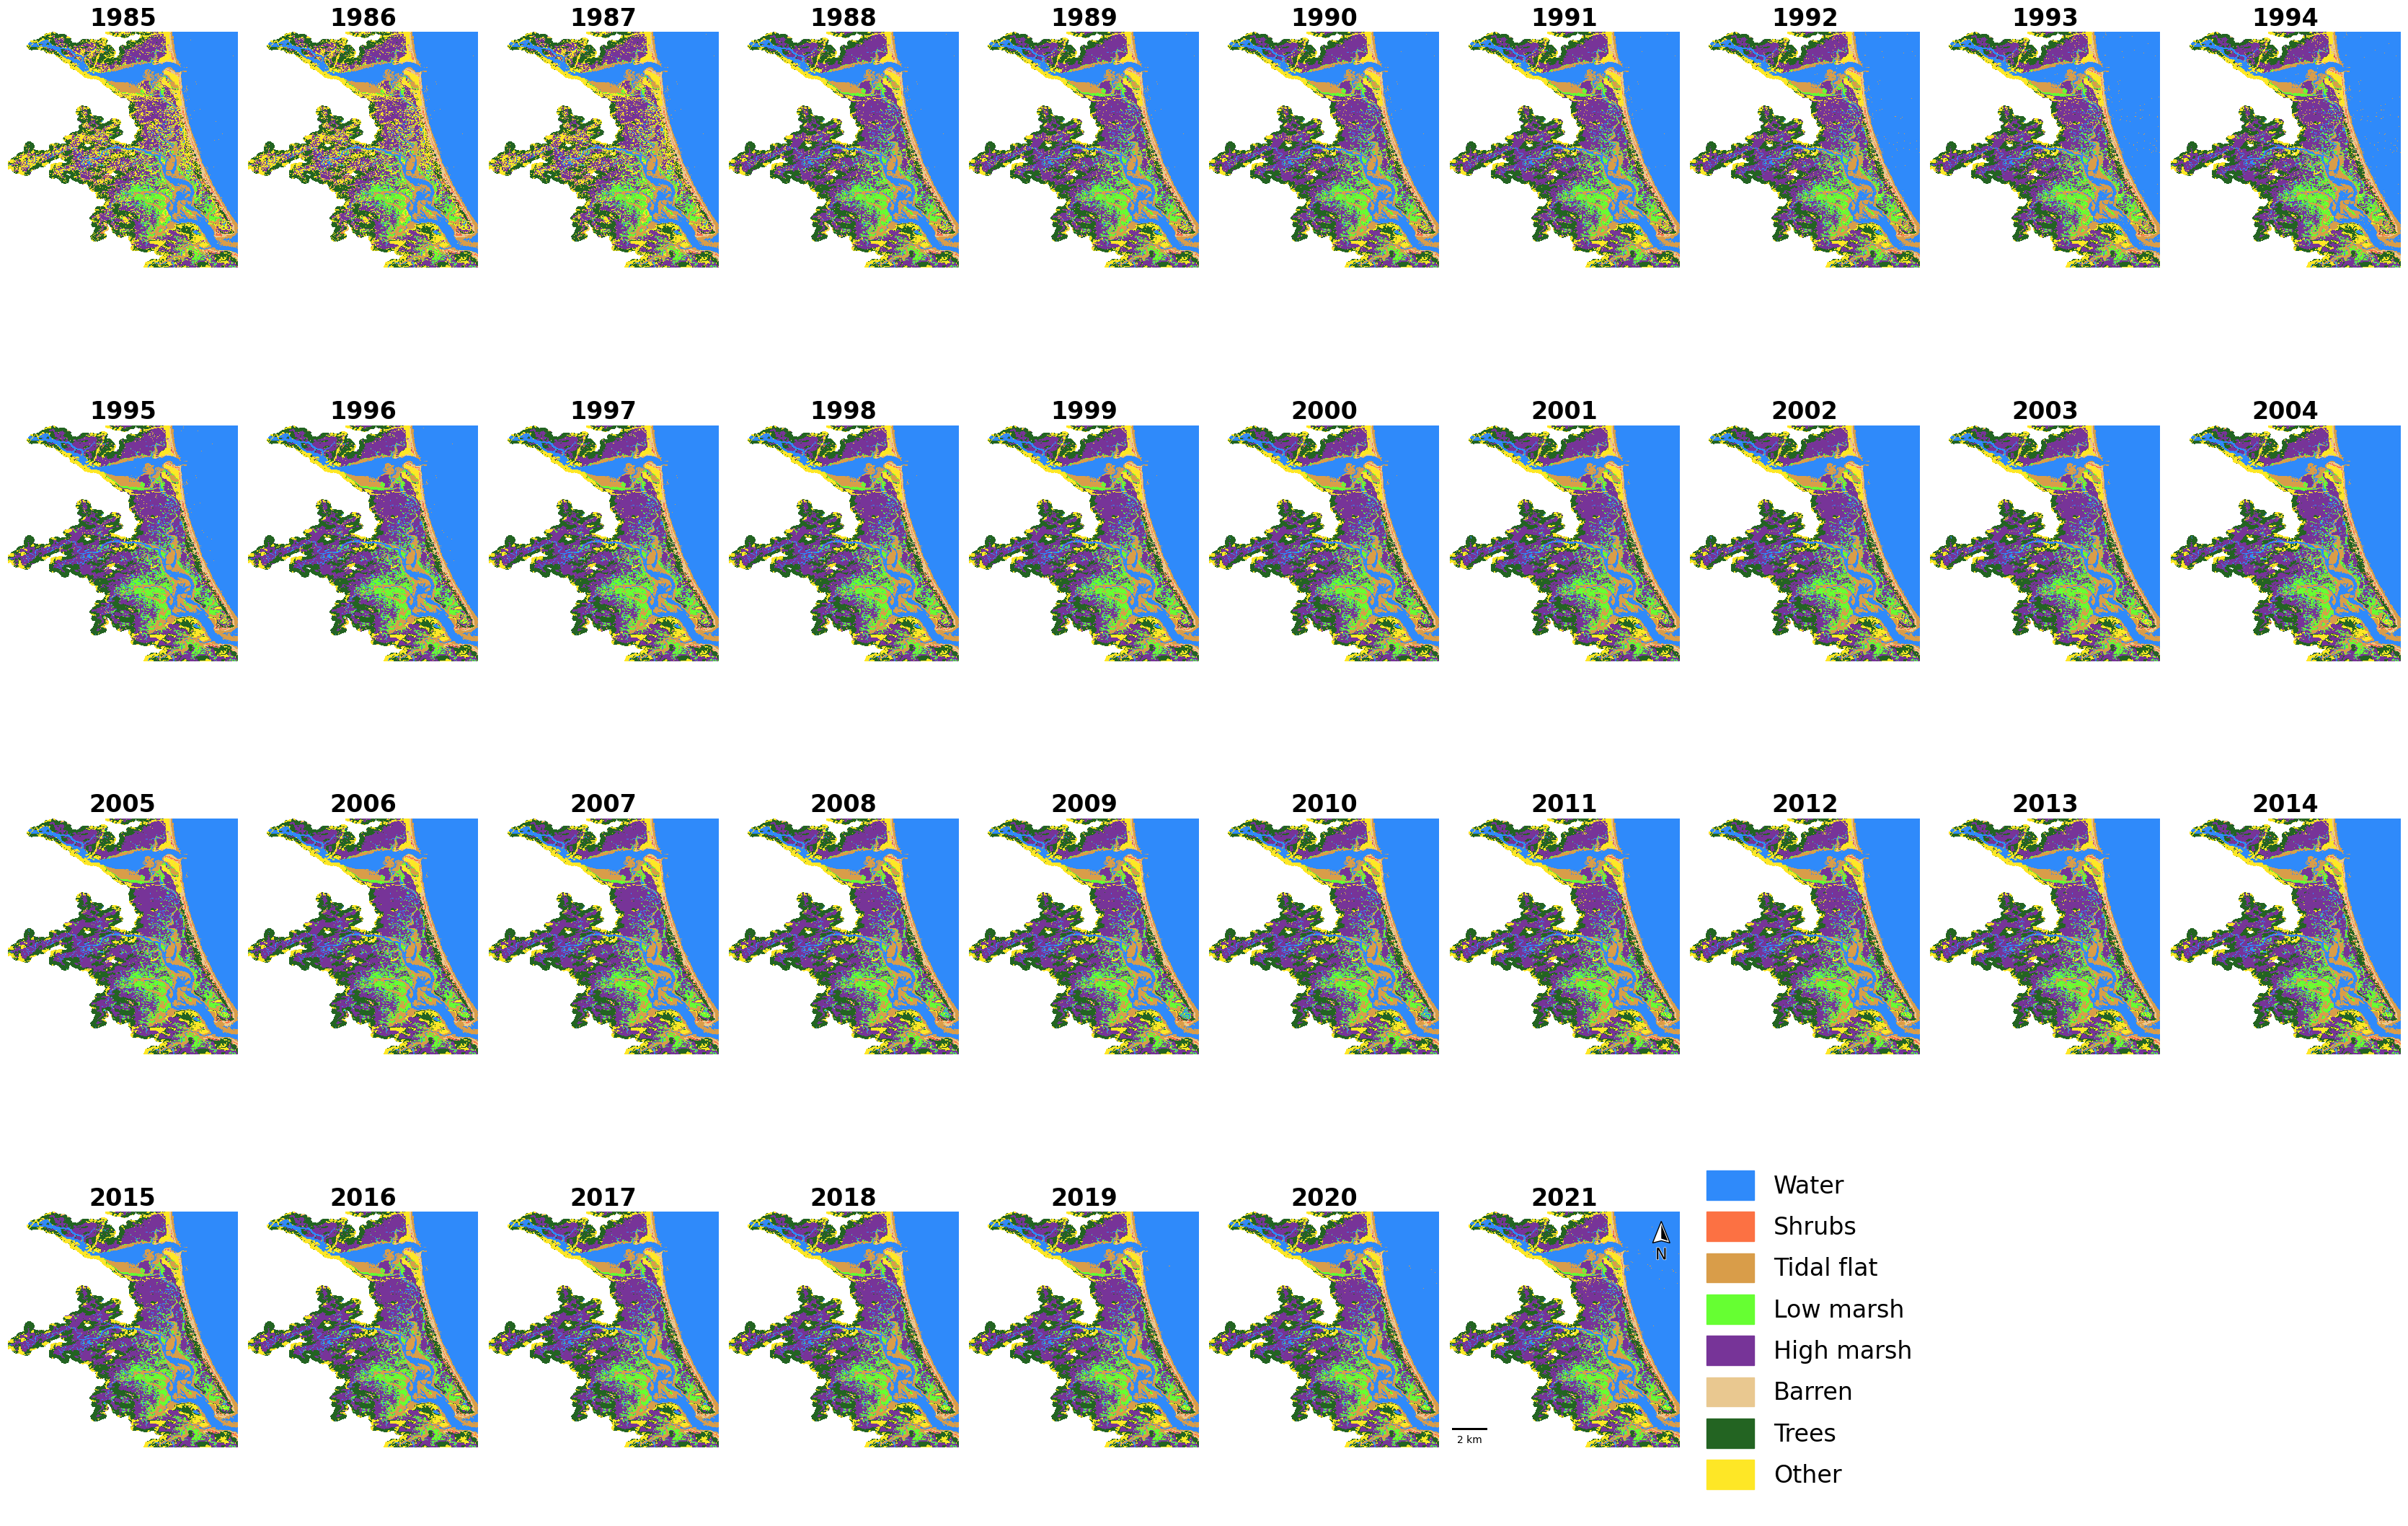

In [ ]:
# @title 5.1 Execute time series maps plot
# Execute function
plot_input_maps(
    class_map=class_labels_dict,
    years=years,
    output_path=output_path,
    image_paths_arg=image_paths,
    nodata_val=noData_value,
    panel_size=(4.0, 6.0),
)

### 5.2 Class size at time points

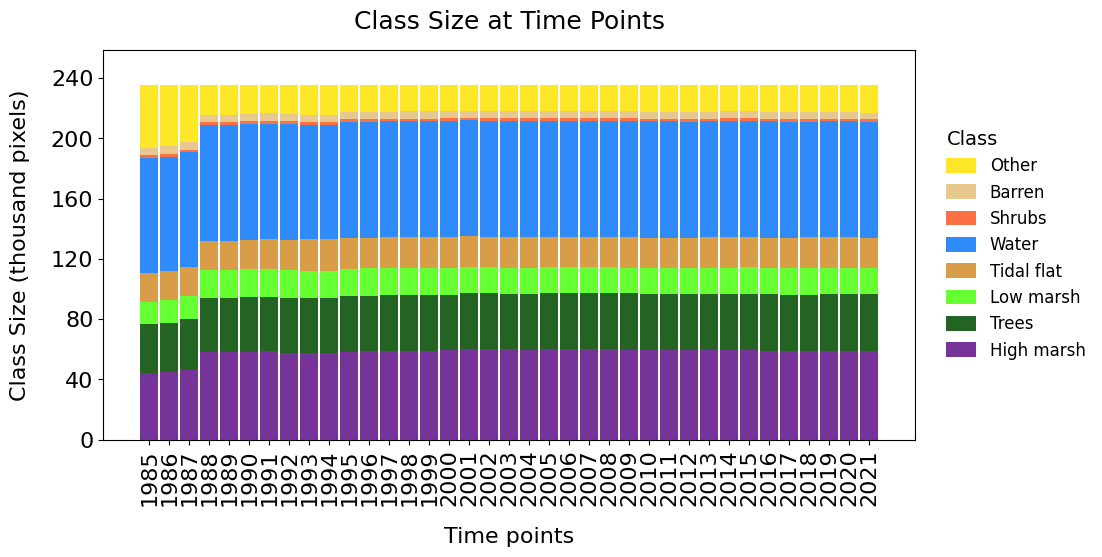

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_class_size_time_points.png


In [ ]:
# @title 5.2 Execute class size plot
# 7. Execute the function by reading the saved CSV
tables_dir = os.path.join(
    output_path,
    "tables",
)

csv_input_path = os.path.join(
    tables_dir,
    "pixels_per_class_per_year.csv",
)

# Check if the file exists to avoid errors
if os.path.exists(csv_input_path):
    # Load the CSV into a DataFrame, setting 'Year' back as the index
    df_loaded = pd.read_csv(
        csv_input_path,
        index_col="Year",
    )

    # Generate the plot using the loaded data
    plot_pixel_counts_bar_chart(
        pivot_pixels=df_loaded,
        class_labels_dict=class_labels_dict,
        output_dir=output_path,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}. "
        "Please run the pixel counting cell first."
    )


### 5.3 Number of changes

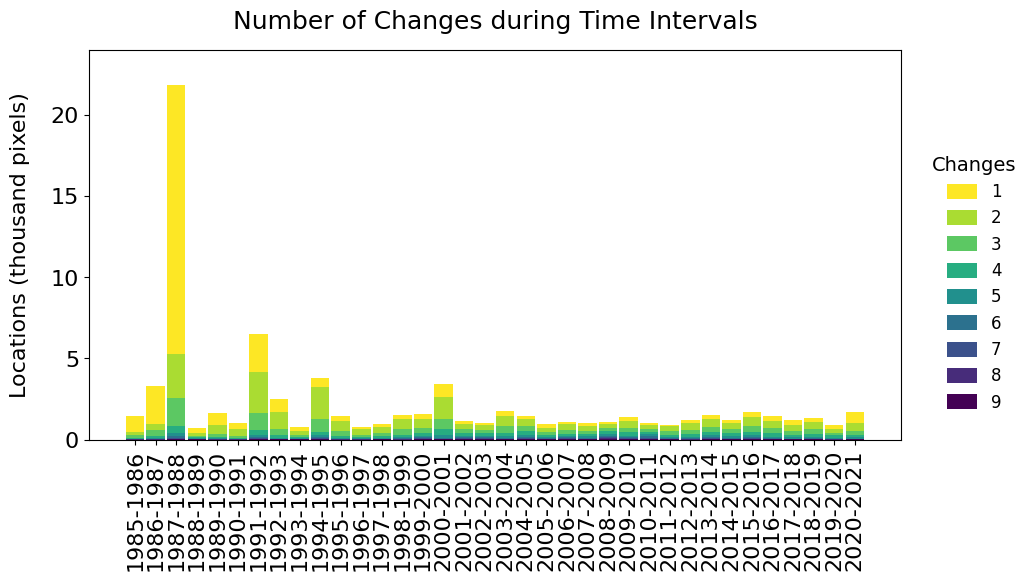

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_number_change_time_interval.png


In [ ]:
# @title 5.3.1 Execute number of changes during time intervals plot
# Execution by reading the saved CSV
tables_dir = os.path.join(
    output_path,
    "tables",
)

csv_input_path = os.path.join(
    tables_dir,
    "number_change_per_interval.csv",
)

# Check if the file exists to avoid errors
if os.path.exists(csv_input_path):
    # Load the CSV, setting the first column (intervals) as the index
    df_loaded_freq = pd.read_csv(
        csv_input_path,
        index_col=0,
    )

    # Generate the plot using the loaded data
    plot_number_change_time_interval(
        df=df_loaded_freq,
        output_path=output_path,
    )
else:
    print(
        f"Error: Could not find the CSV file at {csv_input_path}. "
        "Please run the number of changes calculation cell first."
    )


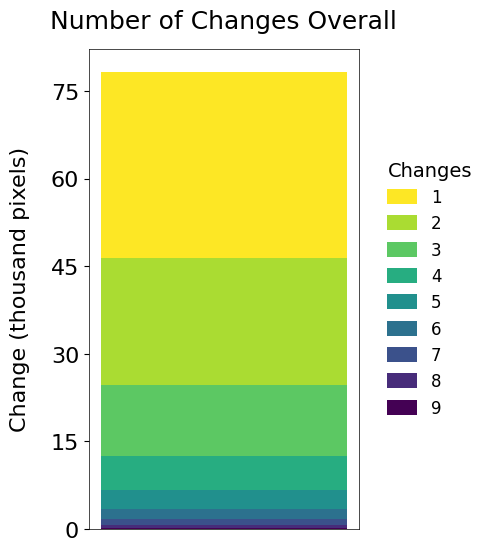

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_number_changes_pixels_overall_default.png


In [ ]:
# @title 5.3.2 Plot default number of changes overall
_plot_stacked_overall_bar_chart(
    output_dir=output_path,
    csv_filename="number_change_overall_summary.csv",
    index_col="Changes",
    value_col="Pixels",
    title="Number of Changes Overall",
    legend_title="Changes",
    output_png_name="chart_number_changes_pixels_overall_default.png",
    color_mode="gradient",
    y_axis_mode="pixel_count",
    y_label_base="Change",
)

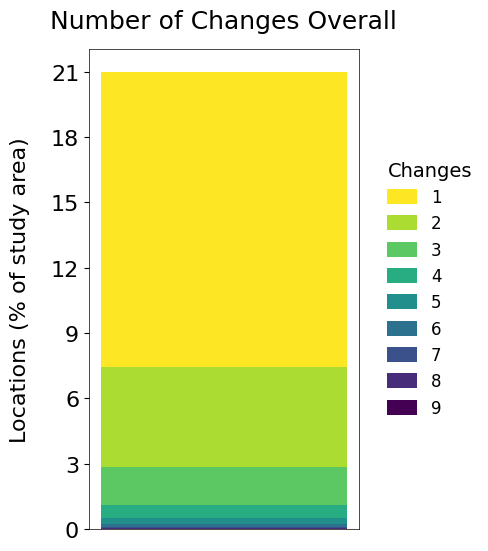

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_number_changes_percentage_overall.png


In [ ]:
# @title 5.3.3 Plot percentage of study area with change
_plot_stacked_overall_bar_chart(
    output_dir=output_path,
    csv_filename="percentage_of_study_area_with_change.csv",
    key_col="Changes",
    value_col="Percentage",
    title="Number of Changes Overall",
    legend_title="Changes",
    output_png_name="chart_number_changes_percentage_overall.png",
    color_mode="gradient",
    y_axis_mode="percentage",
    y_label_fixed="Locations (% of study area)",
)

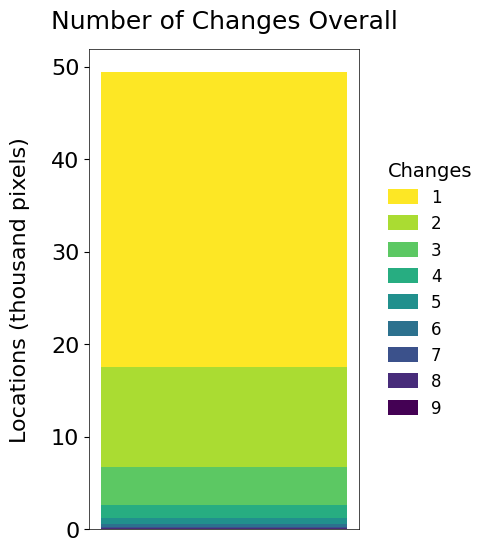

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_number_changes_pixels_overall.png


In [ ]:
# @title 5.3.4 Plot location of changes
_plot_stacked_overall_bar_chart(
    output_dir=output_path,
    csv_filename="number_of_changes_location.csv",
    key_col="Changes",
    value_col="Unique_Pixels",
    title="Number of Changes Overall",
    legend_title="Changes",
    output_png_name="chart_number_changes_pixels_overall.png",
    color_mode="gradient",
    y_axis_mode="pixel_count",
    y_label_base="Locations",
)

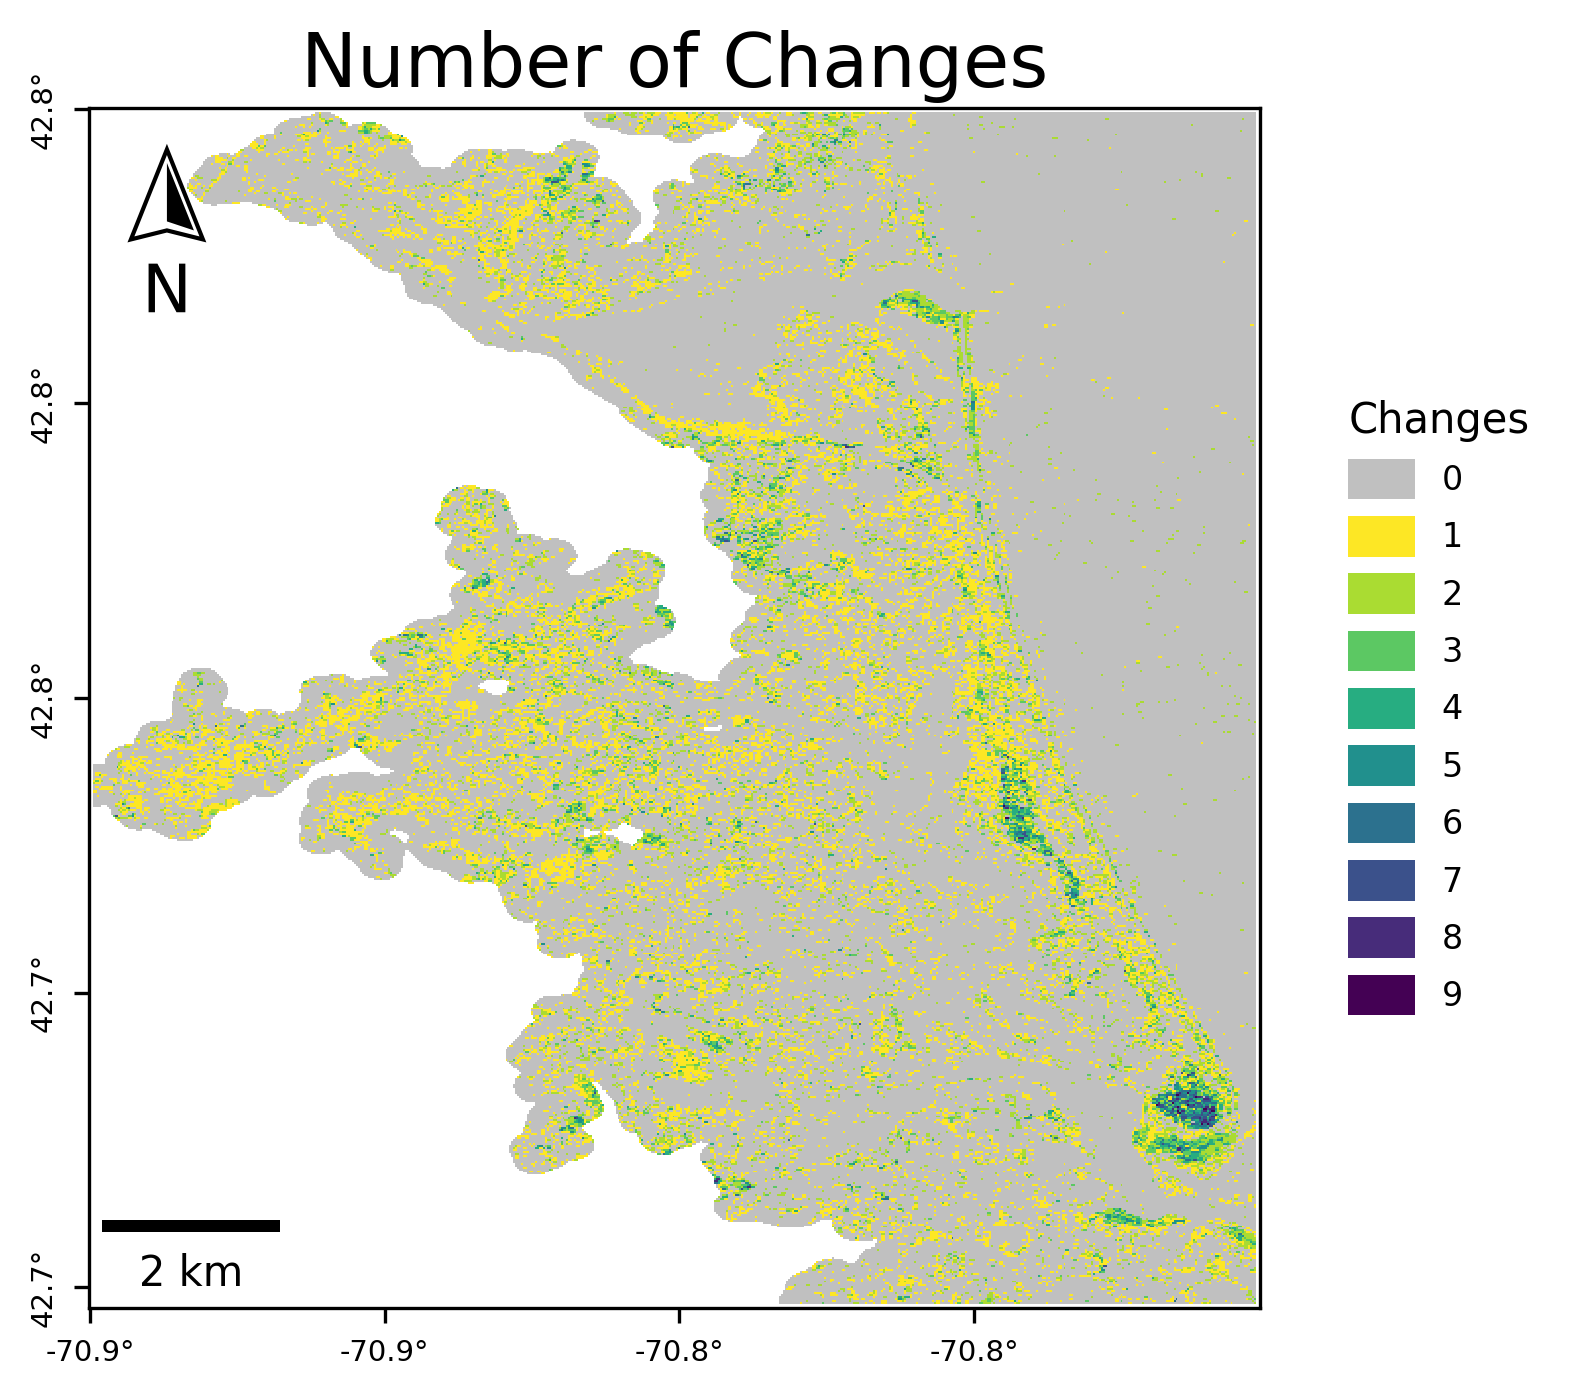

Map figure saved successfully to: /content/drive/MyDrive/Assessments/quest/pie/maps/map_number_of_changes.png


In [ ]:
# @title 5.3.5 Plot number of changes map
_plot_discrete_raster_map(
    output_dir=output_path,
    raster_filename="number_of_changes.tif",
    title="Number of Changes",
    legend_title="Changes",
    output_png_name="map_number_of_changes.png",
    nodata_val=noData_value,
    color_mode="gradient",
    range_mode="data_min",
    filter_present_values=True,
    scalebar_extra_kwargs={"scale_loc": "bottom", "color": "black"},
)

### 5.4 Trajectories

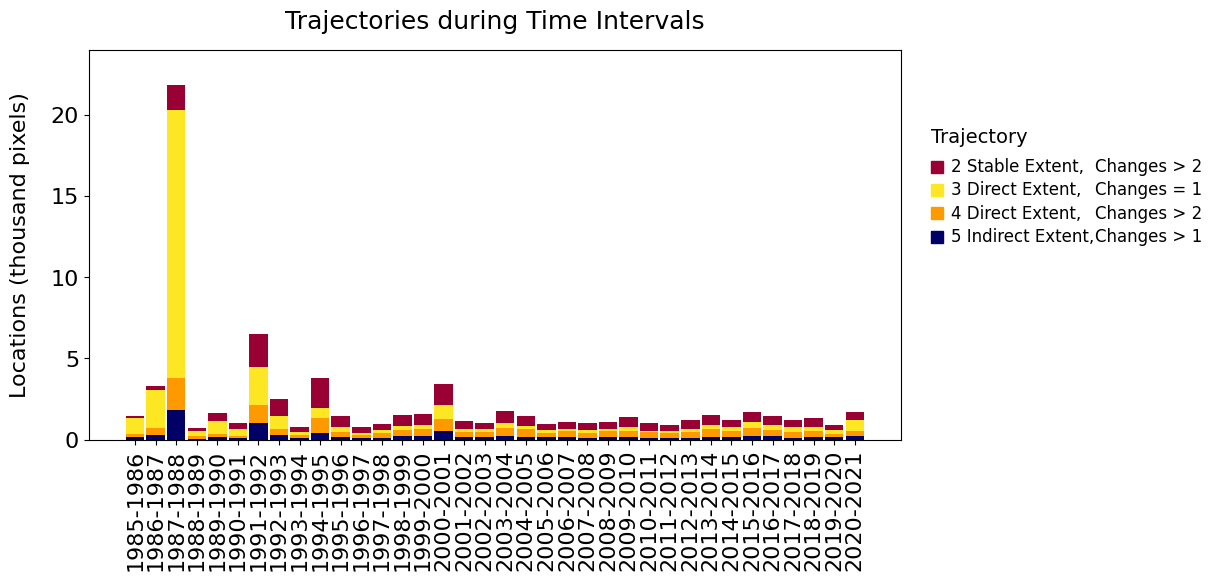

Figure saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_trajectory_time_interval.png


In [ ]:
# @title 5.4.1 Execute trajectory contributions plot
# Execution
# 1. Load the CSV explicitly from the 'tables' folder
csv_path = os.path.join(
    output_path,
    "tables",
    "trajectory_contributions_per_interval.csv",
)
df_trajectory_intervals = pd.read_csv(
    csv_path,
    index_col="Interval",
)

# 2. Execute the visualization
plot_trajectory_contributions(
    df=df_trajectory_intervals,
    output_path=output_path,
)


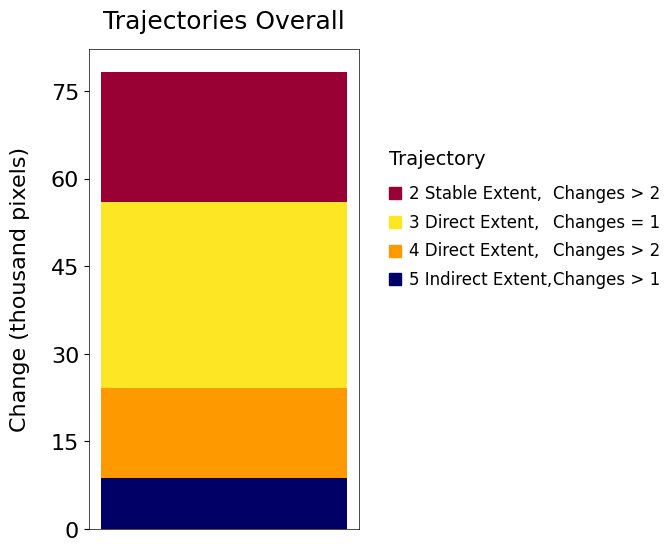

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_trajectory_overall_default.png


In [ ]:
# @title 5.4.2 Plot default trajectory overall
_plot_stacked_overall_bar_chart(
    output_dir=output_path,
    csv_filename="trajectory_total_changes.csv",
    index_col="Trajectory_Class",
    value_col="Total_Changes",
    title="Trajectories Overall",
    legend_title="Trajectory",
    output_png_name="chart_trajectory_overall_default.png",
    color_mode="fixed",
    fixed_colors={
        5: "#000066",
        4: "#ff9900",
        3: "#FDE724",
        2: "#990033",
        1: "#d9d9d9",
    },
    category_order=[5, 4, 3, 2, 1],
    y_axis_mode="pixel_count",
    y_label_base="Change",
    legend_mode="computed",
    legend_labels={
        2: "2 Stable Extent,   Changes > 2",
        3: "3 Direct Extent,    Changes = 1",
        4: "4 Direct Extent,    Changes > 2",
        5: "5 Indirect Extent, Changes > 1",
    },
)

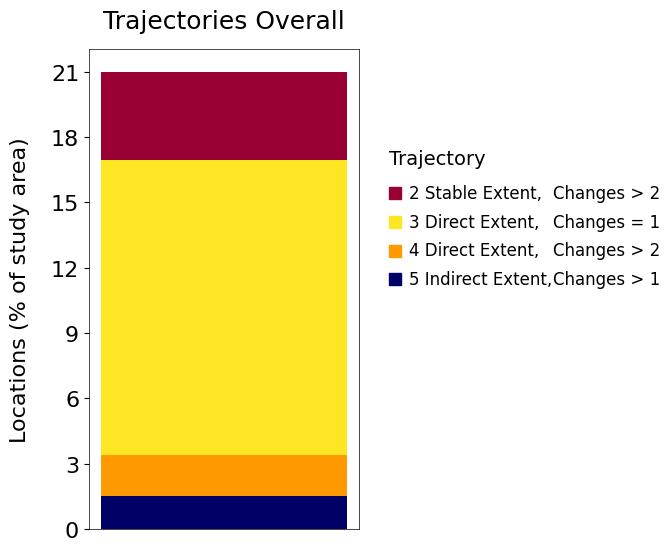

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_trajectory_percentage_overall.png


In [ ]:
# @title 5.4.3 Plot the percentage of the study area with trajectories
_plot_stacked_overall_bar_chart(
    output_dir=output_path,
    csv_filename="trajectory_distribution_percentage.csv",
    key_col="Trajectory",
    value_col="Percentage",
    title="Trajectories Overall",
    legend_title="Trajectory",
    output_png_name="chart_trajectory_percentage_overall.png",
    color_mode="fixed",
    fixed_colors={
        5: "#000066",
        4: "#ff9900",
        3: "#FDE724",
        2: "#990033",
    },
    category_order=[5, 4, 3, 2],
    y_axis_mode="percentage",
    y_label_fixed="Locations (% of study area)",
    legend_mode="fixed_list",
    legend_categories=[2, 3, 4, 5],
    legend_labels={
        2: "2 Stable Extent,   Changes > 2",
        3: "3 Direct Extent,    Changes = 1",
        4: "4 Direct Extent,    Changes > 2",
        5: "5 Indirect Extent, Changes > 1",
    },
)

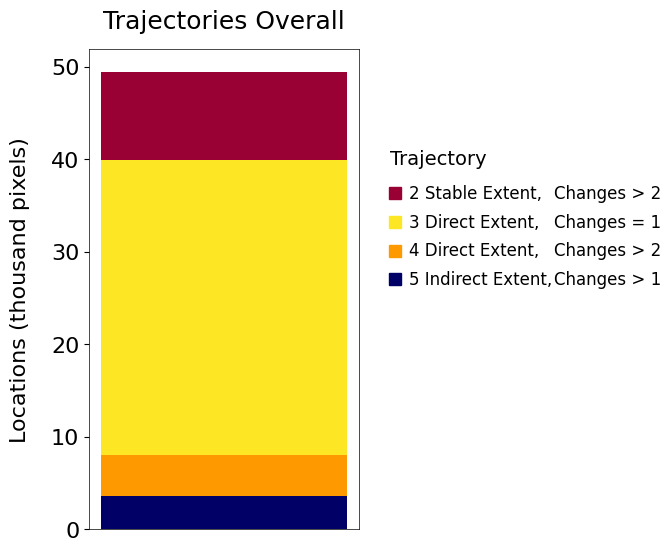

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_trajectory_location_overall.png


In [ ]:
# @title 5.4.4 Plot location of trajectories
_plot_stacked_overall_bar_chart(
    output_dir=output_path,
    csv_filename="trajectory_distribution_location.csv",
    key_col="Trajectory",
    value_col="Pixels",
    title="Trajectories Overall",
    legend_title="Trajectory",
    output_png_name="chart_trajectory_location_overall.png",
    color_mode="fixed",
    fixed_colors={
        5: "#000066",
        4: "#ff9900",
        3: "#FDE724",
        2: "#990033",
    },
    category_order=[5, 4, 3, 2],
    y_axis_mode="pixel_count",
    y_label_base="Locations",
    legend_mode="fixed_list",
    legend_categories=[2, 3, 4, 5],
    legend_labels={
        2: "2 Stable Extent,   Changes > 2",
        3: "3 Direct Extent,    Changes = 1",
        4: "4 Direct Extent,    Changes > 2",
        5: "5 Indirect Extent, Changes > 1",
    },
)

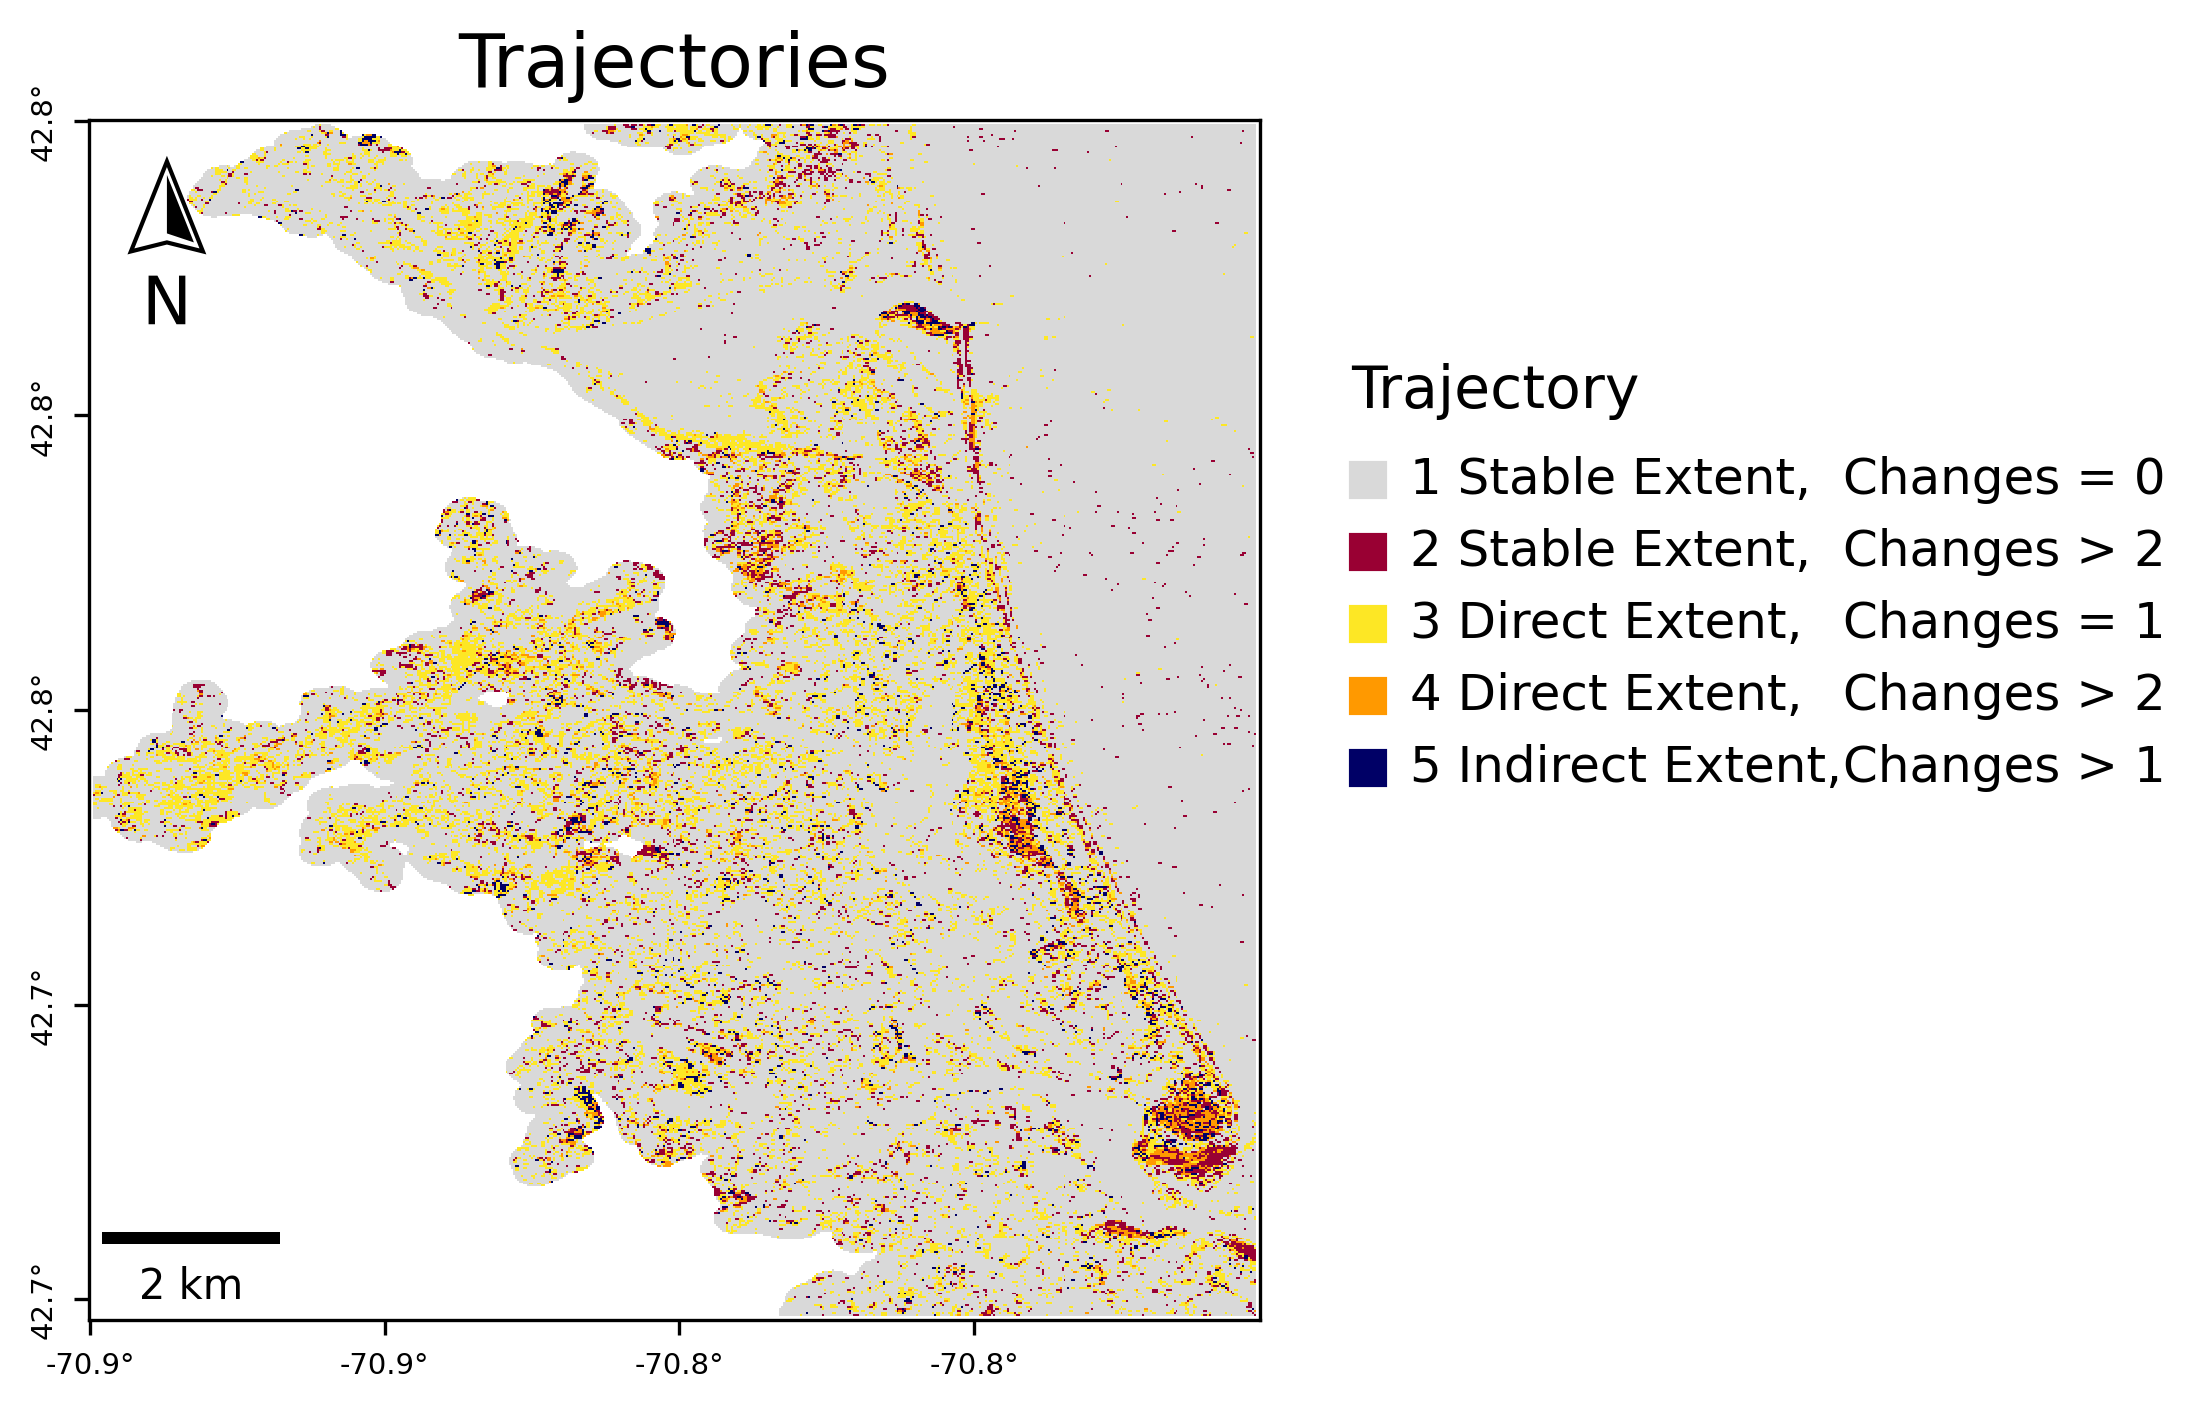

Map figure saved successfully to: /content/drive/MyDrive/Assessments/quest/pie/maps/map_trajectories.png


In [ ]:
# @title 5.4.5 Plot trajectory map
_plot_discrete_raster_map(
    output_dir=output_path,
    raster_filename="trajectory.tif",
    title="Trajectories",
    legend_title="Trajectory",
    output_png_name="map_trajectories.png",
    color_mode="fixed",
    fixed_colors=[
        "#d9d9d9",  # Trajectory 1
        "#990033",  # Trajectory 2
        "#FDE725",  # Trajectory 3
        "#ff9900",  # Trajectory 4
        "#000066",  # Trajectory 5
    ],
    fixed_labels=[
        "1 Stable Extent,   Changes = 0",
        "2 Stable Extent,   Changes > 2",
        "3 Direct Extent,    Changes = 1",
        "4 Direct Extent,    Changes > 2",
        "5 Indirect Extent, Changes > 1",
    ],
    legend_patch_edgecolor="black",
    legend_extra_kwargs={
        "bbox_to_anchor": (1.02, 0.5),
        "borderpad": 1.2,
        "handletextpad": 0.8,
        "columnspacing": 2,
        "labelspacing": 0.8,
    },
    title_pad=8,
)

### 5.5 Change component heatmaps and charts

Generating Heatmaps...


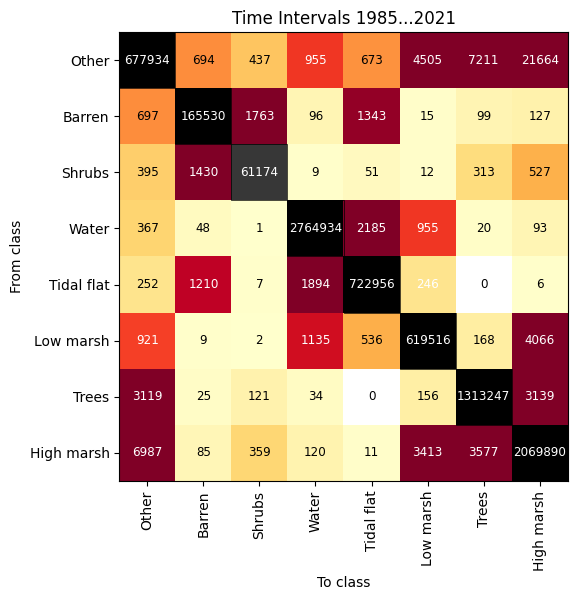

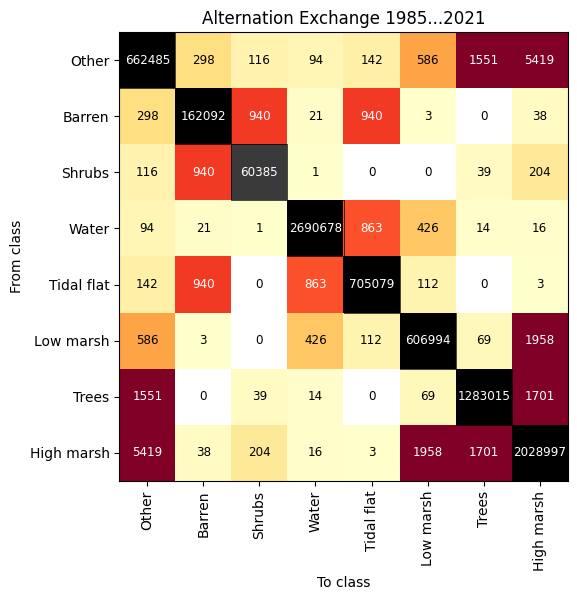

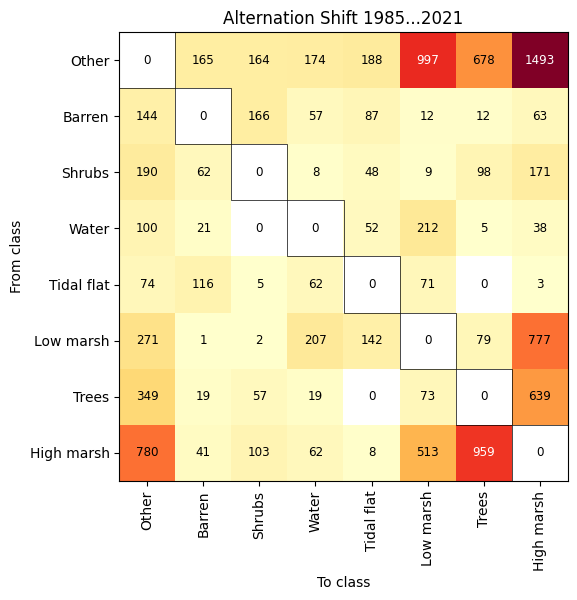

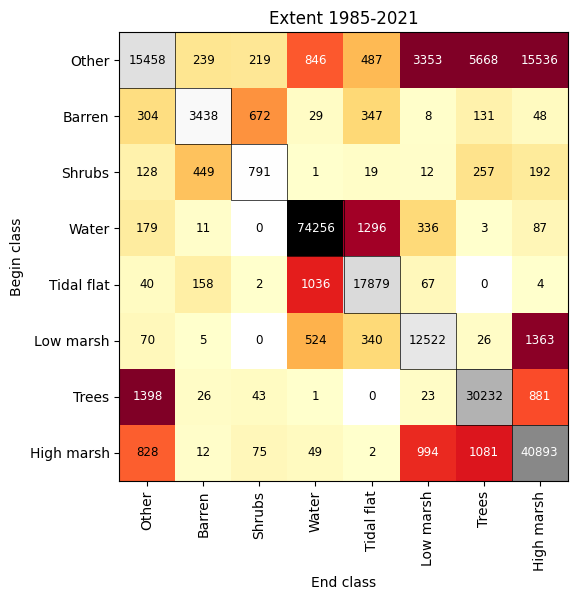

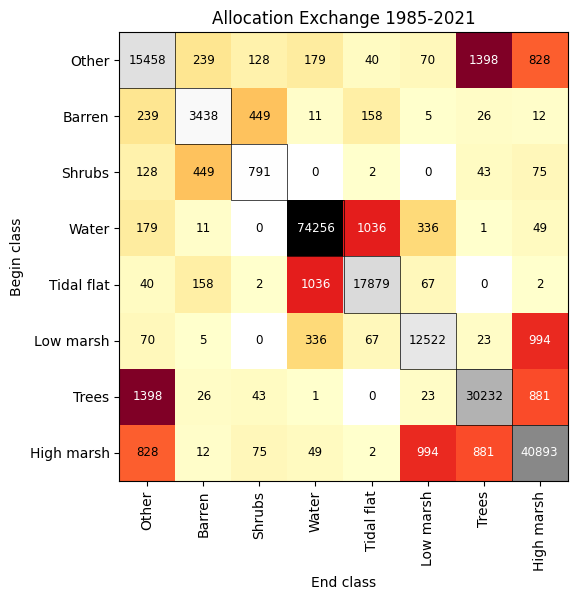

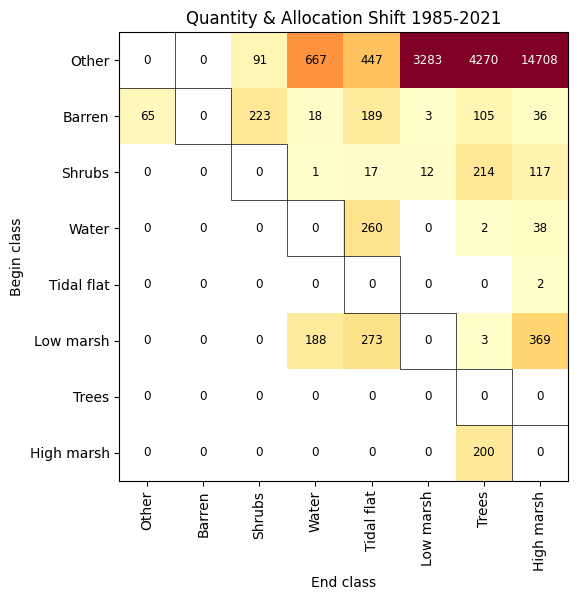

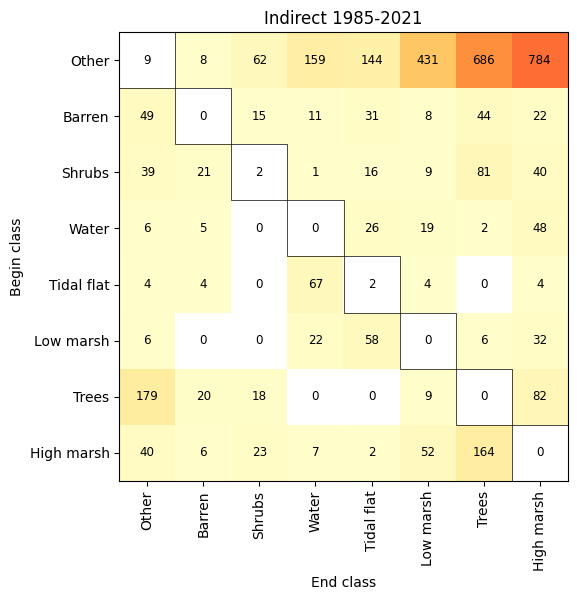

All heatmaps saved to: /content/drive/MyDrive/Assessments/quest/pie/charts


In [ ]:
# @title 5.5.1 Plot heatmaps
# 1. Define visual style configuration
# Adjust the values below to customize the appearance of all 7 heatmaps.
style_config = {
    # Font size for the class names on the X-axis (bottom)
    "tick_fontsize_x": 10,

    # Font size for the class names on the Y-axis (left)
    "tick_fontsize_y": 10,

    # Font size for the axis labels ("To class", "Begin class", etc.)
    "axis_label_fontsize": 10,

    # Font size for the main title of the heatmap
    "title_fontsize": 12,

    # Colormap for positive values (default is Yellow-Orange-Red: "YlOrRd")
    "cmap": "YlOrRd",

    # Base size of each cell in inches (controls the overall figure size)
    "cell_size_inch": 0.8,

    # Auto color scale bounds
    "vmin": 0.0,
    "vmax": None,
}

print(
    "Generating Heatmaps...",
)

# Identify the maximum value of the diagonal of the "Allocation Exchange" (all_exc) matrix
global_diag_vmax = float(np.diag(matrices["all_exc"].values).max())

# Identify the maximum off-diagonal value of the "Allocation Exchange" (all_exc) matrix
# to standardize the color scale across all matrices.
all_exc_vals = matrices["all_exc"].values.astype(float).copy()
np.fill_diagonal(all_exc_vals, 0.0)
global_off_diag_vmax = float(np.nanmax(all_exc_vals))
if global_off_diag_vmax <= 0.0:
    global_off_diag_vmax = 1.0

# Update style_config to apply the global scale
style_config["vmax"] = global_off_diag_vmax

# Calculate a uniform font size based on the "Time Intervals" (sum) matrix to prevent overflow
sum_matrix_vals = matrices["sum"].values
max_digits = 0
for i in range(sum_matrix_vals.shape[0]):
    for j in range(sum_matrix_vals.shape[1]):
        val = float(sum_matrix_vals[i, j])
        if not np.isnan(val):
            num_digits = len(f"{int(round(val))}")
            if num_digits > max_digits:
                max_digits = num_digits

base_fs = 20.0 # base annotation font size
if max_digits > 3:
    scale_factor = max(0.4, 3.0 / max_digits)
    global_ann_fontsize = max(5.0, base_fs * scale_factor)
else:
    global_ann_fontsize = base_fs

style_config["ann_fontsize"] = global_ann_fontsize

# 2. Iterate and plot each heatmap
for key, meta in MATRIX_META.items():
    suffix = meta[0]
    title_part = meta[1]
    m_type = meta[2]

    df_to_plot = matrices[key]

    is_flow = m_type == "flow"
    label_suffix = "..." if is_flow else "-"

    full_title = f"{title_part} {str_y0}{label_suffix}{str_y1}"

    save_fig_path = os.path.join(
        output_path,
        "charts",
        f"heatmap_{suffix}_{interval_str}.png",
    )

    x_label = "To class" if is_flow else "End class"
    y_label = "From class" if is_flow else "Begin class"

    is_extent = (key == "ext")

    # Identify blank cells for the specific matrix (Time Intervals = sum)
    # Beach = '3', Water = '4'
    white_cells = []
    if key == "sum":
        labels_list = list(df_to_plot.index)
        if '3' in labels_list and '4' in labels_list:
            row_idx = labels_list.index('3')
            col_idx = labels_list.index('4')
            white_cells.append((row_idx, col_idx))

    plot_heatmap(
        df=df_to_plot,
        title=full_title,
        save_path=save_fig_path,
        xlabel=x_label,
        ylabel=y_label,
        show_diagonal_values=True,
        equalize_diagonal_font=is_extent,
        white_cells=white_cells,
        diag_vmax=global_diag_vmax,
        **style_config,
    )

final_out_dir = os.path.join(
    output_path,
    "charts",
)

print(
    f"All heatmaps saved to: {final_out_dir}",
)


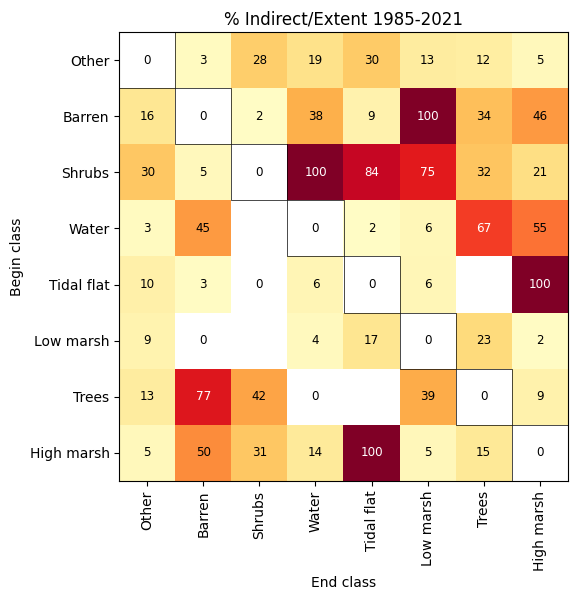

Plot saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/heatmap_indirect_ratio_1985-2021.png


In [ ]:
# @title 5.5.2 Plot indirect ratio heatmap
str_y0 = _extract_year_str(years[0])
str_y1 = _extract_year_str(years[-1])
interval_str = f"{str_y0}-{str_y1}"

# 1. Load the ratio matrix from the previously generated CSV
csv_filename = f"transition_matrix_indirect_ratio_{interval_str}.csv"
csv_path_ratio = os.path.join(
    output_path,
    "tables",
    csv_filename,
)

df_unaccounted_ratio = pd.read_csv(
    csv_path_ratio,
    index_col=0,
)

# Convert index/columns back to string for consistency
df_unaccounted_ratio.index = df_unaccounted_ratio.index.map(
    str,
)
df_unaccounted_ratio.columns = df_unaccounted_ratio.columns.map(
    str,
)

# Reorder based on the sum matrix order (to keep it consistent with other maps)
if "sum" in matrices:
    order_labels = list(
        matrices["sum"].index,
    )
    df_unaccounted_ratio = df_unaccounted_ratio.reindex(
        index=order_labels,
        columns=order_labels,
    )

# 2. Plot the heatmap using formatting from the no-legend panel
chart_filename = f"heatmap_indirect_ratio_{interval_str}.png"
chart_path_ratio = os.path.join(
    output_path,
    "charts",
    chart_filename,
)

# Determine max value for color scale (ignoring NaNs safely)
valid_vals = df_unaccounted_ratio.values[
    np.isfinite(
        df_unaccounted_ratio.values,
    )
]
if valid_vals.size > 0:
    max_val = float(
        np.nanmax(
            valid_vals,
        ),
    )
else:
    max_val = 100.0

if max_val <= 0:
    max_val = 100.0

plot_heatmap(
    df=df_unaccounted_ratio,
    title=f"% Indirect/Extent {interval_str}",
    save_path=chart_path_ratio,
    xlabel="End class",
    ylabel="Begin class",
    show_diagonal_values=True,
    equalize_diagonal_font=True,
    white_cells=[],
    vmin=0.0,
    vmax=max_val,
    diag_vmax=100.0,
    ann_fontsize=global_ann_fontsize, # Uses global font size computed before
    tick_fontsize_x=10,
    tick_fontsize_y=10,
    axis_label_fontsize=10,
    title_fontsize=12,
    cmap="YlOrRd",
    cell_size_inch=0.8,
)

print(
    f"Plot saved to: {chart_path_ratio}",
)


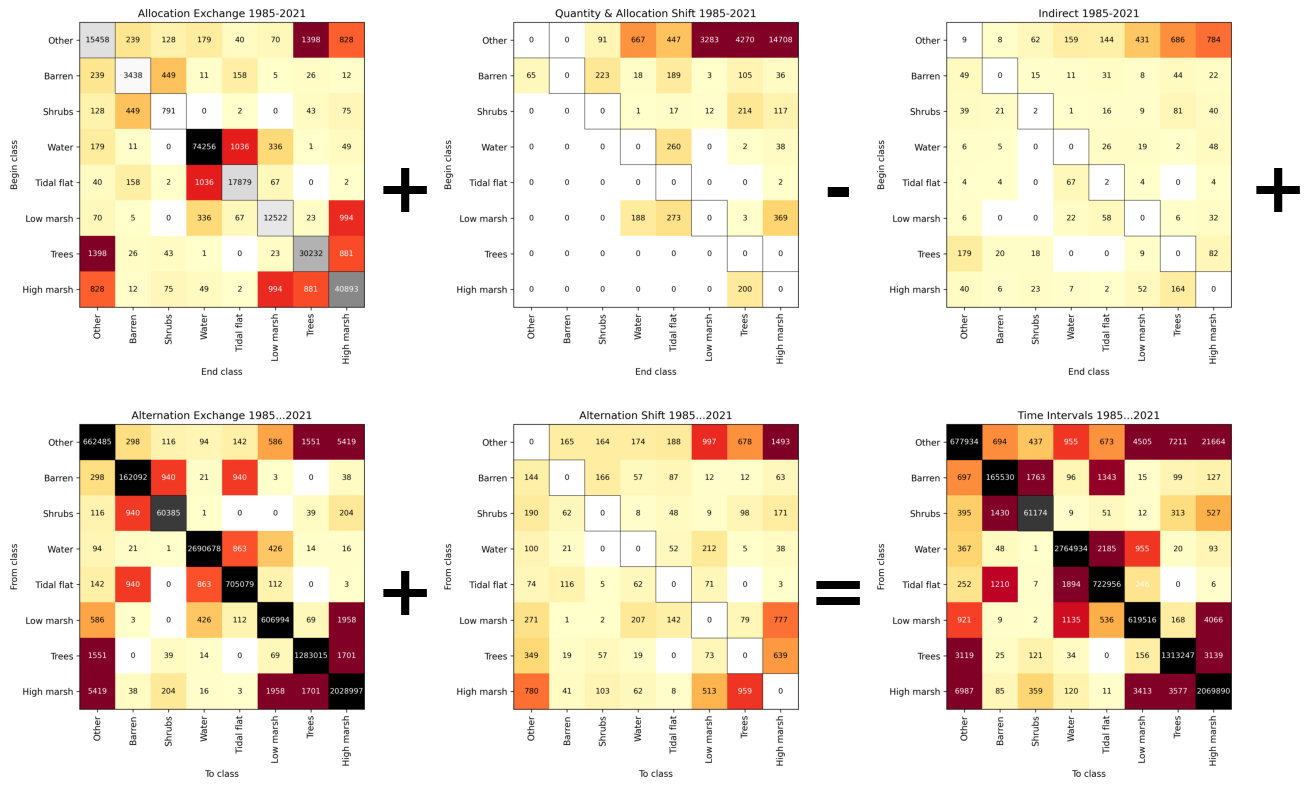

Alternative heatmap panel saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/heatmap_panel_1985-2021.png


In [ ]:
# @title 5.5.3 Execute heatmap panel plot
# Execute
create_heatmap_panel(
    output_dir=output_path,
    interval=interval_str,
)


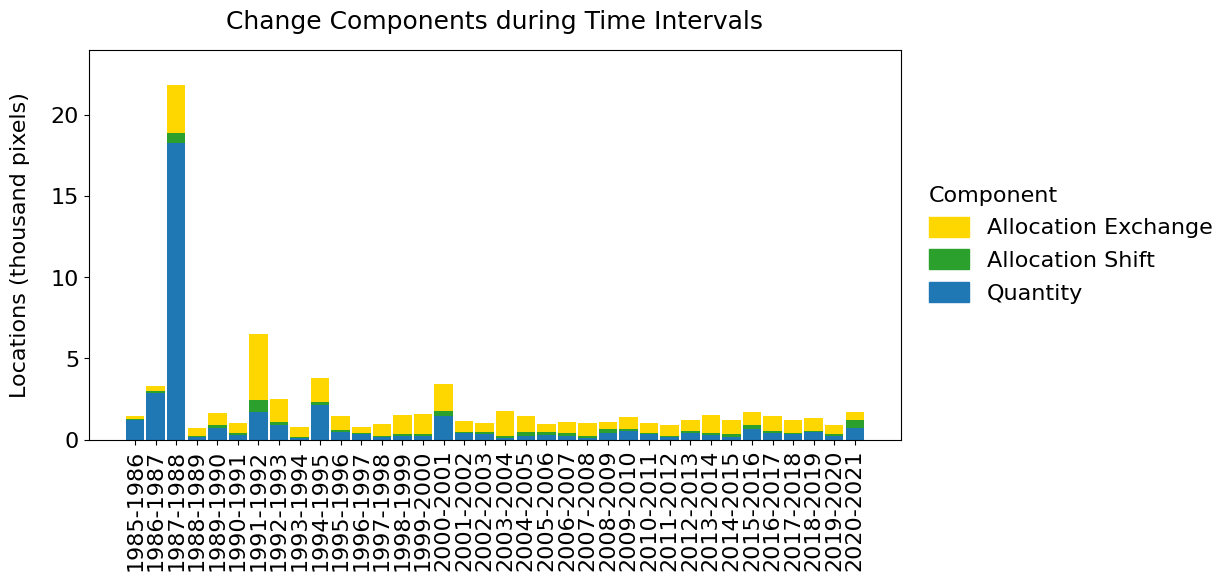

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_change_components_time_interval.png


In [ ]:
# @title 5.5.4 Plot change components during time intervals

# Read change components CSV from the tables folder
csv_path = os.path.join(
    output_path,
    "tables",
    "change_components.csv",
)
df = pd.read_csv(
    csv_path,
)

# Filter only time intervals
time_df = df[
    df["Time_Interval"].str.contains("-")
]

# Aggregate totals per interval and component (Gain)
totals = (
    time_df.groupby(
        ["Time_Interval", "Component"],
    )["Gain"]
    .sum()
    .unstack()
)

# Choose scale automatically based on max value
max_val = totals[["Quantity", "Shift", "Exchange"]].to_numpy().max()

if max_val >= 1_000_000_000_000:
    scale_factor = 1_000_000_000_000
    suffix = " (trillion pixels)"
elif max_val >= 1_000_000_000:
    scale_factor = 1_000_000_000
    suffix = " (billion pixels)"
elif max_val >= 1_000_000:
    scale_factor = 1_000_000
    suffix = " (million pixels)"
elif max_val >= 1_000:
    scale_factor = 1_000
    suffix = " (thousand pixels)"
elif max_val >= 100:
    scale_factor = 100
    suffix = " (hundred pixels)"
else:
    scale_factor = 1
    suffix = " (pixels)"

y_label = f"Locations{suffix}"

# Scaled totals per component for plotting
scaled_totals = totals[
    [
        "Quantity",
        "Shift",
        "Exchange",
    ]
] / scale_factor

# Maximum stacked height (Quantity + Exchange + Shift)
stacked_max = scaled_totals.sum(
    axis=1,
).max()

# Create figure and axis
fig, ax = plt.subplots(
    figsize=(
        14,
        6,
    ),
)

# Colors
colors = [
    "#1f77b4",  # Quantity
    "#2ca02c",  # Shift
    "#ffd700",  # Exchange

]
components_color = {
    "Quantity": "#1f77b4",
    "Shift":    "#2ca02c",
    "Exchange": "#ffd700"

}

# Stacked bars using scaled values
for idx, comp in enumerate(
    [
        "Quantity",
        "Shift",
        "Exchange",
    ],
):
    bottom_values = (
        scaled_totals.iloc[:, :idx].sum(
            axis=1,
        )
        if idx > 0
        else 0
    )
    ax.bar(
        totals.index,
        scaled_totals[comp],
        label=comp,
        color=colors[idx],
        edgecolor="none",
        bottom=bottom_values,
        width=0.9,
    )

# Axes formatting
ax.set_ylabel(
    y_label,
    fontsize=16,
    labelpad=15
)
ax.set_title(
    "Change Components during Time Intervals",
    fontsize=18,
    pad=15
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=16,
)

# Adaptive rotation for x-axis tick labels
labels = ax.get_xticklabels()
n_labels = len(labels)

if n_labels <= 6:
    rotation = 0
    ha = "center"
elif n_labels <= 12:
    rotation = 45
    ha = "right"
else:
    rotation = 90
    ha = "center"

plt.setp(
    labels,
    rotation=rotation,
    ha=ha,
)

# Dynamically set y-axis limits and ticks
ax.set_ylim(0, stacked_max * 1.1 if stacked_max > 0 else 1.0)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=6))

# Legend (custom labels)
legend_elements = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=components_color["Exchange"],
        label="Allocation Exchange",
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=components_color["Shift"],
        label="Allocation Shift",
    ),
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=components_color["Quantity"],
        label="Quantity",
    ),
]
ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(
        1.01,
        0.5,
    ),
    title="Component",
    title_fontsize=16,
    fontsize=16,
    alignment="left",
    frameon=False,
    handlelength=1.8,
    handleheight=1.0,
    labelspacing=0.5,
    handletextpad=0.8
)

# Force main plotting box spatial coordinates to match other interval charts
fig.subplots_adjust(
    left=0.1,
    right=0.68,
    bottom=0.25,
    top=0.9,
)

# Save and show
charts_dir = os.path.join(
    output_path,
    "charts",
)
os.makedirs(
    charts_dir,
    exist_ok=True,
)

out_fig_path = os.path.join(
    charts_dir,
    "chart_change_components_time_interval.png",
)

plt.savefig(
    out_fig_path,
    format="png",
    dpi=300,
)
plt.show()
plt.close(fig)

print(f"Chart saved to: {out_fig_path}")

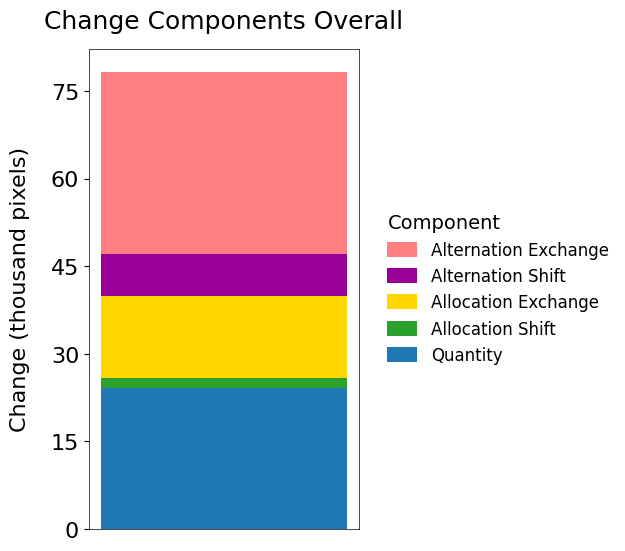

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_change_components_overall.png


In [ ]:
# @title 5.5.5 Execute overall change component plot
# 10. Specify paths and execute the plotting function
summary_csv_path = os.path.join(
    output_path,
    "tables",
    "change_components_overall_summary.csv"
)

plot_overall_change_components(
    summary_csv_path=summary_csv_path,
    output_path=output_path,
)


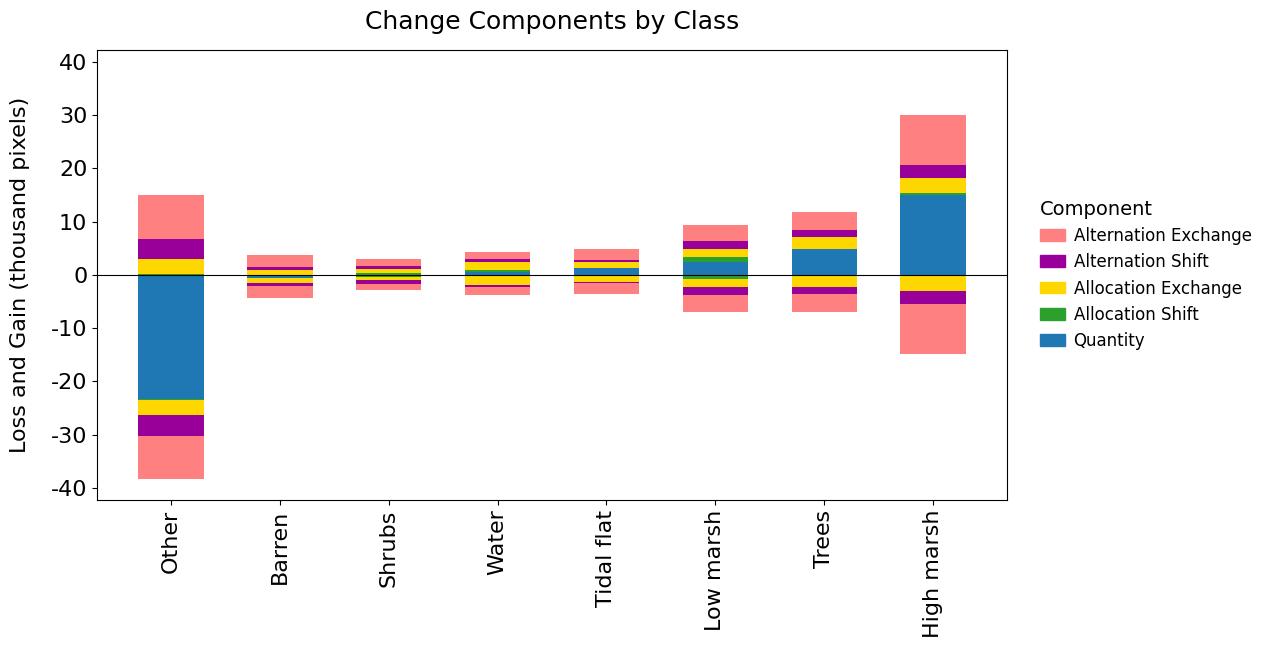

Chart saved to: /content/drive/MyDrive/Assessments/quest/pie/charts/chart_change_component_change_class.png


In [ ]:
# @title 5.5.6 Execute change components by class plot
# 8. Execution
csv_path = os.path.join(
    output_path,
    "tables",
    "change_components.csv",
)
df = pd.read_csv(
    csv_path,
)

ComponentVisualizer.plot_gain_loss_stacked(
    df=df,
    class_labels_dict=class_labels_dict,
    title="Change Components by Class",
    output_path=output_path,
)


### 5.6 Change component maps

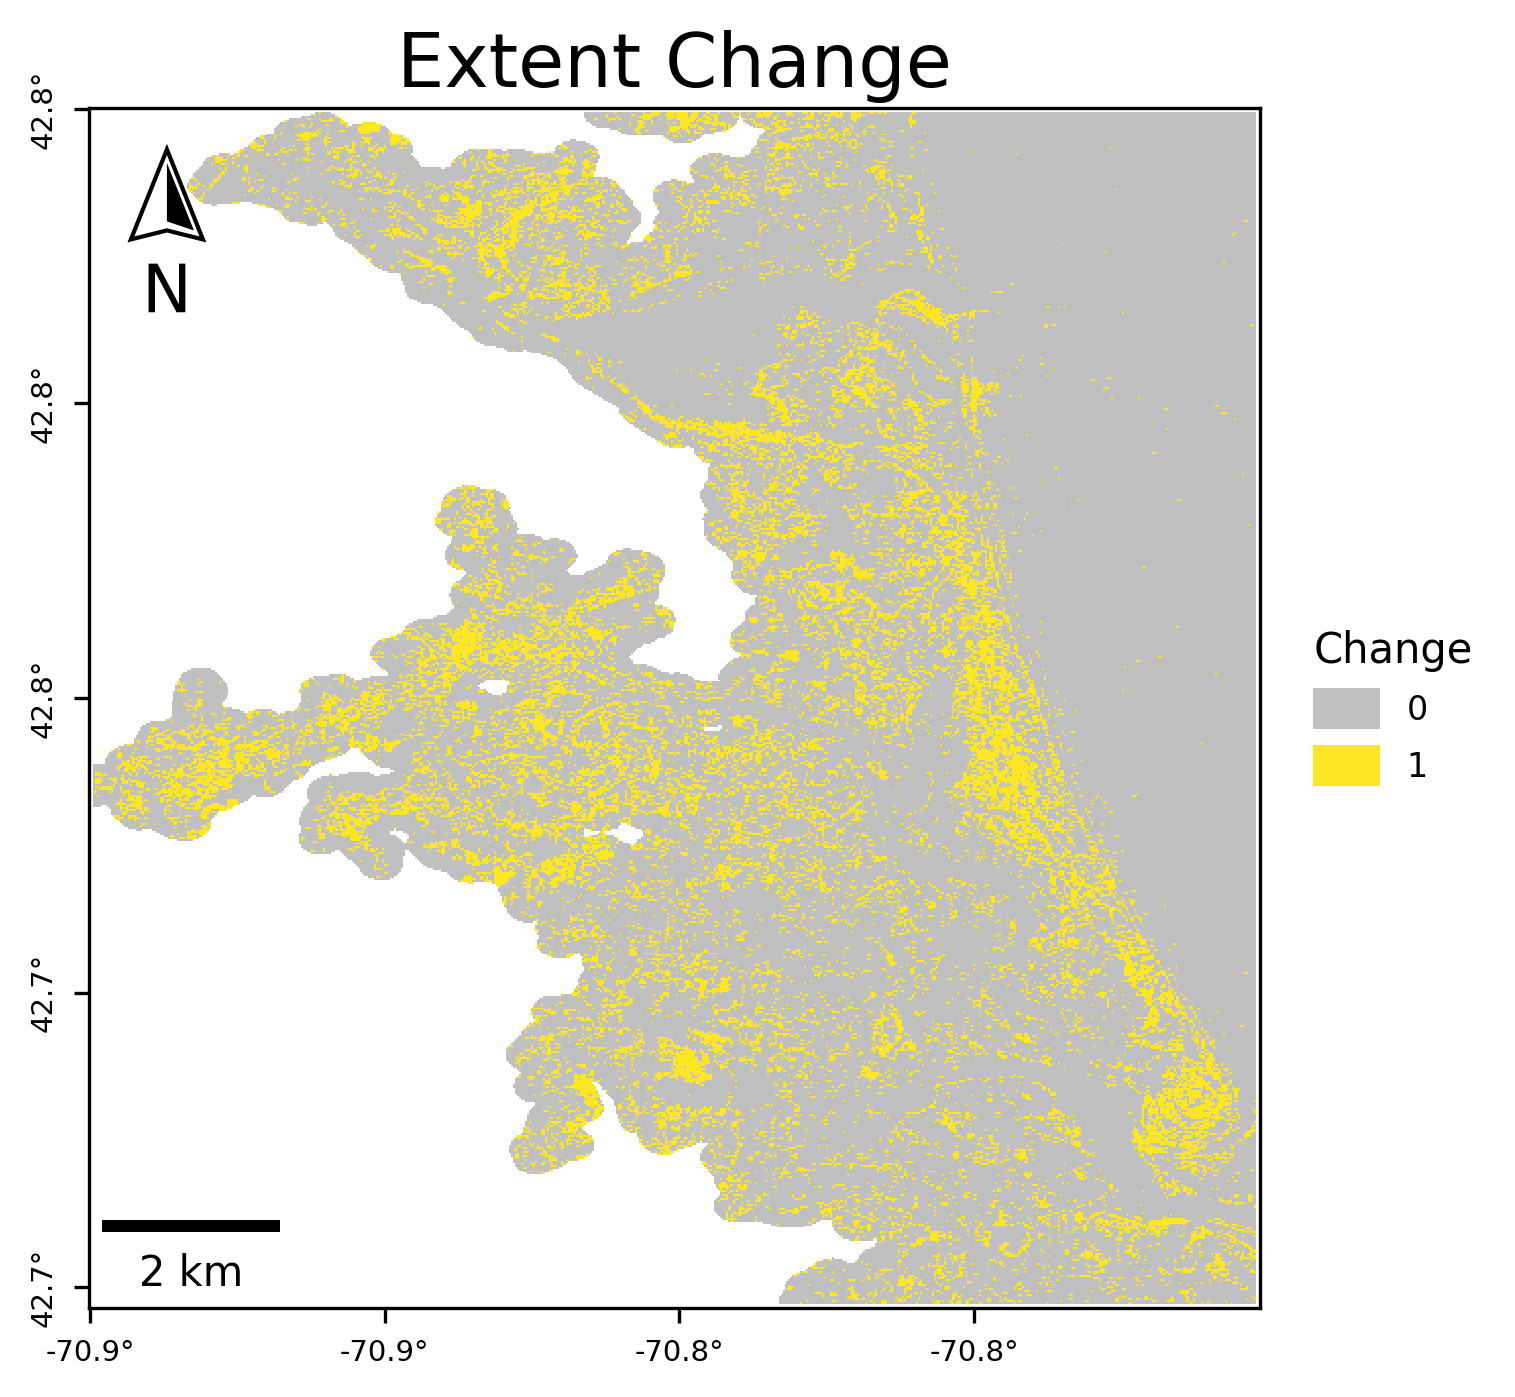

Map figure saved successfully to: /content/drive/MyDrive/Assessments/quest/pie/maps/map_extent_change.png


In [ ]:
# @title 5.6.1 Plot extent change map
_plot_discrete_raster_map(
    output_dir=output_path,
    raster_filename="map_extent.tif",
    title="Extent Change",
    legend_title="Change",
    output_png_name="map_extent_change.png",
    nodata_val=noData_value,
    color_mode="gradient",
    range_mode="zero",
    filter_present_values=False,
    legend_extra_kwargs={"bbox_to_anchor": (1.02, 0.5)},
)

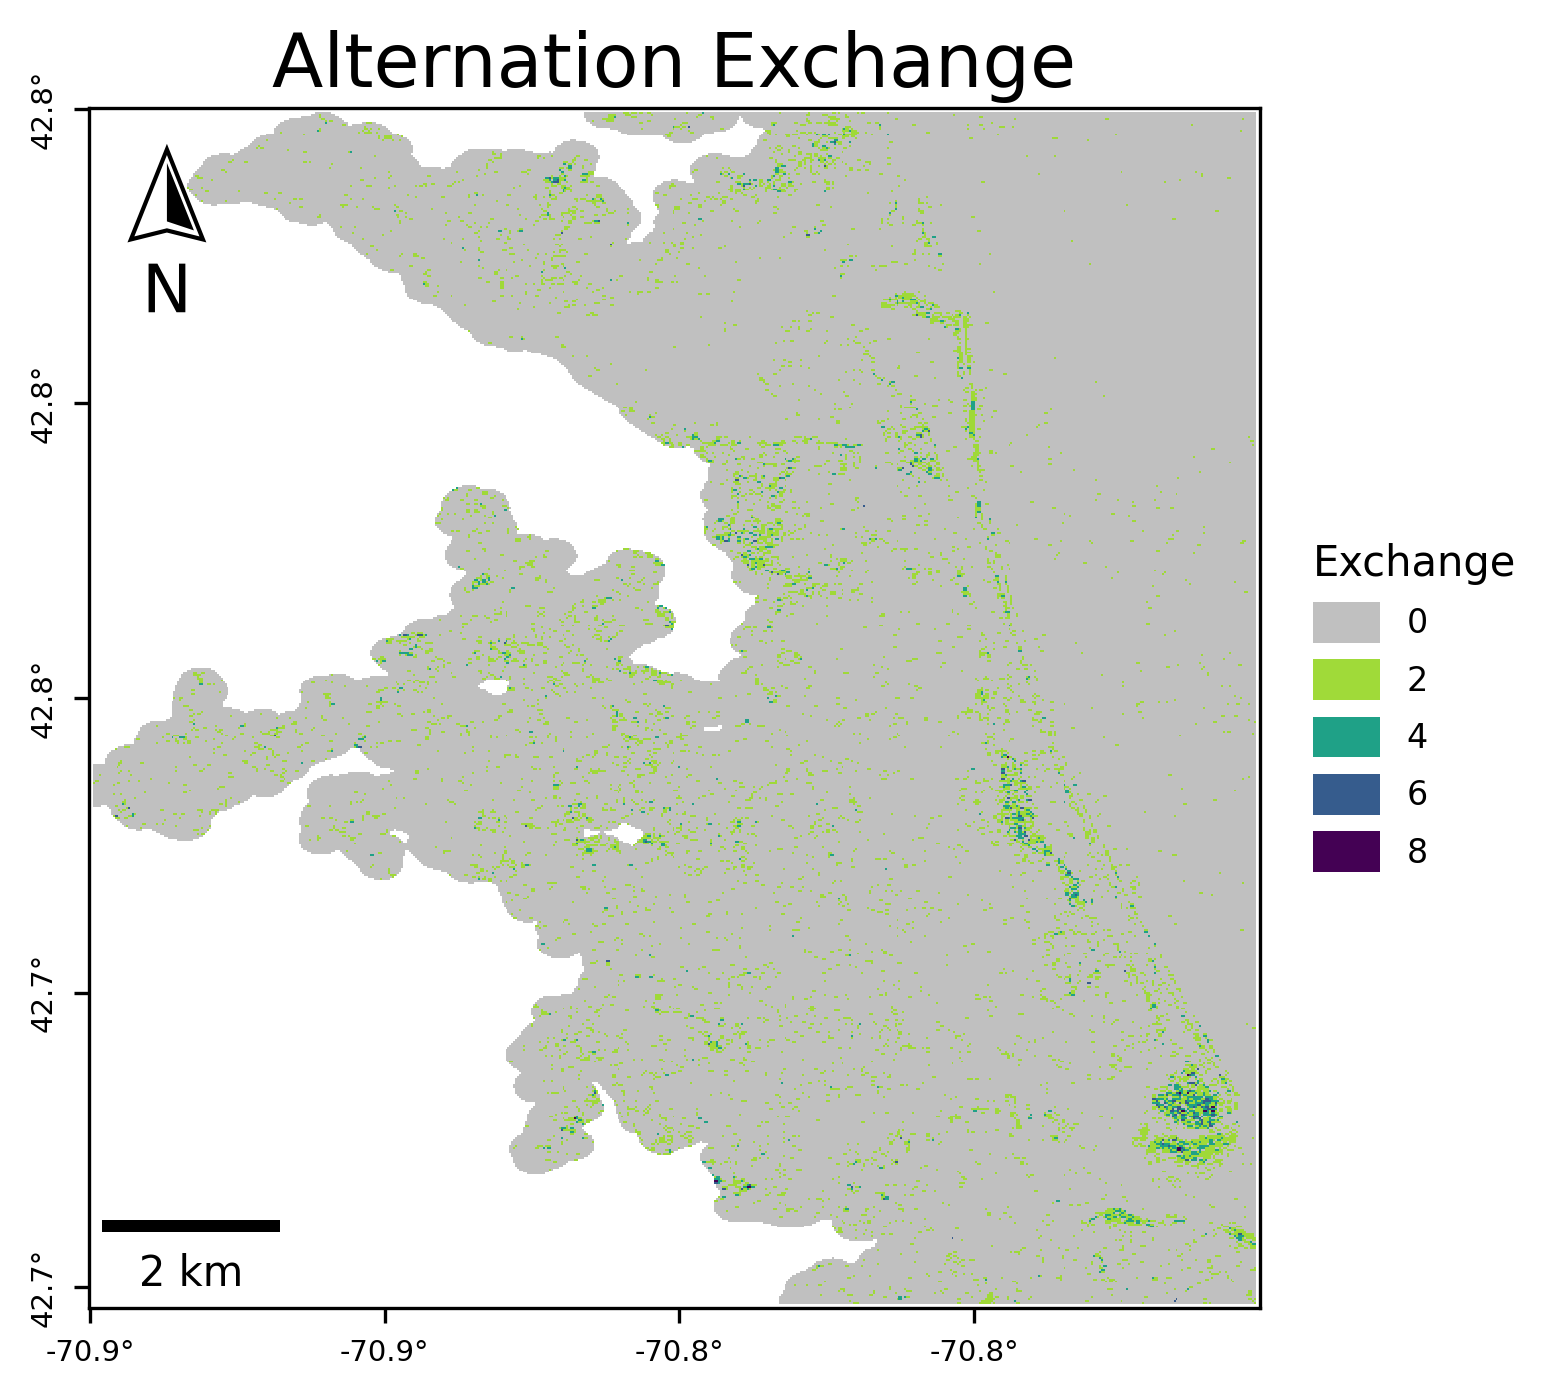

Map figure saved successfully to: /content/drive/MyDrive/Assessments/quest/pie/maps/map_alternation_exchange.png


In [ ]:
# @title 5.6.2 Plot alternation exchange map
_plot_discrete_raster_map(
    output_dir=output_path,
    raster_filename="map_alternation_exchange.tif",
    title="Alternation Exchange",
    legend_title="Exchange",
    output_png_name="map_alternation_exchange.png",
    nodata_val=noData_value,
    color_mode="gradient",
    range_mode="zero",
    filter_present_values=True,
    legend_extra_kwargs={"bbox_to_anchor": (1.02, 0.5)},
)

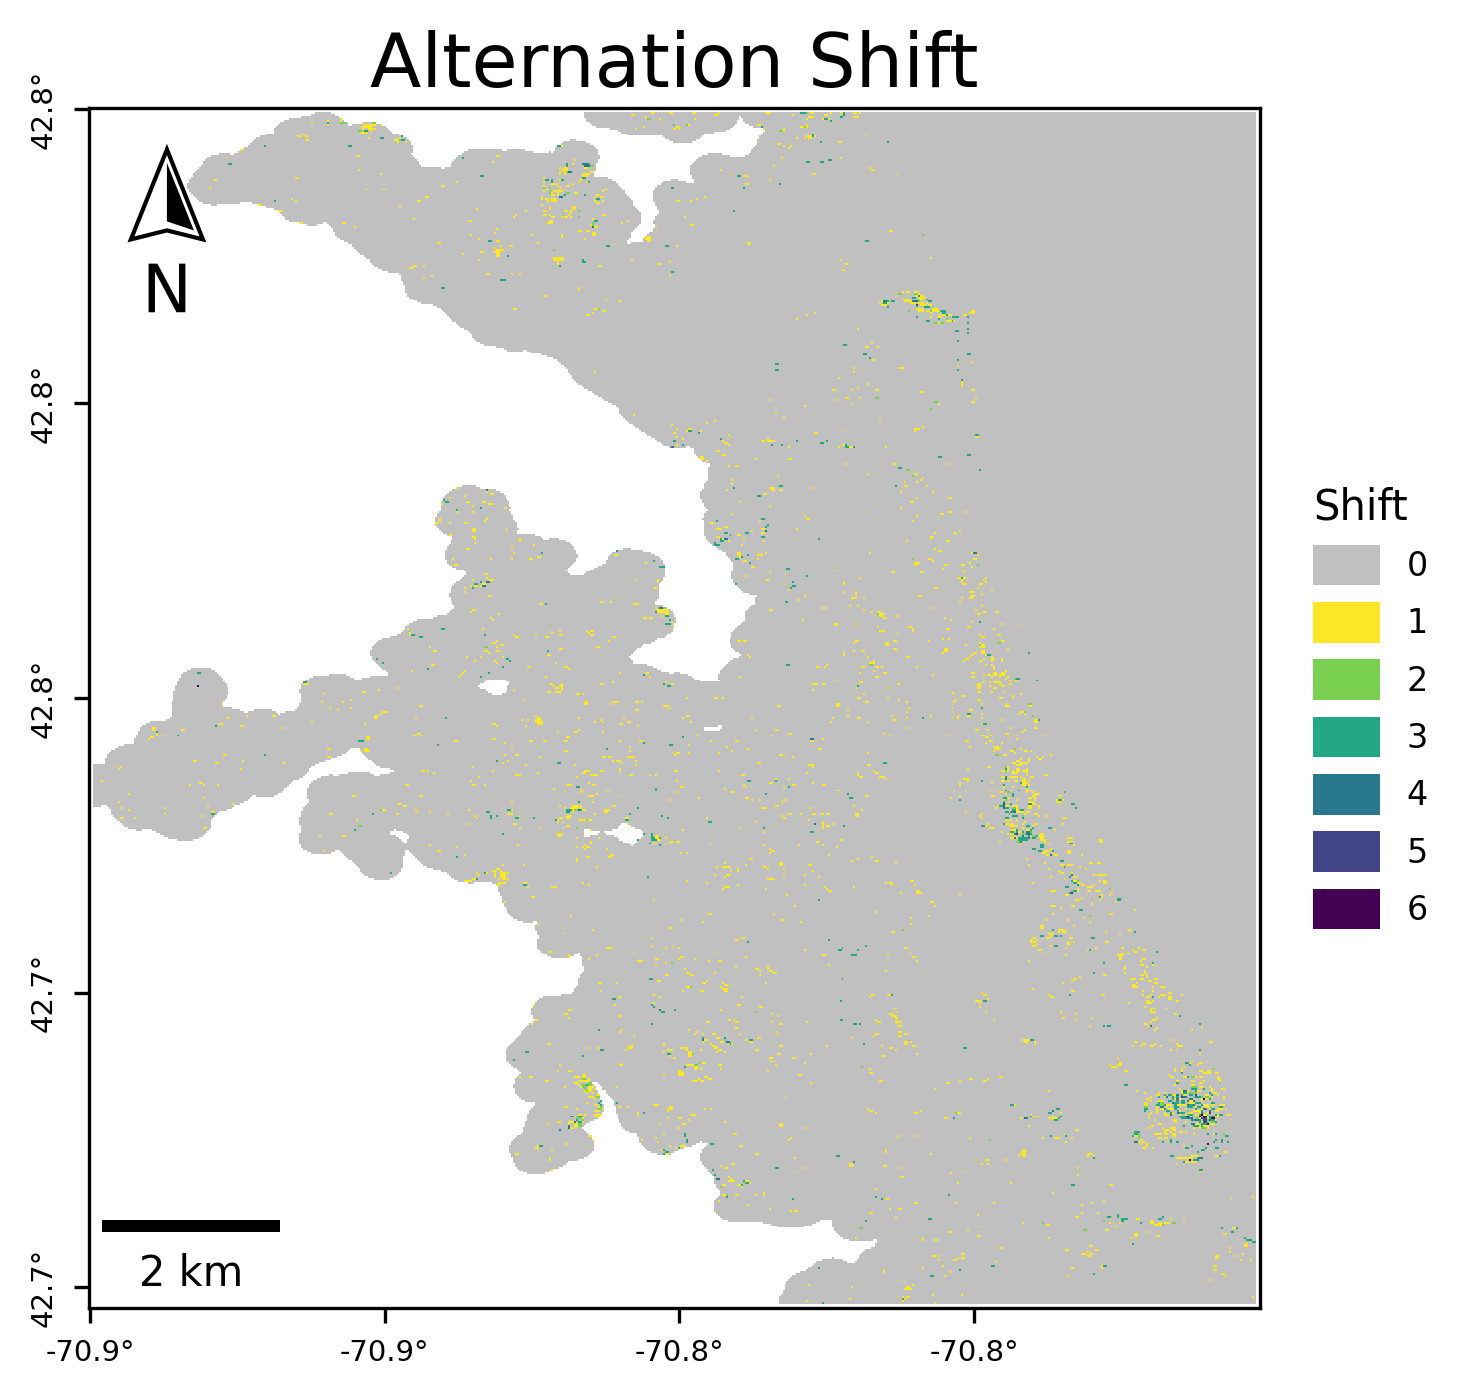

Map figure saved successfully to: /content/drive/MyDrive/Assessments/quest/pie/maps/map_alternation_shift.png


In [ ]:
# @title 5.6.3 Plot alternation shift map
_plot_discrete_raster_map(
    output_dir=output_path,
    raster_filename="map_alternation_shift.tif",
    title="Alternation Shift",
    legend_title="Shift",
    output_png_name="map_alternation_shift.png",
    nodata_val=noData_value,
    color_mode="gradient",
    range_mode="zero",
    filter_present_values=True,
    legend_extra_kwargs={"bbox_to_anchor": (1.02, 0.5)},
)